# **Install Requeriments**

Instalar os requeriemntos do Alpaca API

In [1]:
pip install alpaca-trade-api

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 757.7/757.7 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 5.6 MB/s eta 0:00:00
  Created wheel for msgpack: filename=msgpack-1.0.3-cp311-cp311-linux_x86_64.whl size=15688 sha256=c05818c1a8241a23ab7688ae7138704b00b2c6b04f4a15bb09d02004e53ce0bc
  Stored in directory: /root/.cache/pip/wheels/f6/35/da/ed9b26b510235e00e3a3c3bab7bad97b59214729662255ab3d
Successfully built msgpack
  Attempting uninstall: msgpack
    Found existing installation: msgpack 1.1.0
    Uninstalling msgpack-1.1.0:
      Successfully uninstalled msgpack-1.1.0
  Attempting uninstall: websockets
    Found existing installation: websockets 14.2
    Uninstalling w

Instalas a biblioteca necessária para calculares o garu necessário de semelhança entre strings

In [2]:
pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.7/162.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 35.2 MB/s eta 0:00:00


Instalas a biblioteca necessária para calculares o garu necessário de semelhança entre strings

In [3]:
pip install fuzzywuzzy

In [4]:
import math
from google.colab import drive
import os
from fuzzywuzzy import process
import tensorflow as tf
from tensorflow.keras.models import load_model
import pandas as pd
from datetime import datetime, timedelta, timezone
import alpaca_trade_api as tradeapi
import time
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.stats import norm
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px

# **Escolhendo o Modelo Para Ser Utilizado:**

Connecta com a tua google drive

In [5]:
# Montar o Google Drive
drive.mount("/content/drive")

Mounted at /content/drive


Todas as variaveis que se podem personalizar de forma a escolher o modelo e o dataset a ser usado neste algoritmo para testar estratégias de como usar da melhor forma o modelo no mercado.

As primeiras possibilidades de cada variável são aquelas as quais inicialmnete pensas-te que faziam mais sentido:

* symbol = 'AAPL', (retira do ficheito execel, tens o código que extrai)
* max_period = True, (podes ter erros por excesso de pedidos do API)
* start_date = '', '2022-10-31', (1 ano funciona bem para test runs)
* end_date = '', '2023-10-31', (1 ano funciona bem para test runs)
* timeframe = '1Min', '5Min', (mais de 5Min parece perder sentido a teoria)
* fisrt_marker = 'volume', 'close', 'high', 'low', 'trade_count', 'open', 'vwap', 'average_oc', 'average_hl', (a ideia inicial é ver o volume relativo, mas pode ser interessante estudar o trade_count)
* second_marker = 'vwap', 'volume', 'close', 'high', 'low', 'trade_count', 'open', 'average_oc', 'average_hl', (a ideia inicial era ver a média entre o high e o low - 'average_hl', mas fica na duvida ver a média entre o open e o close - 'average_oc', pode também ser muito interessante investigar o vwap)
* third_marker = '', 'volume', 'close', 'high', 'low', 'trade_count', 'open', 'vwap', 'average_oc', 'average_hl', (não pensas te em usar uma terceira coluna para criar as matrizes, mas se os resultados impiricos assim o provarem usa)
* n_rows = 12, 10, 15, 30, 5, (pensa no timeframe quando fazes isso, o 12 pareceu ser o melhor em testes impiricos)
* sort = True, (tens de pensar na sequencia temporal se faz sentido manter ou não)
* relative_first_marker = True, (tens de pensar em que marker correspondente estás a usar, pensa se matemáticamente faz sentido ou não colocares o marcador com valores relativos para todo o tensor, faltam te dados impiricos, o volume pensas te inicialmnete deixar em impirico para o tensor para normalizares os tensores)
* relative_second_marker = False, (tens de pensar em que marker correspondente estás a usar, pensa se matemáticamente faz sentido ou não colocares o marcador com valores relativos para todo o tensor, faltam te dados impiricos)
* relative_third_marker = False, (tens de pensar em que marker correspondente estás a usar, pensa se matemáticamente faz sentido ou não colocares o marcador com valores relativos para todo o tensor, faltam te dados impiricos)
* decimals = '', 3, 4 (tens de ver o que os dados impiricos te dizem se com arrendondamentos facilitas ou n a vida do AI)
* LSTM_boolean = True, (em caso de falso não usas um LSTM e partes do precipio que a relação causal deixa de ser importante para a cosntrução do tensor, quando normalizas os dados a esperança seria de não teres de usar um LSTM)
* epochs = 5, (este numero tende a ser irrelevante porque tens um checkpoint de callback referente ao melhor resultado de validation accuracy)
* early_stopping = True, (podes ligar ou desligar de forma automática o early_stopping, ou seja, o call back aqui)
* call_back = 'val_accuracy', 'val_loss', 'accuracy', 'loss' (escolhes o paramtero que monitora o call back)
* patience = 2, 50, 100, 500, 1000 (escolhes a paciencia do call back)
* batch_size = 64, 16, 32, 128, 256, 512 (varias com o tramanho do dataset, mas pensa que tens conseguido datasets bem grandes portanto usa os maiores valores)

In [6]:
symbol = "AAPL"
max_period = True
start_date = "2022-10-31"
end_date = "2023-12-31"
timeframe = "1Min"
fisrt_marker = "volume"
second_marker = "vwap"
third_marker = ""
n_rows = 12
sort = True
relative_first_marker = True
relative_second_marker = False
relative_third_marker = False
decimals = ""
LSTM_boolean = True
epochs = 5
early_stopping = True
call_back = "val_accuracy"
patience = 2
batch_size = 64

Iniciar as variaveis reponsáveis por possivelmente localizar o modelo que está a ser escolhido, uma parte da encriptação do nome do ficheiro com o modelo são os resultados do modelo e aqui iniciacia-se os parametros dos resultado do modelo.

In [7]:
test_loss = 0.0000
test_accuracy = 0.0000

Função que utiliza as variaveis selecionadas para criar o nome de busca pelo ficheiro que se existir e encontra o modelo guardado que terá um nome de ficheiro igual ou parecido.

In [8]:
def create_file_name(
    symbol,
    max_period,
    start_date,
    end_date,
    timeframe,
    fisrt_marker,
    second_marker,
    third_marker,
    n_rows,
    sort,
    relative_first_marker,
    relative_second_marker,
    relative_third_marker,
    decimals,
    LSTM_boolean,
    epochs,
    early_stopping,
    call_back,
    patience,
    batch_size,
    test_loss,
    test_accuracy,
):
    # Nome aproximado do arquivo
    nome_aproximado = (
        "s="
        + symbol
        + "+"
        + "mp="
        + str(max_period)
        + "+"
        + "sd="
        + start_date
        + "+"
        + "ed="
        + end_date
        + "+"
        + "tf="
        + timeframe
        + "+"
        + "fm="
        + fisrt_marker
        + "+"
        + "sm="
        + second_marker
        + "+"
        + "tm="
        + third_marker
        + "+"
        + "r="
        + str(n_rows)
        + "+"
        + "sort="
        + str(sort)
        + "+"
        + "rfm="
        + str(relative_first_marker)
        + "+"
        + "rsm="
        + str(relative_second_marker)
        + "+"
        + "rtm="
        + str(relative_third_marker)
        + "+"
        + "d="
        + decimals
        + "+"
        + "Lb="
        + str(LSTM_boolean)
        + "+"
        + "e="
        + str(epochs)
        + "+"
        + "es="
        + str(early_stopping)
        + "+"
        + "cb="
        + call_back
        + "+"
        + "p="
        + str(patience)
        + "+"
        + "bs="
        + str(batch_size)
        + "+"
        + "tl="
        + str(test_loss)
        + "+"
        + "ta="
        + str(test_accuracy)
    )

    return nome_aproximado

Esta função permite extrair as variaveis do nome do ficheiro escolhido como modelo a ser testado e dataset a ser usado.

In [9]:
def get_variables_from_file_name(file_name):
    # Remover a extensão '.keras' se estiver presente
    if file_name.endswith(".keras"):
        file_name = file_name[:-6]  # Remove os últimos 6 caracteres
    elif file_name.endswith(".h5"):
        file_name = file_name[:-3]  # Remove os últimos 3 caracteres

    # Dividir a string pelo caractere '_'
    parts = file_name.split("+")

    # Dicionário para armazenar as variáveis extraídas
    variables = {}

    # Dicionário para mapear os prefixos no nome do arquivo às variáveis da função
    prefix_map = {
        "s=": "symbol",
        "mp=": "max_period",
        "sd=": "start_date",
        "ed=": "end_date",
        "tf=": "timeframe",
        "fm=": "first_marker",
        "sm=": "second_marker",
        "tm=": "third_marker",
        "r=": "n_rows",
        "sort=": "sort",
        "rfm=": "relative_first_marker",
        "rsm=": "relative_second_marker",
        "rtm=": "relative_third_marker",
        "d=": "decimals",
        "Lb=": "LSTM_boolean",
        "e=": "epochs",
        "es=": "early_stopping",
        "cb=": "call_back",
        "p=": "patience",
        "bs=": "batch_size",
        "tl=": "test_loss",
        "ta=": "test_accuracy",
    }

    # Percorrer as partes e extrair o prefixo e o valor correspondente
    for part in parts:
        for prefix, var_name in prefix_map.items():
            if part.startswith(prefix):
                # Extrair o valor removendo o prefixo
                value = part[len(prefix) :]

                # Converter os valores para seus tipos originais
                if var_name in [
                    "max_period",
                    "sort",
                    "relative_first_marker",
                    "relative_second_marker",
                    "relative_third_marker",
                    "LSTM_boolean",
                    "early_stopping",
                ]:
                    value = value.lower() == "true"
                elif var_name in ["n_rows", "epochs", "patience", "batch_size"]:
                    value = int(value)
                elif var_name in ["test_loss", "test_accuracy"]:
                    value = float(value)

                # Armazenar o valor no dicionário
                variables[var_name] = value
                break

    return variables

usa as variaveis introduzidas anteriormente para procurar na base de modelos criados e treinados qual é que mais se aproxima do modelo solicitado pelas variaveis. Para isto é utilizado uma biblioteca que tem funçõe que permite comparar strings a comparação com a pontuação mais elevada entre o nome virtual criado pelas vairaveis introduzidas no suntzu e o nome do ficheiro onde estam encriptadas as variaveis que foram usadas no alpaca para criar e treinar o modelo. O ficehiro que produzir a pontuação de comparação mais elevada é usado para ser testado no suntzu. Desta forma é carregado um modelo e um dataset da base de dados.

In [10]:
# Caminho para o diretório onde os arquivos estão localizados
diretorio = (
    "/content/drive/MyDrive/AI Financial Analisys/Summer Project/Neural Network/Models/"
)

# Nome aproximado do arquivo
nome_aproximado = create_file_name(
    symbol,
    max_period,
    start_date,
    end_date,
    timeframe,
    fisrt_marker,
    second_marker,
    third_marker,
    n_rows,
    sort,
    relative_first_marker,
    relative_second_marker,
    relative_third_marker,
    decimals,
    LSTM_boolean,
    epochs,
    early_stopping,
    call_back,
    patience,
    batch_size,
    test_loss,
    test_accuracy,
)

# Lista todos os arquivos no diretório
arquivos = os.listdir(diretorio)

# Encontra o arquivo mais próximo
arquivo_mais_proximo, pontuacao = process.extractOne(nome_aproximado, arquivos)

# Encontra o arquivo mais próximo
if process.extractOne(nome_aproximado, arquivos):
    arquivo_mais_proximo, pontuacao = process.extractOne(nome_aproximado, arquivos)
else:
    arquivo_mais_proximo = None
    pontuacao = None

if arquivo_mais_proximo:
    caminho_do_modelo = os.path.join(diretorio, arquivo_mais_proximo)
    print("Nome do arquivo mais próximo:")
    print(arquivo_mais_proximo)
    print()
    print("Caminho completo do modelo:")
    print(caminho_do_modelo)
    print()
    print("Pontuação de similaridade:")
    print(pontuacao)

else:
    print("Nenhum arquivo próximo encontrado.")

Nome do arquivo mais próximo:
s=AAPL+mp=True+sd=2016-10-31+ed=2023-12-31+tf=5Min+fm=vwap+sm=trade_count+tm=+r=36+sort=False+rfm=True+rsm=False+rtm=False+d=+Lb=True+e=1000+es=True+cb=val_accuracy+p=100+bs=128+tl=0.45428553223609924+ta=0.8215504884719849.keras

Caminho completo do modelo:
/content/drive/MyDrive/AI Financial Analisys/Summer Project/Neural Network/Models/s=AAPL+mp=True+sd=2016-10-31+ed=2023-12-31+tf=5Min+fm=vwap+sm=trade_count+tm=+r=36+sort=False+rfm=True+rsm=False+rtm=False+d=+Lb=True+e=1000+es=True+cb=val_accuracy+p=100+bs=128+tl=0.45428553223609924+ta=0.8215504884719849.keras

Pontuação de similaridade:
86


do ficheiro carregado serão extraidas as variaveis encriptadas no nome do ficheiro, para serem usadas para correr o modelo e testar as estratégias de otimização de gestão de portefólio ao longo do SunTzu.

In [11]:
# Usando a função get_variables_from_file_name para extrair as variáveis
variables = get_variables_from_file_name(arquivo_mais_proximo)


# Imprimir as variáveis extraídas para depuração
print("Variáveis extraídas:", variables)
print()

# Agora redefinindo todas as variáveis usando o dicionário `variables`
symbol = variables["symbol"]
max_period = variables["max_period"]
start_date = variables["start_date"]
end_date = variables["end_date"]
timeframe = variables["timeframe"]
fisrt_marker = variables[
    "first_marker"
]  # Atenção à ortografia: `fisrt_marker` é um erro de digitação. O correto seria `first_marker`.
second_marker = variables["second_marker"]
third_marker = variables["third_marker"]
n_rows = variables["n_rows"]
sort = variables["sort"]
relative_first_marker = variables["relative_first_marker"]
relative_second_marker = variables["relative_second_marker"]
relative_third_marker = variables["relative_third_marker"]
decimals = variables["decimals"]
LSTM_boolean = variables["LSTM_boolean"]
epochs = variables["epochs"]
early_stopping = variables["early_stopping"]
call_back = variables["call_back"]
patience = variables["patience"]
batch_size = variables["batch_size"]
test_loss = variables["test_loss"]
test_accuracy = variables["test_accuracy"]

model = load_model(caminho_do_modelo)
print("Modelo e variáveis carregados!")

Variáveis extraídas: {'symbol': 'AAPL', 'max_period': True, 'start_date': '2016-10-31', 'end_date': '2023-12-31', 'timeframe': '5Min', 'first_marker': 'vwap', 'second_marker': 'trade_count', 'third_marker': '', 'n_rows': 36, 'sort': False, 'relative_first_marker': True, 'relative_second_marker': False, 'relative_third_marker': False, 'decimals': '', 'LSTM_boolean': True, 'epochs': 1000, 'early_stopping': True, 'call_back': 'val_accuracy', 'patience': 100, 'batch_size': 128, 'test_loss': 0.45428553223609924, 'test_accuracy': 0.8215504884719849}

Modelo e variáveis carregados!


Este parte do código permite obter as características da arqitetura do AI que está a ser usada.

In [12]:
# Opcional: visualizar o resumo do modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 36, 64)              │          17,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 36, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 150,725 (588.77 KB)

 Trainable params: 50,241 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 100,484 (392.52 KB)

# **Obtendo os Dados para Modelos LSTM:**

Saber o dia que é hoje, o dia que o código está a correr, o modelo está a ser criado

In [13]:
# Obter a data e hora atuais
current_date_time = datetime.now()

# Formatar a data como string
current_date = current_date_time.strftime("%Y-%m-%d")
print(f"Hoje é: {current_date}")


def get_end_date(symbol):
    # Obter a data e hora atuais
    current_date_time = datetime.now()
    # Make start timezone aware
    current_date_time = current_date_time.replace(tzinfo=timezone.utc)
    return current_date_time

Hoje é: 2025-02-26


Usas a tua senha da tua conta no ALpca API para usares a API, tens de te conectar á tua conta.

In [14]:
def alpaca_autentification():
    # Replace with your Alpaca API credentials
    # API_KEY = '[Alpaca API credentials]'
    # SECRET_KEY = '[Alpaca API credentials]'
    BASE_URL = "https://api.alpaca.markets"  # Use 'https://api.alpaca.markets' for live trading

    # Initialize the Alpaca API
    api = tradeapi.REST(API_KEY, SECRET_KEY, BASE_URL, api_version="v2")

    return api

Depois chamas a API para retirar os dados que necessitas. Para a API não te bloquear usas um intervalo de 1 segundo sempre que chamas a API para conseguires atingir elevada granuralidade dos dados, sem seres bloqueado pela API.

In [15]:
# Function to fetch data in chunks to avoid rate limits
def fetch_data(symbol, start, end, timeframe, api):
    all_data = []
    current_start = start

    while current_start < end:
        current_end = current_start + timedelta(days=7)
        if current_end > end:
            current_end = end

        # Fetch the historical data
        bars = api.get_bars(
            symbol,
            timeframe,
            start=current_start.strftime("%Y-%m-%d"),
            end=current_end.strftime("%Y-%m-%d"),
        ).df

        all_data.append(bars)
        current_start = current_end
        time.sleep(1)  # Adjust sleep interval based on rate limits

    return pd.concat(all_data)

Usando a alpaca API para sacar os dados agora que já deste login á tua conta da alpaca com a tua senha pessoal anteriormente.

In [16]:
def get_all_data(
    symbol="AAPL", max_period=True, start_date="", end_date="", timeframe="1Min"
):
    api = alpaca_autentification()

    if max_period and start_date == "" and end_date == "":
        start_date = get_start_date(symbol)
        end_date = get_end_date(symbol)
    elif start_date != "" and end_date != "":
        start_date = datetime.strptime(start_date, "%Y-%m-%d")
        end_date = datetime.strptime(end_date, "%Y-%m-%d")
    else:
        start_date = datetime(2022, 12, 31)
        end_date = datetime(2023, 12, 31)

    # Fetch the historical data
    apple_data = fetch_data(symbol, start_date, end_date, timeframe, api)
    return apple_data

Esta função irá preparar dos dados para o modelo. Do Alpca seram retirados multiplos parametros do mercado interessa-te selecionar apenas os que queres alimentar ao modelo para isso esat função é usada para os selecionar. podes escolher entre 'close', 'high', 'low', 'trade_count', 'open', 'volume', 'vwap', que são os parametros de mercado dados por default pelo Alpaca. Mas para além disso crias te outras 2 métricas com base nas métricas já dadas caso as queiras testar eslas são: 'average_oc' e 'average_hl', que correspondem, respetivamente, ao ponto médio entre o open e o close e o ponto médio entre o high e o low.



*   close é o preço de fecho da ação naquele intervalo temporal
*   high é o preço mais alto da ação naquele intervalo temporal
*   low é o preço mais baixo da ação naquele intervalo temporal
*   trade_count é o número de matches entre compradosres e vendedores naquele intervalo temporal
*   open é o preço de abertura da ação naquele intervalo temporal
*   vwap é o preço da ação por volume naquele intervalo temporal ( uma forma diferente de olhar para o valor intrinseco de uma ação)



In [17]:
# Function to prepare the data
def prepare_data(data, fisrt_marker, second_marker, third_marker=""):
    # Selecionar colunas relevantes e fazer uma cópia para evitar advertências
    data_selected = data[
        ["close", "high", "low", "trade_count", "open", "volume", "vwap"]
    ].copy()

    # Calcular a média entre 'Open' e 'Close' usando .loc para evitar o SettingWithCopyWarning
    data_selected.loc[:, "average_oc"] = data_selected[["open", "close"]].mean(axis=1)

    # Calcular a média entre 'High' e 'Low' usando .loc para evitar o SettingWithCopyWarning
    data_selected.loc[:, "average_hl"] = data_selected[["high", "low"]].mean(axis=1)

    # Selecionar as colunas finais
    if third_marker != "":
        data_final = data_selected[[fisrt_marker, second_marker, third_marker]]
    else:
        data_final = data_selected[[fisrt_marker, second_marker]]

    return data_final

Agora temos de continuara a preparação dos dados para serem alimentado ao modelo para isso crio matrizes para segmentar os dados, cada matriz vai ter uma label: 0 ou 1. Assim o dataset vai ser constituido por ,atrizes de tamanho a defenir pelo o usuário do algoritmo e pelas suas respetivas labels de 0 ou 1. As matrizes no máximo poderão ter até 3 colunas, cada coluna representa uma metrica difrente do mercado. As linhas estam inicialmente organizadas de forma sequencial e representação a cada uma a granuralidade mínima do dataset, assim se a granuralidade é de 1 minuto e uma matriz tem 5 linhas, cada matriz representa 5 minutos continuos de métricas do mercado no tempo. As métricas de cada matriz por coluna podem ser formatadas como relativas, o que significa que as métricas da matriz seram apresentadas de forma relativa á matriz em questão, o que pode ser interessante para modelos sem ser um LSTM, pois permite que os dados históricos sejam baralhados temporalmente e manetenham coerência. Como é o caso por exemplo do preço e do volume, com a inflação é normal que o preço aumente mas não queremos que isso cause uma precepção errada de magnitude superior ao nosso modelo assim o 'relative' faz com que as métricas das matrizes apareçam como valores ponderados aos restantes valores da matriz, assim cada valor da métrica relativa é dividida pelo somatório dos valores dessa métrica presentes na matriz.

In [18]:
# Função para criar as matrizes e os labels
def create_matrices(
    data_final,
    n=12,
    fisrt_marker="volume",
    second_marker="vwap",
    third_marker="",
    relative_fisrt_marker=True,
    relative_second_marker=False,
    relative_third_marker=False,
):
    num_rows = data_final.shape[0]
    num_matrices = num_rows // n  # Número de matrizes completas que podemos formar

    matrices = []
    matrices_y = []

    for i in range(num_matrices):
        start_idx = i * n
        end_idx = start_idx + n
        matrix = data_final.iloc[start_idx:end_idx].copy()

        if relative_fisrt_marker:
            # Calcular a soma da coluna de volume
            volume_sum = matrix[fisrt_marker].sum()

            # Tornar a coluna do volume relativa
            matrix[fisrt_marker] = matrix[fisrt_marker] / volume_sum

            # Converter para valores numpy e adicionar à lista de matrizes
            matrices.append(matrix.values)

        if relative_second_marker:
            # Calcular a soma da coluna de volume
            volume_sum = matrix[second_marker].sum()

            # Tornar a coluna do volume relativa
            matrix[second_marker] = matrix[second_marker] / volume_sum

            # Converter para valores numpy e adicionar à lista de matrizes
            matrices.append(matrix.values)

        if relative_third_marker:
            # Calcular a soma da coluna de volume
            volume_sum = matrix[third_marker].sum()

            # Tornar a coluna do volume relativa
            matrix[third_marker] = matrix[third_marker] / volume_sum

            # Converter para valores numpy e adicionar à lista de matrizes
            matrices.append(matrix.values)

        # Criar labels
        if i > 0:  # Ignorar a primeira matriz para alinhamento correto
            first_value = matrices[i][0, 1]
            last_value = matrices[i][n - 1, 1]
            delta = last_value - first_value
            delta_bi = 1 if delta >= 0 else 0
            matrices_y.append(delta_bi)

    return matrices, matrices_y

Caso se entenda que a ordem temporal, devido á elevada granuraridade dos dados de uma matriz, é irrelevante, esta função permite ordenar por ordem decrescente da métrica da segunda coluna os valores de uma matriz e assim por exemplo caso na segunda coluna se tenha o valor de volume estaria se a observar em cada matriz o preço por ordem crescente do volume. Esta função pode ser ativada ou desativada e pode ser interessante para uma elevada granuralidade em que as matrizes apenas representam 5 minutos e não se está a usar uma LSTM.

In [19]:
def sort_matrices(matrices):
    # Ordenar as linhas de cada matriz por ordem decrescente da coluna Average (segunda coluna)
    matrices_x = []
    for matrix in matrices:
        sorted_indices = np.argsort(matrix[:, 1])[::-1]
        sorted_matrix = matrix[sorted_indices]
        matrices_x.append(sorted_matrix)
    return matrices_x

Funçaõ para passar as matrizes para tensores para poderem ser tartadas pelo TensorFlow

In [20]:
def tensor_creator(matrices_x, matrices_y):
    # Converter listas para arrays numpy
    matrices_x = np.array(matrices_x)
    matrices_y = np.array(matrices_y)
    return matrices_x, matrices_y

Função que integra todas as outras funções que falamos para obter o dataset e manipulá-lo conforme o utilizador do algoritmo deseja

In [21]:
def get_dataset(
    company_data,
    n_rows,
    sort=True,
    fisrt_marker="volume",
    second_marker="vwap",
    third_marker="",
    relative_fisrt_marker=True,
    relative_second_marker=False,
    relative_third_marker=False,
    decimals="",
):
    matrices_x = []
    matrices_y = []

    matrices_x, matrices_y = create_matrices(
        company_data,
        n_rows,
        fisrt_marker,
        second_marker,
        third_marker,
        relative_fisrt_marker,
        relative_second_marker,
        relative_third_marker,
    )

    if sort:
        matrices_x = sort_matrices(matrices_x)

    # Remover a última matriz de matrices_x para alinhamento com matrices_y
    if matrices_x:
        matrices_x.pop()

    matrices_x, matrices_y = tensor_creator(matrices_x, matrices_y)

    if decimals != "":
        matrices_x = np.round(matrices_x, decimals=decimals)
    return matrices_x, matrices_y

Esta função divide o dataset em treino, validação e teste. Esta divisão tem de ser feita de forma diferente caso se esteja a usar um LSTM ou não. Se for usado um LSTM para manter a ordem temporal dos dados o datset é dividido em fatias sequêncis primeiros 60% dos dados históricos para treino, proximos 20% para validação e ultimos 20% para teste. Se não for usado uma LSTM os dados históricos são formatados em matrizes, as matrizes são baralhadas e entregues baralhadas tempralmente ao modelo.

In [22]:
def split_dataset(matrices_x, matrices_y, LSTM=True):
    if LSTM:
        # Total de amostras
        n_samples = matrices_x.shape[0]

        # Índices para divisão
        train_size = int(0.6 * n_samples)  # 60% para treino
        val_size = int(0.2 * n_samples)  # 20% para validação
        test_size = n_samples - train_size - val_size  # 20% para teste

        # Dividir os dados sequencialmente
        X_train = matrices_x[:train_size]
        y_train = matrices_y[:train_size]

        X_val = matrices_x[train_size : train_size + val_size]
        y_val = matrices_y[train_size : train_size + val_size]

        X_test = matrices_x[train_size + val_size :]
        y_test = matrices_y[train_size + val_size :]
    else:
        # Dividir os dados em conjuntos de treinamento + validação e teste
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            matrices_x, matrices_y, test_size=0.2, random_state=42
        )

        # Dividir o conjunto de treinamento + validação em treinamento e validação
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=0.25, random_state=42
        )  # 0.25 * 0.8 = 0.2

    return X_train, X_val, X_test, y_train, y_val, y_test

função para procurar se o modelo e os dados são originais, caso não sejamm originais é porque foi encontrado dados e pelo menos um modelo identicos ao que está a ser pedido ao algoritmo já guradado na base de dados e caso isso aconteça, os dados não seram novamente retirados da API mas sim seram usados aqueles que já se encontram na base de dados (arquivos da tua google drive). Isto é feito por compração de nomes de ficheiros, já que no nome dos ficheiros encotra-se encriptado tudo o que é necessário para voltar a correr o algoritmo em termos de hyperparamtros e variaveis.

In [23]:
def old_dataset_function(symbol, max_period, start_date, end_date, timeframe):
    # Defina o caminho do diretório no Google Drive
    diretorio = (
        "/content/drive/MyDrive/AI Financial Analisys/Summer Project/Dataset/Raw Data"
    )

    # Nome aproximado do arquivo
    nome_aproximado = (
        "s="
        + symbol
        + "+"
        + "mp="
        + str(max_period)
        + "+"
        + "sd="
        + start_date
        + "+"
        + "ed="
        + end_date
        + "+"
        + "tf="
        + timeframe
        + ".csv"
    )

    # Lista todos os arquivos no diretório
    arquivos = os.listdir(diretorio)

    # Encontra o arquivo mais próximo
    if process.extractOne(nome_aproximado, arquivos):
        arquivo_mais_proximo, pontuacao = process.extractOne(nome_aproximado, arquivos)
    else:
        arquivo_mais_proximo = None
        pontuacao = None

    if arquivo_mais_proximo and pontuacao == 100:
        caminho_do_modelo = os.path.join(diretorio, arquivo_mais_proximo)
        print("Nome do arquivo mais próximo:")
        print(arquivo_mais_proximo)
        print()
        print("Caminho completo do modelo:")
        print(caminho_do_modelo)
        print()
        print("Pontuação de similaridade:")
        print(pontuacao)
        old_dataset = True
    else:
        print("Nenhum arquivo próximo encontrado.")
        caminho_do_modelo = ""
        old_dataset = False

    return old_dataset, caminho_do_modelo

Caso os dados sejam coletados por uma versão do algoritmo que correu em settings originais os dados seram gravados usando esta função e os settings que influenciram o levaram a obeter os respetivos dados/dataset modelo são encriptados no nome do ficheiro CSV no qual os dados ficam guardados.

In [24]:
def save_dataset(company_data, symbol, max_period, start_date, end_date, timeframe):
    # Defina o caminho do diretório no Google Drive
    caminho_para_salvar_dados = (
        "/content/drive/MyDrive/AI Financial Analisys/Summer Project/Dataset/Raw Data"
    )

    # Verifique se o diretório existe, caso contrário, crie-o
    if not os.path.exists(caminho_para_salvar_dados):
        os.makedirs(caminho_para_salvar_dados)
        print(f"Diretório {caminho_para_salvar_dados} criado com sucesso.")
    else:
        print(f"O diretório {caminho_para_salvar_dados} já existe.")

    print()

    file_name = (
        "s="
        + symbol
        + "+"
        + "mp="
        + str(max_period)
        + "+"
        + "sd="
        + start_date
        + "+"
        + "ed="
        + end_date
        + "+"
        + "tf="
        + timeframe
        + ".csv"
    )

    # Defina o caminho completo para salvar o arquivo
    caminho_completo_dados = os.path.join(caminho_para_salvar_dados, file_name)

    # Salve o dataframe no caminho especificado
    company_data.to_csv(caminho_completo_dados)

    print("Ficheiro dos Dados:")
    print(file_name)
    print()
    print("Dados salvos em:")
    print(caminho_para_salvar_dados)

Carrega o dataset que foi encontrado correspondente ao modelo na base de dados usando o mesmo mecânismo de correspondecia de strings que ajuda a selecionar o modelo, conforma os settings impostos no SunTzu.

In [25]:
old_dataset, caminho_do_modelo = old_dataset_function(
    symbol, max_period, start_date, end_date, timeframe
)

if old_dataset:
    all_company_data = pd.read_csv(caminho_do_modelo, index_col=0)
else:
    all_company_data = get_all_data(symbol, max_period, start_date, end_date, timeframe)
    save_dataset(all_company_data, symbol, max_period, start_date, end_date, timeframe)

print(all_company_data)
print(all_company_data.shape)
print()

Nome do arquivo mais próximo:
s=AAPL+mp=True+sd=2016-10-31+ed=2023-12-31+tf=5Min.csv

Caminho completo do modelo:
/content/drive/MyDrive/AI Financial Analisys/Summer Project/Dataset/Raw Data/s=AAPL+mp=True+sd=2016-10-31+ed=2023-12-31+tf=5Min.csv

Pontuação de similaridade:
100
                              close    high       low  trade_count      open  \
timestamp                                                                      
2016-10-31 08:00:00+00:00  113.9000  113.90  113.7500            6  113.8900   
2016-10-31 08:05:00+00:00  113.4000  113.76  113.4000            3  113.7600   
2016-10-31 09:00:00+00:00  113.7600  113.76  113.7600            2  113.7600   
2016-10-31 09:20:00+00:00  113.9500  113.95  113.8800            2  113.8800   
2016-10-31 10:05:00+00:00  113.7500  113.75  113.7500            1  113.7500   
...                             ...     ...       ...          ...       ...   
2023-12-30 00:35:00+00:00  192.1200  192.14  192.1100           44  192.1400   
20

Seleciona apenas as métricas que seram usadas dos dados todos da bolsa.

In [26]:
needed_company_data = prepare_data(
    all_company_data, fisrt_marker, second_marker, third_marker
)

print(needed_company_data)
print(needed_company_data.shape)
print()

                                 vwap  trade_count
timestamp                                         
2016-10-31 08:00:00+00:00  113.845860            6
2016-10-31 08:05:00+00:00  113.650304            3
2016-10-31 09:00:00+00:00  113.780833            2
2016-10-31 09:20:00+00:00  113.905455            2
2016-10-31 10:05:00+00:00  113.750000            1
...                               ...          ...
2023-12-30 00:35:00+00:00  192.130354           44
2023-12-30 00:40:00+00:00  192.135717           41
2023-12-30 00:45:00+00:00  192.204240           37
2023-12-30 00:50:00+00:00  192.221821           54
2023-12-30 00:55:00+00:00  192.183319           89

[369080 rows x 2 columns]
(369080, 2)



Divide os dados no tamnaho certo das matrizes para serem alimentados ao modelo.

In [27]:
matrices_x, matrices_y = get_dataset(
    needed_company_data,
    n_rows,
    sort,
    fisrt_marker,
    second_marker,
    third_marker,
    relative_first_marker,
    relative_second_marker,
    relative_third_marker,
    decimals,
)

print(matrices_x)
print(matrices_x.shape)
print(matrices_y)
print(matrices_y.shape)
print()

[[[2.78105903e-02 6.00000000e+00]
  [2.77628193e-02 3.00000000e+00]
  [2.77947053e-02 2.00000000e+00]
  ...
  [2.77705655e-02 3.84200000e+03]
  [2.77550589e-02 4.29400000e+03]
  [2.76940036e-02 3.62400000e+03]]

 [[2.77261290e-02 3.14300000e+03]
  [2.77187154e-02 3.16100000e+03]
  [2.77051727e-02 3.18100000e+03]
  ...
  [2.78044720e-02 1.08000000e+03]
  [2.78147684e-02 1.17100000e+03]
  [2.78350389e-02 1.08000000e+03]]

 [[2.77650674e-02 1.26500000e+03]
  [2.77669629e-02 9.07000000e+02]
  [2.77890572e-02 1.27100000e+03]
  ...
  [2.77430045e-02 2.43700000e+03]
  [2.77361180e-02 1.87500000e+03]
  [2.77251092e-02 2.20300000e+03]]

 ...

 [[2.77879953e-02 1.90000000e+01]
  [2.77799317e-02 2.50000000e+01]
  [2.77937222e-02 4.60000000e+01]
  ...
  [2.77534759e-02 3.78000000e+03]
  [2.77305929e-02 5.72700000e+03]
  [2.77247590e-02 1.51820000e+04]]

 [[2.79104742e-02 2.08220000e+04]
  [2.79140008e-02 1.95340000e+04]
  [2.79043118e-02 1.77060000e+04]
  ...
  [2.77147458e-02 3.71100000e+03]
  [2

Esta função divide o dataset em treino, teste e validação

In [28]:
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(
    matrices_x, matrices_y, LSTM_boolean
)

# Exibir as formas dos arrays resultantes
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)
print()

Shape of X_train: (6150, 36, 2)
Shape of y_train: (6150,)
Shape of X_val: (2050, 36, 2)
Shape of y_val: (2050,)
Shape of X_test: (2051, 36, 2)
Shape of y_test: (2051,)



# **Prevendo o Test Dataset no Mercado Financeiro:**

Agora é necessário estudar o dataset de teste de forma promenorizada. É preciso traduzir o datset de teste num período de mercado e extrair no mínimo um gráfico de preço em função do tempo da ação para preceberemos o comportamento da bolsa. Também é necessário comparar o comportamento normal da bolsa com uma estratégia simplista usando o modelo.

Esta etapa é importante e dificil de executar, pois também não te esqueças que é necessário extrair o open e o close para operar estratégias da bolsa, independentemente dos parametrso usados no modelo. Para operar na bolsa deves considerar que o modelo realiza o trading sempre no valor de open da intervalo temporal seguinte.

Esta função divide o test dataset em matrizes

In [29]:
# Dividir o DataFrame em subconjuntos de `n_rows` linhas
def split_dataframe(df, n_rows):
    # Número total de linhas no DataFrame
    num_rows = len(df)
    # Dividir o DataFrame em partes
    return np.array_split(df, np.arange(n_rows, num_rows, n_rows))

Extrai o open e o close do dataset para conseguir compor o gráfico de preço em função do tempo. O último intervalo temporal não necessita de ter o close e não deve.

In [30]:
# Função para processar os subconjuntos
def process_subsets(subsets, n_rows):
    processed_subsets = []
    for subset in subsets:
        if len(subset) >= n_rows:
            # Manter apenas a primeira linha (primeiro 'open')
            first_open = subset.iloc[[0]].copy()
            # Manter apenas a última linha (último 'close')
            last_close = subset.iloc[[-1]].copy()
            # Concatenar os resultados
            subset_processed = pd.concat([first_open, last_close])
            processed_subsets.append(subset_processed)

    return processed_subsets

Teremos agora de ingorar o ultimo conjunto, onde não será se operará temporalmente lógicamente. O primeiro open de todos intervalos temporais, na exceção do primeiro, será usado para simular os trades possivelemente executados pelo modelo. No ultimo subconjunto será apenas selecionado o close.

In [31]:
def select_open_close(processed_subsets):
    selected_data = []

    # Selecionar o primeiro 'open' de todos os subconjuntos (exceto o último)
    for i, subset in enumerate(processed_subsets[:-1]):  # Ignorar o último subconjunto
        first_open = subset.iloc[0]["open"]  # Seleciona o primeiro 'open'
        selected_data.append(first_open)

    # Para o último subconjunto, selecionar apenas o último 'close'
    last_subset = processed_subsets[-1]
    last_close = last_subset.iloc[-1]["close"]  # Seleciona o último 'close'
    selected_data.append(last_close)

    return selected_data

Retirar o open e o close do dataset.

In [32]:
needed_company_data = prepare_data(all_company_data, "open", "close")

print(needed_company_data)
print(needed_company_data.shape)
print()

                               open     close
timestamp                                    
2016-10-31 08:00:00+00:00  113.8900  113.9000
2016-10-31 08:05:00+00:00  113.7600  113.4000
2016-10-31 09:00:00+00:00  113.7600  113.7600
2016-10-31 09:20:00+00:00  113.8800  113.9500
2016-10-31 10:05:00+00:00  113.7500  113.7500
...                             ...       ...
2023-12-30 00:35:00+00:00  192.1400  192.1200
2023-12-30 00:40:00+00:00  192.1118  192.1500
2023-12-30 00:45:00+00:00  192.1500  192.2000
2023-12-30 00:50:00+00:00  192.1600  192.2200
2023-12-30 00:55:00+00:00  192.2400  192.1501

[369080 rows x 2 columns]
(369080, 2)



Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente esta função divide o open e o close em matrizes para serem tratadas e lhes atribuir uma label temporal.

In [33]:
# Usar a função para dividir `needed_company_data`
subsets = split_dataframe(needed_company_data, n_rows)

# Exibir informações sobre os subconjuntos
# for i, subset in enumerate(subsets):
# print(f"Subset {i+1}:")
# print(subset)
# print(f"Shape: {subset.shape}")
# print()

/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente esta função escolhe apenas os open e close essenciais como relatado anteriormente.

In [34]:
# Processar cada subconjunto para manter apenas o primeiro 'open' e o último 'close'
processed_subsets = process_subsets(subsets, n_rows)

# Exibir informações sobre os subconjuntos processados
# for i, subset in enumerate(processed_subsets):
# print(f"Processed Subset {i+1}:")
# print(subset)
# print(f"Shape: {subset.shape}")
# print()

Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente este código mantém os labels temporais do dataframe para poder mais tarde dar traceback do open e do close a uma data e horário.

In [35]:
dates_list = []  # Lista para armazenar as datas

# Número total de subconjuntos
num_subsets = len(processed_subsets)

# Iterar sobre todos os subconjuntos, exceto o último
for i in range(num_subsets - 1):
    subset = processed_subsets[i]
    # Garantir que o índice é do tipo datetime
    subset.index = pd.to_datetime(subset.index)
    # Extrair a data do primeiro 'open' e remover o horário
    first_date = subset.index[0].date()  # Apenas a data
    dates_list.append(first_date)

# Para o último subconjunto, garantir que o índice é datetime e extrair a data
last_subset = processed_subsets[-1]
last_subset.index = pd.to_datetime(last_subset.index)
last_date = last_subset.index[-1].date()  # Apenas a data
dates_list.append(last_date)

# Exibir as datas extraídas
# print("Datas extraídas:")
# for i, date in enumerate(dates_list):
# print(f"Subset {i+1}: {date}")

<ipython-input-35-497189b32b77>:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  subset.index = pd.to_datetime(subset.index)
<ipython-input-35-497189b32b77>:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  subset.index = pd.to_datetime(subset.index)
<ipython-input-35-497189b32b77>:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  subset.index = pd.to_datetime(subset.index)
<ipython-input-35-497189b32b77>:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please 

Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente esta função retira a ultima matriz temporal.

In [36]:
# Extrair os últimos "X_test + 1" subconjuntos da lista dates_list
last_subsets_dates = dates_list[-(X_test.shape[0] + 1) :]

# Exibir os subconjuntos extraídos
# print("Últimos subconjuntos extraídos:")
# for i, date in enumerate(last_subsets_dates):
# print(f"Subset {i+1}: {date}")

Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente esta função escolhe o open de todos os conjuntos que indicam os valores onde o modelo irá operar e retira o close do ultimo conjunto viavel pois esse será o ultimo preço a ser considerado para o ativo a ser julgado no datset de teste.

In [37]:
# Selecionar os primeiros "open" e o último "close"
final_selection = select_open_close(processed_subsets)

# Exibir o resultado
# print("Primeiro 'open' de cada subconjunto (exceto o último) e último 'close' do último subconjunto:")
# for i, value in enumerate(final_selection):
# print(f"Subset {i+1}: {value}")

final_selection = np.array(final_selection)
print(final_selection.shape)

(10252,)


Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente esta parte do codigo acaba o processamento dos  dados e converte os arrais necessários para vetores numpy para mais facilmente serem manipulados.

In [38]:
# Selecionar os últimos `X_test.shape[0] + 1` subconjuntos de final_selection
num_to_select = X_test.shape[0] + 1  # Quantidade de subconjuntos a selecionar
selected_subsets = final_selection[
    -num_to_select:
]  # Selecionar os últimos 'num_to_select' subconjuntos

# Exibir o resultado
# print(f"Últimos {num_to_select} subconjuntos de final_selection:")
# for i, value in enumerate(selected_subsets, 1):
# print(f"Subset {i}: {value}")

# Converter para um array NumPy
selected_subsets = np.array(selected_subsets)
print(selected_subsets.shape)

(2052,)


Atenção toda esta parte dos dados que tem comentários está extremamente redundante e poderia ser muito mais otimizada no entanto esta é a versão original do tratamento deste dados que foi desenvolvida enquanto eu criava o algoritmo o passo a passo e a redundância ddesta parte do código servia para eu ir verificando e ter a certeza que o código estava a tratar o código corretamente.

O modelo realiza previsões ao longo de todo o dataset de teste.

As previsões são binárias. A matriz tem label 1 se na matriz seguinte o preço do ativo subiu e a matriz tem label 0 se na matriz seguinte o preço do arivo se manteve constante ou desceu. Em classificações binárias o modelo apenas devolve um número entre 0 e 1, que representa a probabilidade da dabele do dataset de teste ser 1, por default normalemnte qualuqer previsão menor a 0.5 é considerada 0 e qualquer acima de 0.5 é considerada 1. No entanto para estudar a otimização de estrtégias de deployment do modelo no mercado este valore será otimizado e não escolhido arbitráriamente como o 0.5.

Também é obtida o número de previsões feitas.

In [39]:
# Fazer previsões com o modelo
previsoes = model.predict(X_test)

# Exibir as previsões e as classes binárias
print()
print("Previsões como probabilidades:", previsoes)
print()
print(previsoes.shape)

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

Previsões como probabilidades: [[0.10404381]
 [0.14351472]
 [0.13900673]
 ...
 [0.05633932]
 [0.1457534 ]
 [0.15672211]]

(2051, 1)


Plot do número de previsões em função da probabilidade prevista.

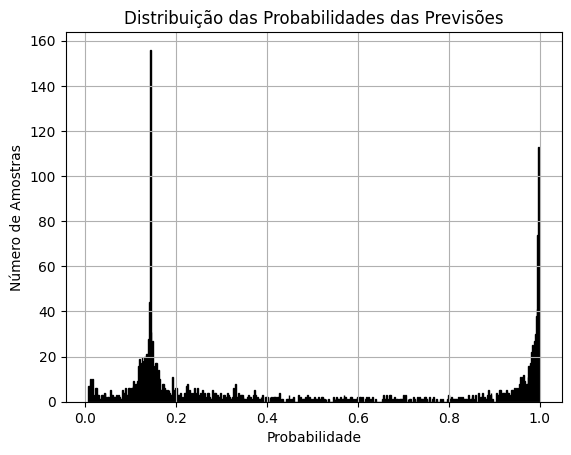

In [40]:
# Criar histograma das probabilidades
plt.hist(previsoes, bins=500, color="blue", edgecolor="black")

# Configurações do gráfico
plt.xlabel("Probabilidade")
plt.ylabel("Número de Amostras")
plt.title("Distribuição das Probabilidades das Previsões")
plt.grid(True)

# Exibir o gráfico
plt.show()

Usando o valor default de 0.5 traformar o vetor de previsões probabilisticas do modelo num vetor de labels. tudo acima de 0.5 vira 1 e tudo o resto vira 0.

In [41]:
# Converter probabilidades em classes binárias (0 ou 1)
classes_preditas = (previsoes > 0.5).astype(int)

# Exibir as classes binárias
print("Classes previstas (binárias):", classes_preditas)
print()
print(classes_preditas.shape)

Classes previstas (binárias): [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]

(2051, 1)


plot do número e percentagem de previsões positivas e negativas (0 e 1).

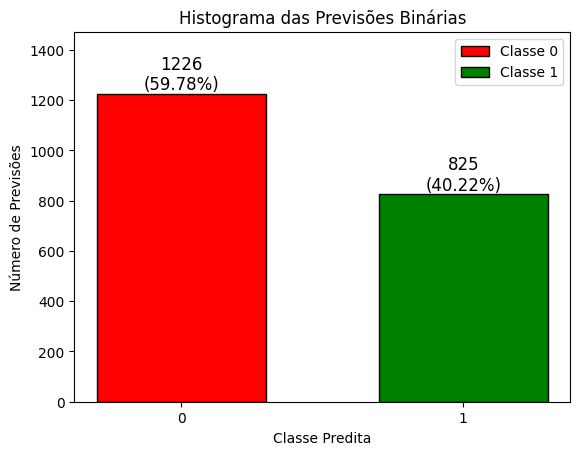

In [42]:
# Contar o número de 0s e 1s
num_zeros = np.sum(classes_preditas == 0)
num_uns = np.sum(classes_preditas == 1)

# Calcular as percentagens
percent_zero = (num_zeros / len(classes_preditas)) * 100
percent_one = (num_uns / len(classes_preditas)) * 100

# Criar histograma com cores específicas para cada classe
plt.bar([0], [num_zeros], color="red", edgecolor="black", width=0.6, label="Classe 0")
plt.bar([1], [num_uns], color="green", edgecolor="black", width=0.6, label="Classe 1")

# Adicionar contagem específica e percentagem a cada barra com uma margem acima para evitar sobreposição
plt.text(
    0,
    num_zeros + 0.1,
    f"{num_zeros}\n({percent_zero:.2f}%)",
    ha="center",
    va="bottom",
    fontsize=12,
)
plt.text(
    1,
    num_uns + 0.1,
    f"{num_uns}\n({percent_one:.2f}%)",
    ha="center",
    va="bottom",
    fontsize=12,
)

# Configurações do gráfico
plt.xticks([0, 1], ["0", "1"])
plt.xlabel("Classe Predita")
plt.ylabel("Número de Previsões")
plt.title("Histograma das Previsões Binárias")
plt.ylim(
    0, max(num_zeros, num_uns) * 1.2
)  # Ajusta o limite superior do eixo Y para dar espaço para o texto
plt.legend()

# Exibir o gráfico
plt.show()

Criar um tensor com as previões percentuais do modelo e a cada respetiva previsão o preço do atrivo em que o modelo estaria a atuar (open do espaço temporal seguinte). A ultima previsão obviamente não terá nehum preço associado pois nessa altura o trading da estrtégia já terá fechado, pois chegou ao fim dos do dataset.

In [43]:
# Inicializar uma lista para armazenar o tensor
tensor = []

# Criar o tensor para os primeiros 2051 elementos
for i in range(X_test.shape[0]):
    tensor.append([selected_subsets[i], previsoes[i, 0]])

# Adicionar o último elemento de selected_subsets com 'none' para previsoes
tensor.append([selected_subsets[X_test.shape[0]], "none"])

# Converter a lista para um array NumPy (dtype=object para lidar com tipos mistos)
tensor_np = np.array(tensor, dtype=object)

# Exibir o tensor final
print("Tensor final:")
print(tensor_np)
print(f"Shape do tensor: {tensor_np.shape}")

Tensor final:
[[168.88 0.10404381]
 [169.04 0.14351472]
 [169.015 0.13900673]
 ...
 [193.285 0.1457534]
 [192.1 0.15672211]
 [192.15 'none']]
Shape do tensor: (2052, 2)


# **Buy and Hold Classic**

Evolução natural de uma carteira sem estratégia (evolução do mercado).

Este código simula o que é que aconteceria se fosse gasto todo o dinheiro do portefólio em ações e no final do periodo temporal do dataset de teste vendidas todas as ações compradas no inicio. Estrtégia natural = holding basico.

In [44]:
# Inicializar variáveis para a evolução natural do mercado
initial_fund_natural = 100000  # Fundo inicial de $100,000
natural_fund = initial_fund_natural

# Comprar ações no segundo índice do tensor (primeira operação de compra)
initial_price_natural = float(tensor_np[1][0])  # Preço da ação no segundo índice
num_shares_natural = (
    natural_fund / initial_price_natural
)  # Quantidade de ações compradas (fracionárias)
natural_fund -= (
    num_shares_natural * initial_price_natural
)  # Atualiza o fundo após compra

print(
    f"Comprado {num_shares_natural:.6f} ações a {initial_price_natural} cada, fundo restante: ${natural_fund:.2f}"
)

# No final do tensor, vender todas as ações restantes
final_price_natural = float(tensor_np[-1][0])  # Preço final para venda
natural_fund += (
    num_shares_natural * final_price_natural
)  # Vende todas as ações restantes

print(
    f"Vendido {num_shares_natural:.6f} ações a {final_price_natural} cada no final, fundo total: ${natural_fund:.2f}"
)

# Calcular o percentual de crescimento
initial_investment = initial_fund_natural
final_value = natural_fund
percentage_increase = ((final_value - initial_investment) / initial_investment) * 100

print(
    f"\nPercentual de crescimento do fundo com a estratégia natural: {percentage_increase:.3f}%"
)

Comprado 591.575958 ações a 169.04 cada, fundo restante: $0.00
Vendido 591.575958 ações a 192.15 cada no final, fundo total: $113671.32

Percentual de crescimento do fundo com a estratégia natural: 13.671%


Este código permite dar plot ao que está a acontecer no mercado, que para o caso desta estratégia é o mesmo que está a acontecer á networth do nosso portafólio durante o período temporal do dataset de teste. Usando os closes como indicadores de preço do ativo em função do tempo. Calro que com uma maior ganularidade e se também se tivesse em conta o open a resolução do gráfico seria maior, mas a resolução do gráfico de nada afeta o estudo da estratégia e a sua veracidade, portanto não foi tido em conta, pois esses dados também nesta etapa já não se encontram disponíveis pois forma tratados. Para além disso se este problema da resolução do gráfico apenas é verdade se se encarar o gráfico como uma representação do mercad, no entanto se se encarar o gráfico como a networth ao longo do tempo do portefólio sobre esta estretégia o gráfico esté perfeito e a resolução maximizada.

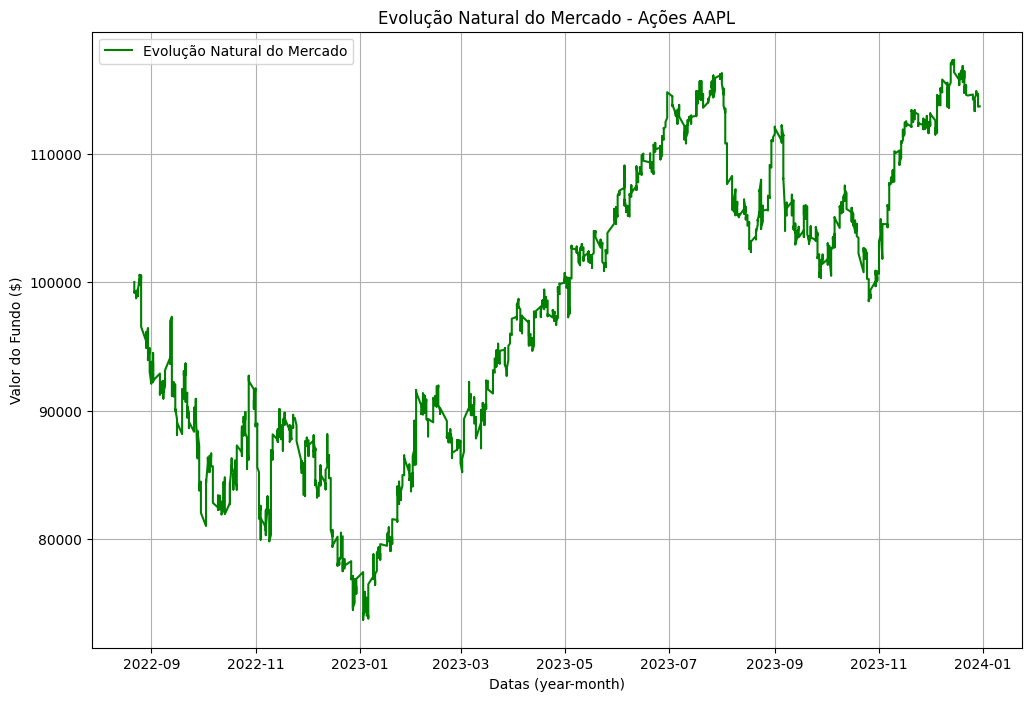

In [45]:
# Criar uma lista para armazenar a evolução do valor do fundo para a evolução natural do mercado
natural_fund_values = []

# Inicializar variáveis para a evolução natural do mercado
initial_fund = 100000  # Fundo inicial de $100,000
initial_price_natural = float(
    tensor_np[1][0]
)  # Preço da ação no segundo índice do tensor
num_shares_natural = (
    initial_fund / initial_price_natural
)  # Ações fracionárias compradas
current_fund_natural = initial_fund - num_shares_natural * initial_price_natural

# A primeira posição do fundo natural é logo após a compra inicial
natural_fund_values.append(
    current_fund_natural + num_shares_natural * initial_price_natural
)

# Simular a evolução natural do mercado
for i in range(1, len(tensor_np)):
    price = float(tensor_np[i][0])

    if i < len(tensor_np) - 1:
        # Atualizar a evolução natural do mercado ao longo do tempo
        natural_fund_values.append(current_fund_natural + num_shares_natural * price)

# Registrar o valor final para a evolução natural
final_price_natural = float(tensor_np[-1][0])
natural_fund_values.append(
    current_fund_natural + num_shares_natural * final_price_natural
)

# Gerar o gráfico da evolução do fundo
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    natural_fund_values,
    label="Evolução Natural do Mercado",
    color="green",
)

plt.title("Evolução Natural do Mercado - Ações " + symbol)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

#**Settings**

Ajustar a janela de valores dos coeficientes e da sensibilidade decisiva em estudo e as suas respectivas granularidades. A sensibilidade decisiva e os coeficientes encontram-se explicados mnas células seguintes.

In [46]:
# sensibilidade decisiva 1 e 2
Max_Selling_SD = 1
Min_Floor_SD = 0
Step_SD = 0.1

# todos os coeficientes
Max_Selling_Coefficient = 5
Min_Floor_Coefficient = 0
Step_Coefficient = 1

In [47]:
# Arrays para os parâmetros:
sensibilidade_decisiva1_array = np.arange(
    Min_Floor_SD, Max_Selling_SD + Step_SD, Step_SD
)  # Para sensibilidade decisiva 1
sensibilidade_decisiva2_array = np.arange(
    Min_Floor_SD, Max_Selling_SD + Step_SD, Step_SD
)  # Para sensibilidade decisiva 2
coeficiente_c_array = np.arange(
    Min_Floor_Coefficient, Max_Selling_Coefficient + Step_Coefficient, Step_Coefficient
)  # Para Compra
coeficiente_v_array = np.arange(
    Min_Floor_Coefficient, Max_Selling_Coefficient + Step_Coefficient, Step_Coefficient
)  # Para Venda
coeficiente_s_array = np.arange(
    Min_Floor_Coefficient, Max_Selling_Coefficient + Step_Coefficient, Step_Coefficient
)  # Coeficiente de Short-Selling

# **Estratégias de Gestão do Portefólio de Investimentos Sem Short-Selling**

Aqui seram estudadas todas as possíveis estratégias de gestão de portefólio com o modelo sem usar short-selling. Para estudar as seguintes estratégias será criado um portefólio virtual com 100 000$ que será gerido usando o modelo para prever o mercado e a respetiva estratégia de gestão de portefólio que estará a ser estudada. Isto permite simular o mais aproximado ppossível a gestão real de um portefólio com o modelo desenvolvido no alpaca e a estratégia escolhida e desenvolvida pelo SunTzu.

É imporante destacar que a networth de um portefólio é dado pela seguinte função:

Networth(localização temporal; modelo; estratégia; ativo; valor inicial = 100 000$$) = Valor_do_ativo(localização temporal; ativo) + Valor_Liquido_Guardado(localização temporal; modelo; estratégia; valor inicial = 100 000$)

Pela teoria dos grandes números basta o modelo ter uma precisão superior a 50% para que em média quanto mais tempo deixaremos a correr o modelo, ou seja, quantas mais iterasões (previsões) o modelo fizer sobre a bolsa com a estratégia correta mais os retornos da AI se vão distanciar de um simple holder, mais o modelo vai dar outeperform ao mercado. Portanto em teoria quanto mais tempo o modelo correr melhores seram os resultados.

Sensibilidade Decisiva trata-se do valor decimal que estipula a fronteira numerica entre o modelo dizer que uma probabilidade prevista corresponde à label 1 ou 0. A sensibilidade decisiva por default assume-se como 0.5. No entanto, a ideia é investigar exatamente qual é a mais correta consoante o modelo e consoate a estratégia de gestão de portefólio.

Iniciar os arrays de resultados para guardar os resultados das estretégias estudadas.

In [48]:
Results_Last_array = []
Results_Mean_array = []

### **Absolute Buy and Sell**

Comprar em absoluto, ou seja, gastar todo o dinheiro da carteira ao primeiro sinal positivo "1". Buy and Hold, ou seja, manter todo o dinheiro nas ações uma vez executada a compra. Vender em absoluto, ou seja, vender todo o dinheiro das ações ao primeiro sinal negativo "0". Repetir infinitamente o processo.



**Estudo da Melhor Sensibilidade Decisiva:**

Sensibilidade Decisiva trata-se do valor decimal que estibula a fronteira numerica entre o modelo dizer que uma probabilidade prevista corresponde à label 1 ou 0. A sensibilidade decisiva por default assume-se como 0.5. No entanto, a ideia é investigar exatamente qual é a mais correta consoante o modelo e consoate a estratégia de gestão de portefólio.

In [49]:
# Arrays para armazenar as diferenças percentuais e as médias de diferença percentual
percentages_diference_array = []
media_diff_percentual_array = []

# Lista para armazenar os resultados de cada combinação
results = []

# Iterar sobre todas as combinações de sensibilidade decisiva 1 (sd1) e sensibilidade decisiva 2 (sd2)
for sd1 in sensibilidade_decisiva1_array:
    for sd2 in sensibilidade_decisiva2_array:
        # Inicializar variáveis para cada combinação
        initial_fund = 100000  # Fundo inicial de $100,000
        fund = initial_fund
        num_shares = 0.0  # Número de ações detidas (permitindo frações)
        networth_strategy = []  # Armazenar o valor líquido ao longo do tempo

        # Iterar sobre o tensor (exceto a última entrada sem previsão)
        for i in range(len(tensor_np) - 1):
            current_price = float(
                tensor_np[i + 1][0]
            )  # Preço da ação para compra/venda
            prediction_str = tensor_np[i][1]  # Previsão atual

            if prediction_str != "none":
                prediction = float(prediction_str)

                # Cenário de queda: se a previsão estiver abaixo de sd1, vende todas as ações (se houver)
                if prediction < sd1 and num_shares > 0:
                    fund += num_shares * current_price
                    num_shares = 0.0

                # Cenário de alta: se a previsão estiver acima de sd2, compra ações com todo o dinheiro disponível
                elif prediction > sd2 and fund > 0:
                    num_shares_to_buy = fund / current_price
                    fund -= num_shares_to_buy * current_price
                    num_shares += num_shares_to_buy

                # Se a previsão estiver entre sd1 e sd2, não altera a posição (mantém as ações ou o dinheiro)

            # Armazenar o valor líquido da estratégia no instante atual
            networth_strategy.append(fund + num_shares * current_price)

        # Ao final do tensor, vender quaisquer ações remanescentes
        if num_shares > 0:
            final_price = float(tensor_np[-1][0])  # Preço final para venda
            fund += num_shares * final_price
            num_shares = 0.0

        # Calcular o percentual de crescimento da estratégia
        percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100

        # Armazenar a diferença percentual em relação à estratégia natural (baseline percentage_increase)
        diff_percentage = percentage_increase_strategy - percentage_increase
        percentages_diference_array.append(diff_percentage)

        # Armazenar o valor líquido final na estratégia
        networth_strategy.append(fund)

        # Calcular a diferença percentual ao longo do tempo em relação aos valores naturais do portfólio
        diff_percentual = (
            (np.array(networth_strategy) - np.array(natural_fund_values))
            / np.array(natural_fund_values)
        ) * 100
        media_diff_percentual = np.mean(diff_percentual)
        media_diff_percentual_array.append(media_diff_percentual)

        # Armazenar os resultados da combinação atual
        results.append(
            {
                "sensibilidade_decisiva1": sd1,
                "sensibilidade_decisiva2": sd2,
                "final_fund": fund,
                "percentage_increase_strategy": percentage_increase_strategy,
                "diff_percentage": diff_percentage,
                "media_diff_percentual": media_diff_percentual,
            }
        )

Assim este código permite plotar e analisar os retornos financeiros da estratégia implementada em função do valor da sensibilidade decisiva. O portefólio que ao começar com 100 000$ tiver os maiores retornos financeiros com a sensibilidade decisiva utilizada sinalarizará a melhor sensibilidade decisiva para a estratégia de gestão de portefólio e para o modelo.

É imporante destacar que o gráfico apresentado e os valores tidos em conta para escolher a sensibilidade decisiva pelo facto de estaremos à procura de uma estratégia que "derrote" o mercado o valor de retorno ao se estudar a estratégia é originado pela seguinte formula:

retorno percetual do investimento inicial da estratégia em estudo com a sensibilidade decisiva em vigor - retorno percentual do investimento inicial para um simples buy em holder = melhoria percentual

a melhoria percentual mais elevada corresponde á melhor sensibilidade decisiva.

Melhor combinação: Sensibilidade Decisiva 1 = 0.30, Sensibilidade Decisiva 2 = 0.80, Melhoria Percentual = 26.50%
Segunda melhor combinação: Sensibilidade Decisiva 1 = 0.80, Sensibilidade Decisiva 2 = 0.80, Melhoria Percentual = 24.75%
Terceira melhor combinação: Sensibilidade Decisiva 1 = 0.30, Sensibilidade Decisiva 2 = 0.90, Melhoria Percentual = 22.78%


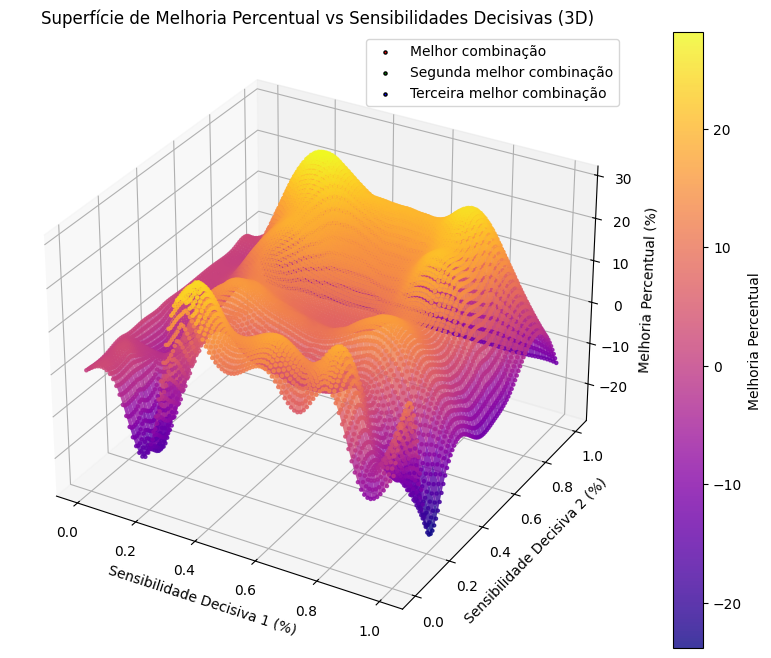

In [50]:
# Ordenar os resultados pela melhoria percentual (diff_percentage) em ordem decrescente
sorted_results = sorted(results, key=lambda x: x["diff_percentage"], reverse=True)

# Extrair os três melhores resultados
best_result = sorted_results[0]
second_best_result = sorted_results[1]
third_best_result = sorted_results[2]

# Dados para os três melhores resultados
best_sd1, best_sd2, best_diff = (
    best_result["sensibilidade_decisiva1"],
    best_result["sensibilidade_decisiva2"],
    best_result["diff_percentage"],
)
second_best_sd1, second_best_sd2, second_best_diff = (
    second_best_result["sensibilidade_decisiva1"],
    second_best_result["sensibilidade_decisiva2"],
    second_best_result["diff_percentage"],
)
third_best_sd1, third_best_sd2, third_best_diff = (
    third_best_result["sensibilidade_decisiva1"],
    third_best_result["sensibilidade_decisiva2"],
    third_best_result["diff_percentage"],
)

# Imprimir as três melhores combinações
print(
    f"Melhor combinação: Sensibilidade Decisiva 1 = {best_sd1:.2f}, Sensibilidade Decisiva 2 = {best_sd2:.2f}, Melhoria Percentual = {best_diff:.2f}%"
)
print(
    f"Segunda melhor combinação: Sensibilidade Decisiva 1 = {second_best_sd1:.2f}, Sensibilidade Decisiva 2 = {second_best_sd2:.2f}, Melhoria Percentual = {second_best_diff:.2f}%"
)
print(
    f"Terceira melhor combinação: Sensibilidade Decisiva 1 = {third_best_sd1:.2f}, Sensibilidade Decisiva 2 = {third_best_sd2:.2f}, Melhoria Percentual = {third_best_diff:.2f}%"
)

Results_Last_array.append([best_sd1, best_sd2, best_diff])

# Preparar os dados para o gráfico 3D
sd1_values = np.array([r["sensibilidade_decisiva1"] for r in results])
sd2_values = np.array([r["sensibilidade_decisiva2"] for r in results])
diff_values = np.array([r["diff_percentage"] for r in results])

# Criar uma grade regular para a interpolação
xi = np.linspace(sd1_values.min(), sd1_values.max(), 100)
yi = np.linspace(sd2_values.min(), sd2_values.max(), 100)
xi, yi = np.meshgrid(xi, yi)

# Interpolar os valores dos pontos para a grade (método 'cubic' para uma superfície suave)
zi = griddata((sd1_values, sd2_values), diff_values, (xi, yi), method="cubic")

# Criar o gráfico 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Plotar a superfície interpolada
surf = ax.plot_surface(xi, yi, zi, cmap="plasma", alpha=0.8, edgecolor="none")

# Plotar os pontos originais
sc = ax.scatter(xi, yi, zi, c=zi, cmap="plasma", s=5, alpha=0.8)

# Plotar os 3 melhores pontos
ax.scatter(
    best_sd1,
    best_sd2,
    best_diff,
    color="red",
    s=5,
    edgecolors="black",
    label="Melhor combinação",
)
ax.scatter(
    second_best_sd1,
    second_best_sd2,
    second_best_diff,
    color="green",
    s=5,
    edgecolors="black",
    label="Segunda melhor combinação",
)
ax.scatter(
    third_best_sd1,
    third_best_sd2,
    third_best_diff,
    color="blue",
    s=5,
    edgecolors="black",
    label="Terceira melhor combinação",
)

# Adicionar barra de cores para referência
fig.colorbar(surf, label="Melhoria Percentual")

# Configurar os rótulos dos eixos
ax.set_xlabel("Sensibilidade Decisiva 1 (%)")
ax.set_ylabel("Sensibilidade Decisiva 2 (%)")
ax.set_zlabel("Melhoria Percentual (%)")

plt.title("Superfície de Melhoria Percentual vs Sensibilidades Decisivas (3D)")
plt.legend()
plt.show()

Mais tarde precebeu-se que pode ser enganador apenas analisar o retorno no final do periodo temporal do dataset de teste. Para contornar esta questão foi desenvolvida outra metodologia.

Será capturado o retorno financeiro percentual em termos de networth do portefólio comparativamente com o valor inicial dado de 100 000$. Esse retorno financeiro a cada trade executada, ou melhor a cada matriz temporal analisada e prevista pelo o modelo será subtraindo o valor da networth de um portefólio que segue naturalmente o mercado (simple holder), para obter a "melhoria percentual". Mas desta ves estará se a obter a melhoria percentual a cada previsão do modelo. Ao se fazer a média da melhoria percentual ao longo de todas as previsões do modelo, ou seja, ao longo de todo o dataset de teste é possível preceber qual é a sensibilidade decisiva que maximiza o valor da "média da melhoria percentual". Desta forma é possível concluir qual é a melhor sensibilidade decisiva parqa este modelo e para esta estratégia anulando o impacto de estaremos a olhar para os retornos apenas de um evento temporal como o final do dataset de teste, mas sim tendo em conta a performance do modelo e da estrátegia ao longo de todo o dataset de teste.

Melhor combinação: Sensibilidade Decisiva 1 = 0.30, Sensibilidade Decisiva 2 = 0.80, Média Diferença Percentual = 20.42%
Segunda melhor combinação: Sensibilidade Decisiva 1 = 0.80, Sensibilidade Decisiva 2 = 0.80, Média Diferença Percentual = 18.90%
Terceira melhor combinação: Sensibilidade Decisiva 1 = 0.30, Sensibilidade Decisiva 2 = 0.90, Média Diferença Percentual = 17.78%


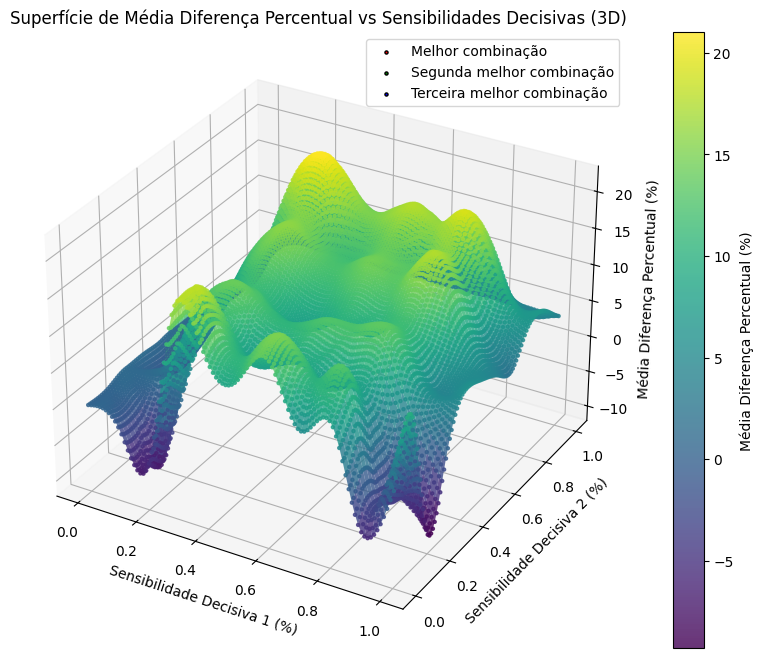

In [51]:
# Ordenar os resultados pela média da diferença percentual (media_diff_percentual) em ordem decrescente
sorted_results = sorted(results, key=lambda x: x["media_diff_percentual"], reverse=True)

# Extrair os três melhores resultados
best_result = sorted_results[0]
second_best_result = sorted_results[1]
third_best_result = sorted_results[2]

# Dados para os três melhores resultados
best_sd1 = best_result["sensibilidade_decisiva1"]
best_sd2 = best_result["sensibilidade_decisiva2"]
best_media_diff = best_result["media_diff_percentual"]

second_best_sd1 = second_best_result["sensibilidade_decisiva1"]
second_best_sd2 = second_best_result["sensibilidade_decisiva2"]
second_best_media_diff = second_best_result["media_diff_percentual"]

third_best_sd1 = third_best_result["sensibilidade_decisiva1"]
third_best_sd2 = third_best_result["sensibilidade_decisiva2"]
third_best_media_diff = third_best_result["media_diff_percentual"]

# Imprimir as três melhores combinações
print(
    f"Melhor combinação: Sensibilidade Decisiva 1 = {best_sd1:.2f}, Sensibilidade Decisiva 2 = {best_sd2:.2f}, Média Diferença Percentual = {best_media_diff:.2f}%"
)
print(
    f"Segunda melhor combinação: Sensibilidade Decisiva 1 = {second_best_sd1:.2f}, Sensibilidade Decisiva 2 = {second_best_sd2:.2f}, Média Diferença Percentual = {second_best_media_diff:.2f}%"
)
print(
    f"Terceira melhor combinação: Sensibilidade Decisiva 1 = {third_best_sd1:.2f}, Sensibilidade Decisiva 2 = {third_best_sd2:.2f}, Média Diferença Percentual = {third_best_media_diff:.2f}%"
)

Results_Mean_array.append([best_sd1, best_sd2, best_media_diff])

# Preparar os dados para o gráfico 3D
sd1_values = np.array([r["sensibilidade_decisiva1"] for r in results])
sd2_values = np.array([r["sensibilidade_decisiva2"] for r in results])
media_diff_values = np.array([r["media_diff_percentual"] for r in results])

# Criar uma grade regular para a interpolação
xi = np.linspace(sd1_values.min(), sd1_values.max(), 100)
yi = np.linspace(sd2_values.min(), sd2_values.max(), 100)
xi, yi = np.meshgrid(xi, yi)

# Interpolar os valores dos pontos para a grade (método 'cubic' para uma superfície suave)
zi = griddata((sd1_values, sd2_values), media_diff_values, (xi, yi), method="cubic")

# Criar o gráfico 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Plotar a superfície interpolada
surf = ax.plot_surface(xi, yi, zi, cmap="viridis", alpha=0.8, edgecolor="none")

# Plotar os pontos originais
sc = ax.scatter(xi, yi, zi, c=zi, cmap="viridis", s=5, alpha=0.8)

# Plotar os 3 melhores pontos
ax.scatter(
    best_sd1,
    best_sd2,
    best_media_diff,
    color="red",
    s=5,
    edgecolors="black",
    label="Melhor combinação",
)
ax.scatter(
    second_best_sd1,
    second_best_sd2,
    second_best_media_diff,
    color="green",
    s=5,
    edgecolors="black",
    label="Segunda melhor combinação",
)
ax.scatter(
    third_best_sd1,
    third_best_sd2,
    third_best_media_diff,
    color="blue",
    s=5,
    edgecolors="black",
    label="Terceira melhor combinação",
)

# Adicionar barra de cores para referência
fig.colorbar(surf, label="Média Diferença Percentual (%)")

# Configurar os rótulos dos eixos
ax.set_xlabel("Sensibilidade Decisiva 1 (%)")
ax.set_ylabel("Sensibilidade Decisiva 2 (%)")
ax.set_zlabel("Média Diferença Percentual (%)")

plt.title("Superfície de Média Diferença Percentual vs Sensibilidades Decisivas (3D)")
plt.legend()
plt.show()

**Analisando o melhor caso dado pela melhor média de diferança entre o mercado e a estratégia:**

Nesta parte do algoritmo dedicamo-nos a analisar detalhadamente o que é que acontece para um valor em especifico de sensibilidade decisiva.

Geralmente a ideia é analisar detalhadamente o que é que acontec com o valor considerado ideal encotrado anteriormente.

Escolhe-se o valor da sensibilidade decisiva que se quer estudar.

In [52]:
# Definir os thresholds para as sensibilidades decisivas
sensibilidade_decisiva1 = best_sd1
print(f"Sensibilidade Decisiva 1: {sensibilidade_decisiva1}")
sensibilidade_decisiva2 = best_sd2
print(f"Sensibilidade Decisiva 2: {sensibilidade_decisiva2}")

Sensibilidade Decisiva 1: 0.30000000000000004
Sensibilidade Decisiva 2: 0.8


Todas as trasações executadas para a estratégia com esta sensibilidade decisiva. Assim como um acaompanhamento do balanço ações/dinheiro do portefólio.

In [53]:
# Inicializar variáveis
initial_fund = 100000.0  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0  # Número de ações atualmente detidas (permitindo frações)
networth_strategy = []  # Lista para armazenar a evolução do fundo

print("=" * 60)
print("Início da Simulação de Transações")
print("=" * 60)

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_np) - 1):
    current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
    prediction = tensor_np[i][1]  # Previsão atual

    print(f"\nPeríodo {i + 1}:")
    print("-" * 60)
    print(f"Preço da ação: ${current_price:.2f}")
    print(f"Previsão: {prediction}")

    # Verificar se há previsão válida
    if prediction != "none":
        prediction_val = float(prediction)

        # Cenário de venda: previsão baixa e ações em carteira
        if prediction_val < sensibilidade_decisiva1 and num_shares > 0:
            sale_value = num_shares * current_price
            fund += sale_value
            print(
                f">>> Sinal de VENDA detectado! (Previsão {prediction_val:.2f} < {sensibilidade_decisiva1})"
            )
            print(
                f"Vendido {num_shares:.6f} ações a ${current_price:.2f} cada, total recebido: ${sale_value:.2f}"
            )
            print(f"Fundo atualizado: ${fund:.2f}")
            num_shares = 0.0

        # Cenário de compra: previsão alta e fundos disponíveis
        elif prediction_val > sensibilidade_decisiva2 and fund > 0:
            num_shares_to_buy = fund / current_price
            cost = num_shares_to_buy * current_price
            fund -= cost
            num_shares += num_shares_to_buy
            print(
                f">>> Sinal de COMPRA detectado! (Previsão {prediction_val:.2f} > {sensibilidade_decisiva2})"
            )
            print(
                f"Comprado {num_shares_to_buy:.6f} ações a ${current_price:.2f} cada, custo total: ${cost:.2f}"
            )
            print(f"Fundo restante: ${fund:.2f}")

        # Caso a previsão esteja entre os dois thresholds, mantém a posição
        else:
            print(">>> Nenhuma operação executada. Mantendo posição atual.")

    else:
        print(">>> Previsão 'none' detectada. Nenhuma operação executada.")

    current_networth = fund + num_shares * current_price
    print(f"Valor líquido atual (fundo + ações): ${current_networth:.2f}")
    networth_strategy.append(current_networth)

# No final do tensor, vender quaisquer ações restantes
if num_shares > 0:
    final_price = float(tensor_np[-1][0])
    final_sale_value = num_shares * final_price
    fund += final_sale_value
    print("\n" + "=" * 60)
    print("Período Final:")
    print(f"Preço final da ação: ${final_price:.2f}")
    print(
        f">>> Vendendo {num_shares:.6f} ações restantes a ${final_price:.2f} cada, total recebido: ${final_sale_value:.2f}"
    )
    num_shares = 0.0
    print(f"Fundo final atualizado: ${fund:.2f}")
    print("=" * 60)

print("\n" + "=" * 60)
print("Fim da Simulação de Transações")
print("=" * 60)

networth_strategy.append(fund)

# Exibir o balanço final do fundo
print("\nBalanço final do fundo de investimento: ${:.2f}".format(fund))

# Calcular o percentual de crescimento
percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
print(
    "Percentual de crescimento do fundo com a estratégia: {:.3f}%".format(
        percentage_increase_strategy
    )
)

Início da Simulação de Transações

Período 1:
------------------------------------------------------------
Preço da ação: $169.04
Previsão: 0.10404381155967712
>>> Nenhuma operação executada. Mantendo posição atual.
Valor líquido atual (fundo + ações): $100000.00

Período 2:
------------------------------------------------------------
Preço da ação: $169.01
Previsão: 0.1435147225856781
>>> Nenhuma operação executada. Mantendo posição atual.
Valor líquido atual (fundo + ações): $100000.00

Período 3:
------------------------------------------------------------
Preço da ação: $167.66
Previsão: 0.13900673389434814
>>> Nenhuma operação executada. Mantendo posição atual.
Valor líquido atual (fundo + ações): $100000.00

Período 4:
------------------------------------------------------------
Preço da ação: $167.70
Previsão: 0.33015176653862
>>> Nenhuma operação executada. Mantendo posição atual.
Valor líquido atual (fundo + ações): $100000.00

Período 5:
--------------------------------------

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva para este modelo.

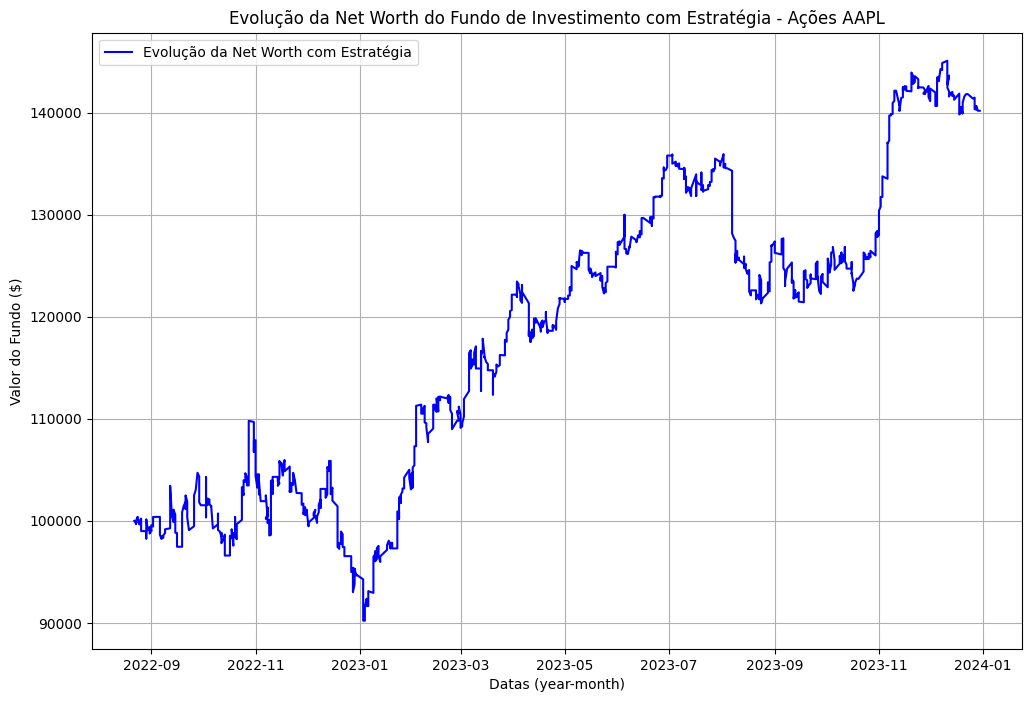

In [54]:
# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    networth_strategy,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)

plt.title(
    "Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações " + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva para este modelo. Combinado com o plot da estratégia mais basica que acompanha e é igual a olhar para o mercado diretamente - simpler long-holder.

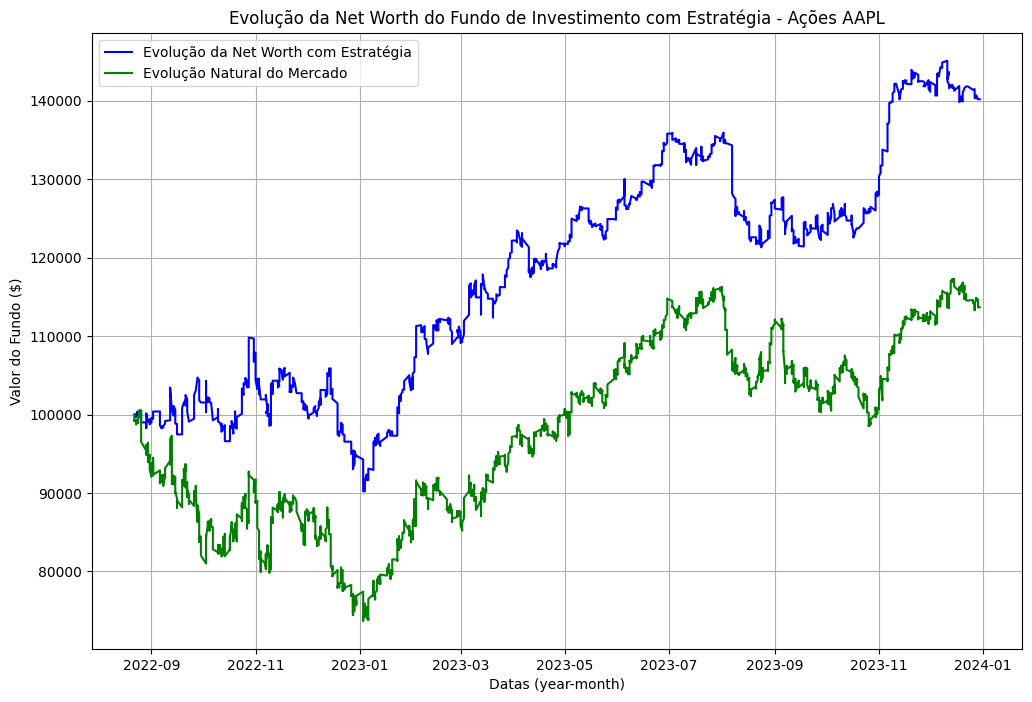

In [55]:
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    networth_strategy,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)
plt.plot(
    last_subsets_dates,
    natural_fund_values,
    label="Evolução Natural do Mercado",
    color="green",
)

plt.title(
    "Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações " + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Quanto dinheiro a mais se ganhou ao se ter usado este modelo com esta estratégia no final do periodo do dataset de teste?

Dinheiro ganho com esta estratégia - Dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

Melhoria percentual ao se ter usado esta estratégia:

aumento percentual do dinheiro ganho com esta estratégia - aumento percentual do dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

In [56]:
print(
    f"Dinheiro extra ganho ao se ter usado AI: {fund - percentage_increase - final_value:.3f}$"
)

print(
    f"\nMelhoria percentual ao se ter usado AI: {percentage_increase_strategy - percentage_increase:.3f}%"
)

Dinheiro extra ganho ao se ter usado AI: 26487.316$

Melhoria percentual ao se ter usado AI: 26.501%


Diferença percentual = Melhoria Percentual

Plot do gráfico que nos dá a melhoria percentual ao longo de todo o dataset. O valor da sensibilidade decisiva deve de ser dada pela média mais elevada de valores de melhoria percentual ao longo de todo este gráfico em função da sensibilidade decisiva.

Melhoria decisiva = ganho percentual da estratégia com o modelo - ganho percentual de um simple holder

simple holder = natural fund values

Coordenadas do valor máximo absoluto:
Data: 2023-03-13
Diferença Percentual Máxima: 33.95%
Média da Diferença Percentual ao Longo de Todo o Gráfico: 20.42%


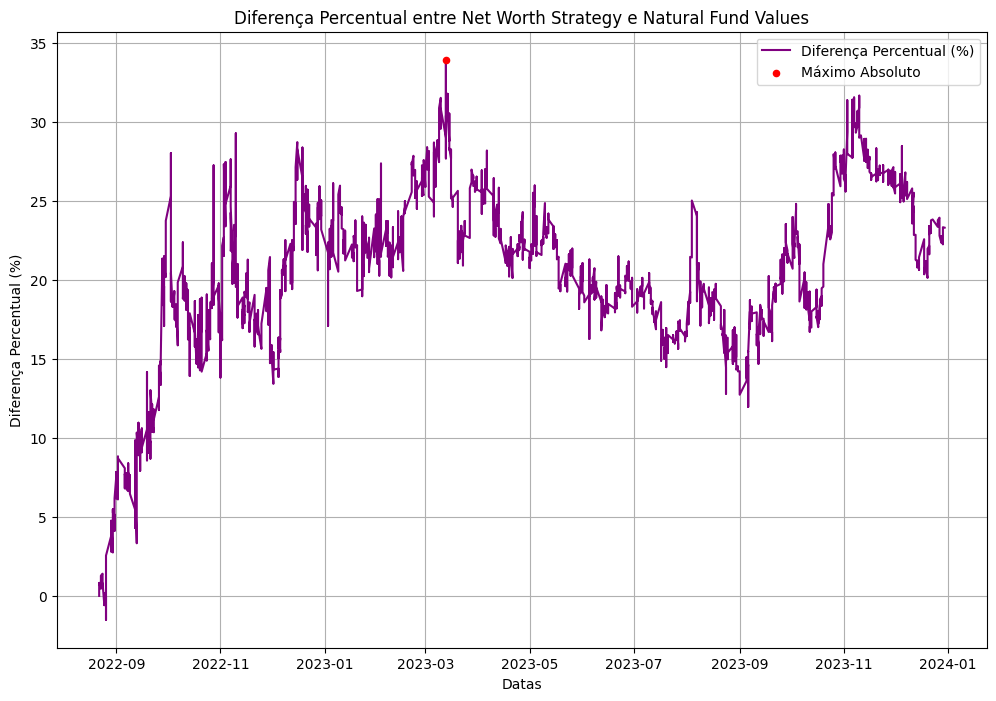

In [57]:
# Calcular a diferença percentual
diff_percentual = (
    (np.array(networth_strategy) - np.array(natural_fund_values))
    / np.array(natural_fund_values)
) * 100

# Encontrar o índice do valor máximo absoluto da diferença percentual
max_index = np.argmax(diff_percentual)

# Coordenadas do valor máximo
max_diff_percentual = diff_percentual[max_index]
max_date = last_subsets_dates[max_index]

print(f"Coordenadas do valor máximo absoluto:")
print(f"Data: {max_date}")
print(f"Diferença Percentual Máxima: {max_diff_percentual:.2f}%")

# Traçar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    diff_percentual,
    label="Diferença Percentual (%)",
    color="purple",
)

# Adicionar o ponto máximo ao gráfico
plt.scatter(
    max_date, max_diff_percentual, color="red", s=20, zorder=5, label="Máximo Absoluto"
)

# Rótulos e título
plt.title("Diferença Percentual entre Net Worth Strategy e Natural Fund Values")
plt.xlabel("Datas")
plt.ylabel("Diferença Percentual (%)")

# Calcular a média da diferença percentual
media_diff_percentual = np.mean(diff_percentual)

# Printar o valor médio
print(
    f"Média da Diferença Percentual ao Longo de Todo o Gráfico: {media_diff_percentual:.2f}%"
)

# Adicionar a legenda e grid
plt.legend()
plt.grid(True)

# Mostrar o gráfico
plt.show()

Pela teoria dos grandes números basta o modelo ter uma precisão superior a 50% para que em média quanto mais tempo deixaremos a correr o modelo, ou seja, quantas mais iterasões (previsões) o modelo fizer sobre a bolsa com a estratégia correta mais os retornos da AI se vão distanciar de um simple holder, mais o modelo vai dar outeperform ao mercado. Portanto em teoria quanto mais tempo o modelo correr melhores seram os resultados.

**Estudo do Retorno em Função do Valor Inicial do Fundo:**

Este plot foi feito apenas por descargo de consciência e investigação se poderiam exitir algum tipo de anomalias no código. Ele investiga o retorno percentual no final do dataset de teste em função do investimento inicial que por default é feito com 100 000$. Como era de esperar o retorno percentual não varia consoante o investimento inicial, pois foi permitido o trade na bolsa de ações percentuais.

Atenção este gráfico apresenta o ganho percentual bruto da AI e não a melhoria percentual.

Coordenadas do ponto máximo absoluto: Dinheiro Inicial = $2626338.89, Percentual de Crescimento = 40.172%


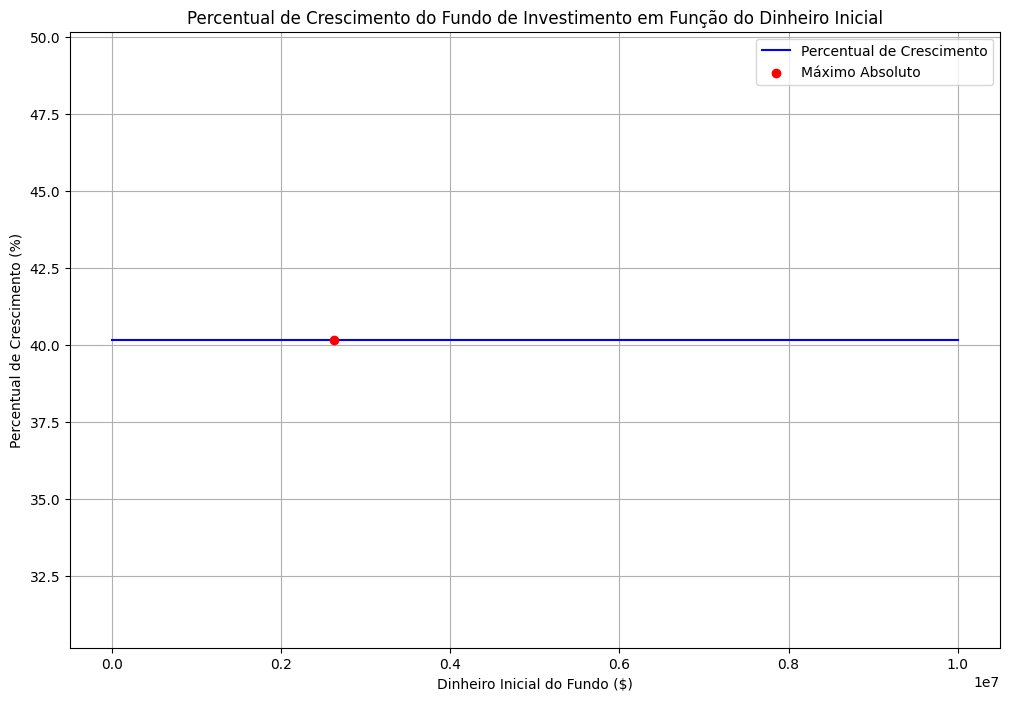

In [58]:
# Definir a faixa de valores para o fundo inicial
initial_fund_values = np.linspace(50, 10000150, 100)  # Valores de $50 a $10,000,000

# Lista para armazenar os resultados: percentual de crescimento para cada valor inicial
percentual_ganhos = []

# Loop sobre todos os valores de fundo inicial
for initial_fund in initial_fund_values:
    fund = initial_fund
    num_shares = 0.0  # Número de ações atualmente detidas (permitindo frações)

    # Iterar pelo tensor (exceto o último que não tem previsão)
    for i in range(len(tensor_np) - 1):
        current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
        prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

        # Converter a previsão para float se válida, caso contrário definir como 0
        if prediction_str != "none":
            prediction = float(prediction_str)
        else:
            prediction = 0

        # Se a previsão indicar cenário de queda (abaixo do threshold de venda) e houver ações, vende
        if prediction < sensibilidade_decisiva1 and num_shares > 0:
            fund += num_shares * current_price  # Vende todas as ações
            num_shares = 0.0

        # Se a previsão indicar cenário de alta (acima do threshold de compra) e houver fundos, compra
        elif prediction > sensibilidade_decisiva2 and fund > 0:
            num_shares_to_buy = (
                fund / current_price
            )  # Quantidade de ações que podemos comprar
            fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
            num_shares += num_shares_to_buy

        # Se a previsão estiver entre os thresholds, nenhuma operação é executada

    # No final do tensor, vender quaisquer ações remanescentes
    if num_shares > 0:
        final_price = float(tensor_np[-1][0])  # Preço final para venda
        fund += num_shares * final_price  # Vende todas as ações restantes
        num_shares = 0.0

    # Calcular o percentual de crescimento da estratégia para este fundo inicial
    percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
    percentual_ganhos.append(percentage_increase_strategy)

# Encontrar o índice do valor máximo de percentual_ganhos
max_index = np.argmax(percentual_ganhos)
max_initial_fund = initial_fund_values[max_index]
max_percentage_increase = percentual_ganhos[max_index]

print(
    f"Coordenadas do ponto máximo absoluto: Dinheiro Inicial = ${max_initial_fund:.2f}, Percentual de Crescimento = {max_percentage_increase:.3f}%"
)

# Plotar o gráfico do Percentual de Crescimento em função do Dinheiro Inicial
plt.figure(figsize=(12, 8))
plt.plot(
    initial_fund_values,
    percentual_ganhos,
    label="Percentual de Crescimento",
    color="blue",
)
plt.scatter(
    max_initial_fund,
    max_percentage_increase,
    color="red",
    zorder=5,
    label="Máximo Absoluto",
)  # Destacar o ponto máximo
plt.ylim(min(percentual_ganhos) - 10, max(percentual_ganhos) + 10)
plt.title(
    "Percentual de Crescimento do Fundo de Investimento em Função do Dinheiro Inicial"
)
plt.xlabel("Dinheiro Inicial do Fundo ($)")
plt.ylabel("Percentual de Crescimento (%)")
plt.grid(True)
plt.legend()
plt.show()

### **Independent Parcial Buy and Sell in Function of Predictions Probabilaty**

Agora eu quero testar uma nova estratégia. As compras e as vendas vão ser de forma percentual. Ou seja, sempre que existe um sinal positivo para compra - "1", deve ser gasto "coeficiente * grau_certeza"% (o grau_certeza é dado por "predictions", relembrando que sempre que "predictions" é superior a "sensibilidade_decisiva" é um "1" e sempre que "predictions" é inferior a "sensibilidade_decisiva" é um "0", o grau_certeza é pela certeza que o modelo tem se se trata de um "0" ou de um "1", isto pode ser inferido através de "predictions") do dinheiro do fundo de investimento na compra de ações, se existir algum dinheiro ainda no fundo para o fazer de acordo com o percentual calculado. Sempre que existe um sinal positivo de venda - "0", devem ser vendidas "coeficiente * grau_certeza"% das ações do fundo de investimento, se o fundo tiver ainda ações suficientes para o fazer de acordo com a percentagem calculada. A questão que aqui diferencia da passada estratégia é que agora vão existir 2 coeficientes em jogo um coeficente para ações de venda, coeficiente_v, outro para ações de compra, coeficiente_c.

Esta estratégia é extremamente semelhante á anterior apenas é acrecenta um novo coeficiente e para tal terá de ser distinguido o coeficiente de buy do coeficiente de sell.

if prediction > sensibilidade_decisiva and fund > 0:
    grau_certeza = abs(prediction)  # Grau de certeza do modelo
    # Comprar ações com base no percentual calculado
    amount_to_invest = coeficiente_c * grau_certeza * fund
    num_shares_to_buy = amount_to_invest / current_price  # Quantidade de ações que podemos comprar (fracionária)
    fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
    num_shares += num_shares_to_buy  # Atualiza o número de ações

elif prediction <= sensibilidade_decisiva and num_shares > 0:
    grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
    # Vender ações com base no percentual calculado
    amount_to_sell = coeficiente_v * grau_certeza * num_shares  # Quantidade de ações a vender
    num_shares_to_sell = amount_to_sell  # Quantidade fracionária de ações a vender
    fund += num_shares_to_sell * current_price  # Vende as ações e atualiza o fundo
    num_shares -= num_shares_to_sell  # Atualiza o número de ações após a venda

Por este código passam 3 loops diferentes todos uns dentro uns dos outros assim consigo garantir que para cada coeficiente de compra é testado para todos os valores de coeficiente de venda e para todos os valores de sensibilidade decisiva.

**Estudo do Melhor Coeficiente e Melhor Sensibilidade Decisiva para Formatar o Percentual Investido:**

Assim este código permite plotar e analisar os retornos financeiros da estratégia implementada em função do valor da sensibilidade decisiva e do coeficientes. O portefólio que ao começar com 100 000$ tiver os maiores retornos financeiros com a sensibilidade decisiva e com o coeficientes utilizados sinalarizará a melhor combinação sensibilidade decisiva, coeficiente para a estratégia de gestão de portefólio e para o modelo.

É imporante destacar que o gráfico apresentado e os valores tidos em conta para escolher a sensibilidade decisiva pelo facto de estaremos à procura de uma estratégia que "derrote" o mercado o valor de retorno ao se estudar a estratégia é originado pela seguinte formula:

retorno percetual do investimento inicial da estratégia em estudo com a sensibilidade decisiva e coefieciente em vigor - retorno percentual do investimento inicial para um simples buy em holder = melhoria percentual

a melhoria percentual mais elevada corresponde á melhor combinação sensibilidade decisiva, coeficientes.

In [59]:
# Fundo inicial
initial_fund = 100000  # $100,000

# Listas para armazenar os parâmetros e resultados
x_vals = []  # Sensibilidade Decisiva 1 (sd1 - VENDA)
y_vals = []  # Sensibilidade Decisiva 2 (sd2 - COMPRA)
z_vals = []  # Coeficiente C (Compra)
color_vals_media = []  # Média da Diferença Percentual (métrica de desempenho)
color_vals = []  # Ganho percentual relativo (percentual_ganho - percentage_increase)

# Loop aninhado: percorre as combinações de sd1, sd2, coeficiente_c e coeficiente_v.
# Apenas combinações onde sd1 < sd2 são válidas.
for sd1 in sensibilidade_decisiva1_array:
    for sd2 in sensibilidade_decisiva2_array:
        for coef_c in coeficiente_c_array:
            for coef_v in coeficiente_v_array:
                # Inicializar variáveis para cada combinação
                fund = initial_fund
                num_shares = 0.0
                networth_strategy = []

                # Iterar pelo tensor (exceto o último que não tem previsão)
                for m in range(len(tensor_np) - 1):
                    current_price = float(tensor_np[m + 1][0])
                    prediction_str = tensor_np[m][1]

                    if prediction_str != "none":
                        prediction = float(prediction_str)
                    else:
                        prediction = 0  # Se não houver previsão, define como 0

                    # Operação de COMPRA: se previsão > sd2 e houver fundos
                    if prediction > sd2 and fund > 0:
                        grau_certeza = abs(prediction)
                        percentage_to_spend = coef_c * grau_certeza
                        if percentage_to_spend > 1:
                            percentage_to_spend = 1
                        amount_to_invest = percentage_to_spend * fund
                        num_shares_to_buy = amount_to_invest / current_price
                        fund -= num_shares_to_buy * current_price
                        num_shares += num_shares_to_buy

                    # Operação de VENDA: se previsão < sd1 e houver ações
                    elif prediction < sd1 and num_shares > 0:
                        grau_certeza = abs(1 - prediction)
                        percentage_to_sell = coef_v * grau_certeza
                        if percentage_to_sell > 1:
                            percentage_to_sell = 1
                        amount_to_sell = percentage_to_sell * num_shares
                        fund += amount_to_sell * current_price
                        num_shares -= amount_to_sell

                    # Registrar o valor líquido atual (fundo + ações)
                    networth_strategy.append(fund + num_shares * current_price)

                # Ao final, vender quaisquer ações remanescentes
                if num_shares > 0:
                    final_price = float(tensor_np[-1][0])
                    fund += num_shares * final_price
                    num_shares = 0
                networth_strategy.append(fund)

                # Calcular o percentual de crescimento do fundo
                percentual_ganho = ((fund - initial_fund) / initial_fund) * 100

                # Calcular a diferença percentual entre a estratégia simulada e um fundo natural
                diff_percentual = (
                    (np.array(networth_strategy) - np.array(natural_fund_values))
                    / np.array(natural_fund_values)
                ) * 100
                media_diff_percentual = np.mean(diff_percentual)

                # Armazenar os parâmetros e resultados para plotagem
                x_vals.append(sd1)
                y_vals.append(sd2)
                z_vals.append(coef_c)
                color_vals_media.append(media_diff_percentual)
                color_vals.append(percentual_ganho - percentage_increase)

Top 1 ponto: Sensibilidade Decisiva 1 (Venda) = 0.30, Sensibilidade Decisiva 2 (Compra) = 0.80, Coeficiente C (Compra) = 3.00, Coeficiente V (Venda) = 3.00, Ganho Percentual (%) = 27.4344
Top 2 ponto: Sensibilidade Decisiva 1 (Venda) = 0.30, Sensibilidade Decisiva 2 (Compra) = 0.80, Coeficiente C (Compra) = 5.00, Coeficiente V (Venda) = 5.00, Ganho Percentual (%) = 27.4344
Top 3 ponto: Sensibilidade Decisiva 1 (Venda) = 0.30, Sensibilidade Decisiva 2 (Compra) = 0.80, Coeficiente C (Compra) = 4.00, Coeficiente V (Venda) = 4.00, Ganho Percentual (%) = 27.4344


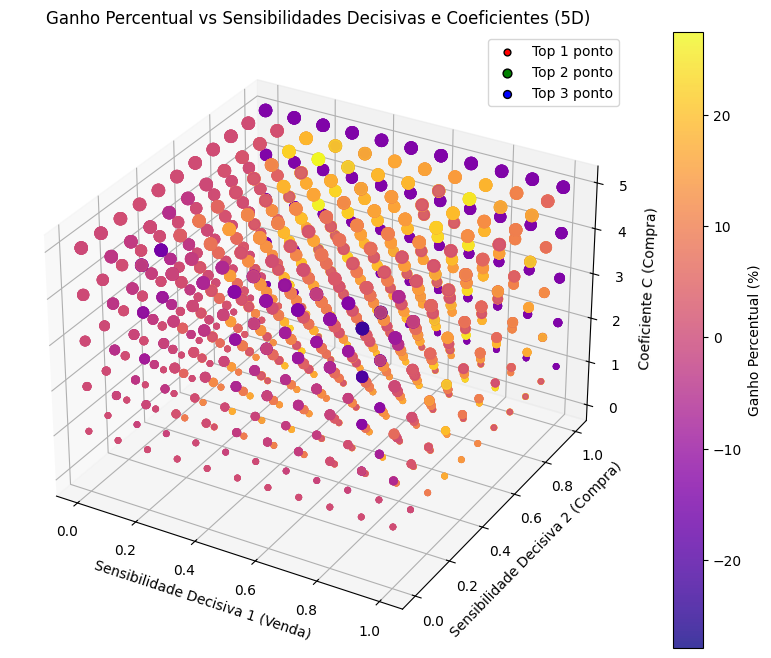

In [60]:
# Converter as listas para arrays numpy
sd1_vals = np.array(x_vals)  # Sensibilidade Decisiva 1 (VENDA)
sd2_vals = np.array(y_vals)  # Sensibilidade Decisiva 2 (COMPRA)
coef_c_vals = np.array(z_vals)  # Coeficiente C (Compra)
coef_v_vals = np.array(z_vals)  # Coeficiente V (Venda)
gain_vals = np.array(color_vals)  # Ganho Percentual (resultado da estratégia)

# Escolher um fator de escala para o tamanho dos marcadores (ajuste conforme necessário)
marker_size = coef_v_vals * 15  # Exemplo: multiplica o coeficiente V por 100

# Criar o gráfico 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Scatter plot 3D: os pontos são posicionados por (sd1, sd2, coeficiente C)
# O tamanho dos pontos reflete o coeficiente V e a cor indica o ganho percentual
img = ax.scatter(
    sd1_vals,
    sd2_vals,
    coef_c_vals,
    c=gain_vals,
    cmap="plasma",
    s=marker_size,
    alpha=0.8,
)

# Barra de cor para representar o ganho percentual
cbar = fig.colorbar(img)
cbar.set_label("Ganho Percentual (%)")

ax.set_title("Ganho Percentual vs Sensibilidades Decisivas e Coeficientes (5D)")
ax.set_xlabel("Sensibilidade Decisiva 1 (Venda)")
ax.set_ylabel("Sensibilidade Decisiva 2 (Compra)")
ax.set_zlabel("Coeficiente C (Compra)")

# Identificar os 3 melhores pontos com base no ganho percentual
top3_indices = np.argsort(gain_vals)[-3:][
    ::-1
]  # Índices dos 3 maiores ganhos (ordem decrescente)

# Cores para os 3 melhores pontos
colors = ["red", "green", "blue"]

# Imprimir e plotar os 3 melhores pontos
for rank, idx in enumerate(top3_indices, start=1):
    x = sd1_vals[idx]
    y = sd2_vals[idx]
    z = coef_c_vals[idx]
    cv = coef_v_vals[idx]
    gain = gain_vals[idx]
    print(
        f"Top {rank} ponto: Sensibilidade Decisiva 1 (Venda) = {x:.2f}, Sensibilidade Decisiva 2 (Compra) = {y:.2f}, Coeficiente C (Compra) = {z:.2f}, Coeficiente V (Venda) = {cv:.2f}, Ganho Percentual (%) = {gain:.4f}"
    )

    if rank == 1:
        Results_Last_array.append([x, y, z, cv, gain])

    # Plotar o ponto com destaque (tamanho proporcional ao coeficiente V)
    ax.scatter(
        x,
        y,
        z,
        color=colors[rank - 1],
        s=cv * 8,
        edgecolors="black",
        label=f"Top {rank} ponto",
    )

plt.legend()
plt.show()

Mais tarde precebeu-se que pode ser enganador apenas analisar o retorno no final do periodo temporal do dataset de teste. Para contornar esta questão foi desenvolvida outra metodologia.

Será capturado o retorno financeiro percentual em termos de networth do portefólio comparativamente com o valor inicial dado de 100 000$. Esse retorno financeiro a cada trade executada, ou melhor a cada matriz temporal analisada e prevista pelo o modelo será subtraindo o valor da networth de um portefólio que segue naturalmente o mercado (simple holder), para obter a "melhoria percentual". Mas desta ves estará se a obter a melhoria percentual a cada previsão do modelo. Ao se fazer a média da melhoria percentual ao longo de todas as previsões do modelo, ou seja, ao longo de todo o dataset de teste é possível preceber qual é a combinação sensibilidade decisiva, coeficientes que maximiza o valor da "média da melhoria percentual". Desta forma é possível concluir qual é a melhor combinação sensibilidade decisiva, coeficientes para este modelo e para esta estratégia anulando o impacto de estaremos a olhar para os retornos apenas de um evento temporal como o final do dataset de teste, mas sim tendo em conta a performance do modelo e da estrátegia ao longo de todo o dataset de teste.

Top 1 ponto: Sensibilidade Decisiva 1 (Venda) = 0.30, Sensibilidade Decisiva 2 (Compra) = 0.80, Coeficiente C (Compra) = 5.00, Coeficiente V (Venda) = 5.00, Média Diferença Percentual (%) = 20.4209
Top 2 ponto: Sensibilidade Decisiva 1 (Venda) = 0.30, Sensibilidade Decisiva 2 (Compra) = 0.80, Coeficiente C (Compra) = 2.00, Coeficiente V (Venda) = 2.00, Média Diferença Percentual (%) = 20.4209
Top 3 ponto: Sensibilidade Decisiva 1 (Venda) = 0.30, Sensibilidade Decisiva 2 (Compra) = 0.80, Coeficiente C (Compra) = 5.00, Coeficiente V (Venda) = 5.00, Média Diferença Percentual (%) = 20.4209


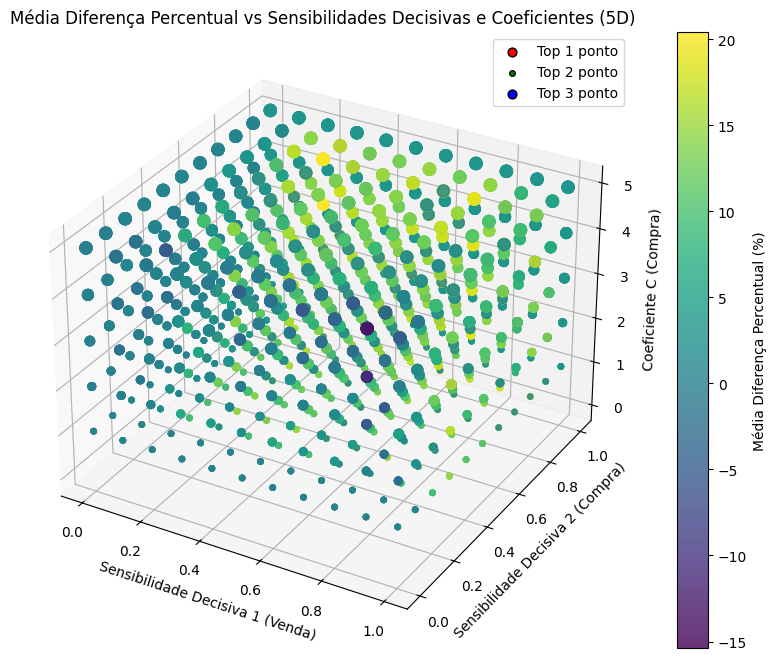

In [61]:
# Converter as listas para arrays numpy
sd1_vals = np.array(x_vals)  # Sensibilidade Decisiva 1 (VENDA)
sd2_vals = np.array(y_vals)  # Sensibilidade Decisiva 2 (COMPRA)
coef_c_vals = np.array(z_vals)  # Coeficiente C (Compra)
coef_v_vals = np.array(z_vals)  # Coeficiente V (Venda)
media_diff_vals = np.array(
    color_vals_media
)  # Média Diferença Percentual para cada combinação

# Definir o tamanho dos marcadores a partir do coeficiente V (ajuste conforme necessário)
marker_size = coef_v_vals * 15  # Exemplo: multiplica o coeficiente V por 100

# Criar o gráfico 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Scatter plot 3D:
#   - X: Sensibilidade Decisiva 1 (VENDA)
#   - Y: Sensibilidade Decisiva 2 (COMPRA)
#   - Z: Coeficiente C (Compra)
#   - Tamanho: proporcional ao Coeficiente V (Venda)
#   - Cor: representa a Média Diferença Percentual
img = ax.scatter(
    sd1_vals,
    sd2_vals,
    coef_c_vals,
    c=media_diff_vals,
    cmap="viridis",
    s=marker_size,
    alpha=0.8,
)

# Adicionar barra de cor
cbar = fig.colorbar(img)
cbar.set_label("Média Diferença Percentual (%)")

# Configurar os rótulos e título
ax.set_title(
    "Média Diferença Percentual vs Sensibilidades Decisivas e Coeficientes (5D)"
)
ax.set_xlabel("Sensibilidade Decisiva 1 (Venda)")
ax.set_ylabel("Sensibilidade Decisiva 2 (Compra)")
ax.set_zlabel("Coeficiente C (Compra)")

# Identificar os 3 melhores pontos com base na Média Diferença Percentual
top3_indices = np.argsort(media_diff_vals)[-3:][
    ::-1
]  # índices dos 3 maiores valores em ordem decrescente

# Cores para destacar os 3 melhores pontos
top_colors = ["red", "green", "blue"]

# Imprimir e plotar os 3 melhores pontos
for rank, idx in enumerate(top3_indices, start=1):
    sd1_best = sd1_vals[idx]
    sd2_best = sd2_vals[idx]
    coef_c_best = coef_c_vals[idx]
    coef_v_best = coef_v_vals[idx]
    diff_best = media_diff_vals[idx]

    print(
        f"Top {rank} ponto: Sensibilidade Decisiva 1 (Venda) = {sd1_best:.2f}, Sensibilidade Decisiva 2 (Compra) = {sd2_best:.2f}, Coeficiente C (Compra) = {coef_c_best:.2f}, Coeficiente V (Venda) = {coef_v_best:.2f}, Média Diferença Percentual (%) = {diff_best:.4f}"
    )

    if rank == 1:
        Results_Mean_array.append(
            [sd1_best, sd2_best, coef_c_best, coef_v_best, diff_best]
        )

    # Destacar os 3 melhores pontos no gráfico
    ax.scatter(
        sd1_best,
        sd2_best,
        coef_c_best,
        color=top_colors[rank - 1],
        s=coef_v_best * 8,
        edgecolors="black",
        label=f"Top {rank} ponto",
    )

plt.legend()
plt.show()

**Analisando o melhor caso dado pela melhor média de diferança entre o mercado e a estratégia:**

Nesta parte do algoritmo dedicamo-nos a analisar detalhadamente o que é que acontece para uma combinação especifica de sensibilidade decisiva e coeficientes.

Geralmente a ideia é analisar detalhadamente o que é que acontece com a combinação considerado ideal encotrado anteriormente.

In [62]:
sensibilidade_decisiva = round(Results_Mean_array[1][0], int(-math.log10(Step_SD)))
print(f"Sensibilidade Decisiva: {sensibilidade_decisiva}")
sensibilidade_decisiva2 = round(Results_Mean_array[1][1], int(-math.log10(Step_SD)))
print(f"Sensibilidade Decisiva 2: {sensibilidade_decisiva2}")
coeficiente_c = round(Results_Mean_array[1][2], int(-math.log10(Step_Coefficient)))
print(f"Coeficiente Compra: {coeficiente_c}")
coeficiente_v = round(Results_Mean_array[1][3], int(-math.log10(Step_Coefficient)))
print(f"Coeficiente Venda: {coeficiente_v}")

Sensibilidade Decisiva: 0.3
Sensibilidade Decisiva 2: 0.8
Coeficiente Compra: 5
Coeficiente Venda: 5


Todas as trasações executadas para a estratégia com esta sensibilidade decisiva. Assim como um acaompanhamento do balanço ações/dinheiro do portefólio.

In [63]:
# Inicializar variáveis
initial_fund = 100000  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0  # Número de ações detidas (podem ser fracionárias)
networth_strategy = []  # Armazenar a evolução do valor líquido (net worth)

print("=" * 60)
print("Início da Simulação de Transações com Duas Sensibilidades Decisivas")
print("=" * 60)

# Iterar pelos períodos do tensor (exceto o último, que não possui previsão)
for i in range(len(tensor_np) - 1):
    current_price = float(tensor_np[i + 1][0])  # Preço da ação para operação
    prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

    # Converter a previsão para float ou definir como 0 se não houver previsão
    if prediction_str != "none":
        prediction = float(prediction_str)
    else:
        prediction = 0

    # Imprimir informações do período
    print("\n" + "-" * 60)
    print(f"Período {i + 1}:")
    print(f"Preço da ação: ${current_price:.2f}")
    print(f"Previsão: {prediction:.2f}")

    # Verificar se deve comprar (previsão acima do threshold de compra e fundos disponíveis)
    if prediction > sensibilidade_decisiva2 and fund > 0:
        grau_certeza = abs(prediction)
        percentage_to_spend = (
            coeficiente_c * grau_certeza
        )  # Percentual do fundo a investir
        if percentage_to_spend > 1:
            percentage_to_spend = 1
        amount_to_spend = percentage_to_spend * fund
        num_shares_to_buy = amount_to_spend / current_price
        fund -= num_shares_to_buy * current_price
        num_shares += num_shares_to_buy
        print(
            f">>> Sinal de COMPRA detectado! (Previsão {prediction:.2f} > {sensibilidade_decisiva2})"
        )
        print(f"Comprado {num_shares_to_buy:.4f} ações a ${current_price:.2f} cada")
        print(f"Valor investido: ${amount_to_spend:.2f} | Fundo restante: ${fund:.2f}")

    # Verificar se deve vender (previsão abaixo do threshold de venda e ações disponíveis)
    elif prediction < sensibilidade_decisiva1 and num_shares > 0:
        grau_certeza = abs(1 - prediction)
        percentage_to_sell = (
            coeficiente_v * grau_certeza
        )  # Percentual das ações a vender
        if percentage_to_sell > 1:
            percentage_to_sell = 1
        amount_to_sell = percentage_to_sell * num_shares
        fund += amount_to_sell * current_price
        num_shares -= amount_to_sell
        print(
            f">>> Sinal de VENDA detectado! (Previsão {prediction:.2f} < {sensibilidade_decisiva1})"
        )
        print(f"Vendido {amount_to_sell:.4f} ações a ${current_price:.2f} cada")
        print(
            f"Valor obtido: ${amount_to_sell * current_price:.2f} | Fundo total: ${fund:.2f}"
        )

    else:
        print(">>> Nenhuma operação executada neste período. Posição mantida.")

    # Calcular e exibir o valor líquido (fundo + valor das ações)
    networth = fund + num_shares * current_price
    networth_strategy.append(networth)
    print(f"Valor líquido (Net Worth) neste período: ${networth:.2f}")

# No final, vender quaisquer ações remanescentes
if num_shares > 0:
    final_price = float(tensor_np[-1][0])
    fund += num_shares * final_price
    print("\n" + "=" * 60)
    print("Período Final:")
    print(f"Preço final da ação: ${final_price:.2f}")
    print(
        f">>> Vendendo {num_shares:.4f} ações remanescentes a ${final_price:.2f} cada"
    )
    print(f"Valor obtido: ${num_shares * final_price:.2f} | Fundo final: ${fund:.2f}")
    num_shares = 0
    print("=" * 60)

networth_strategy.append(fund)

# Exibir o balanço final do fundo
print(f"\nBalanço final do fundo de investimento: ${fund:.2f}")

# Calcular e exibir o percentual de crescimento da estratégia
percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
print(
    f"Percentual de crescimento do fundo com a nova estratégia: {percentage_increase_strategy:.3f}%"
)

Início da Simulação de Transações com Duas Sensibilidades Decisivas

------------------------------------------------------------
Período 1:
Preço da ação: $169.04
Previsão: 0.10
>>> Nenhuma operação executada neste período. Posição mantida.
Valor líquido (Net Worth) neste período: $100000.00

------------------------------------------------------------
Período 2:
Preço da ação: $169.01
Previsão: 0.14
>>> Nenhuma operação executada neste período. Posição mantida.
Valor líquido (Net Worth) neste período: $100000.00

------------------------------------------------------------
Período 3:
Preço da ação: $167.66
Previsão: 0.14
>>> Nenhuma operação executada neste período. Posição mantida.
Valor líquido (Net Worth) neste período: $100000.00

------------------------------------------------------------
Período 4:
Preço da ação: $167.70
Previsão: 0.33
>>> Nenhuma operação executada neste período. Posição mantida.
Valor líquido (Net Worth) neste período: $100000.00

---------------------------

Plot da networth do portefóflio usando esta estratégia com esta combinação sensibilidade decisiva, coeficientes para este modelo.

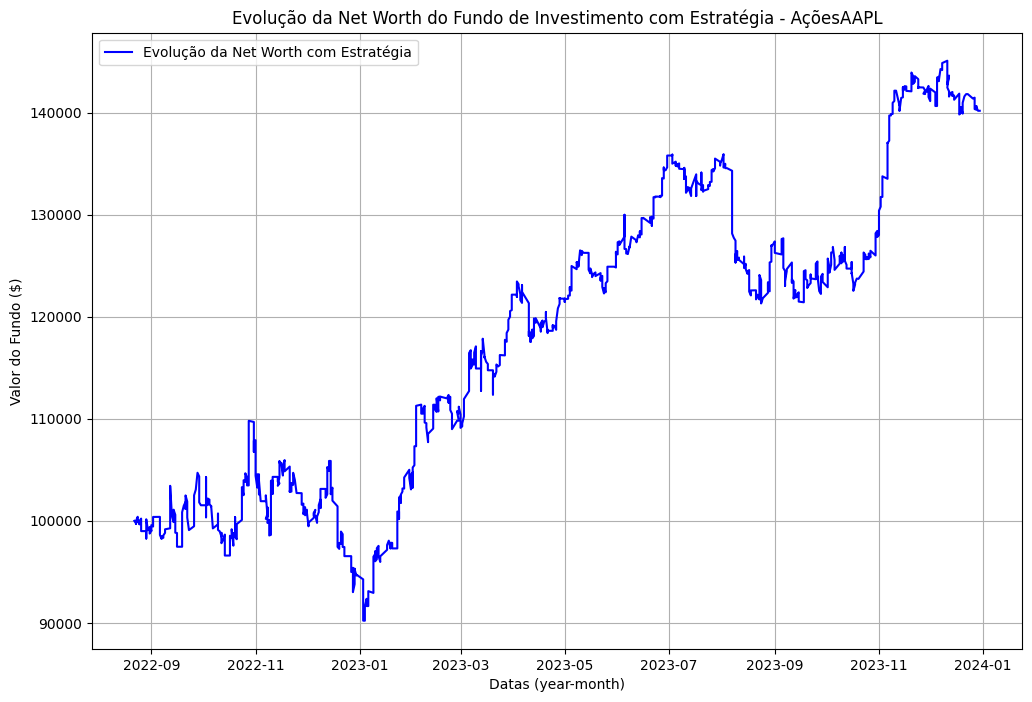

In [64]:
# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    dates_list[-len(networth_strategy) :],
    networth_strategy,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)

plt.title(
    "Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações" + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva e coeficiente para este modelo. Combinado com o plot da estratégia mais basica que acompanha e é igual a olhar para o mercado diretamente - simpler long-holder.

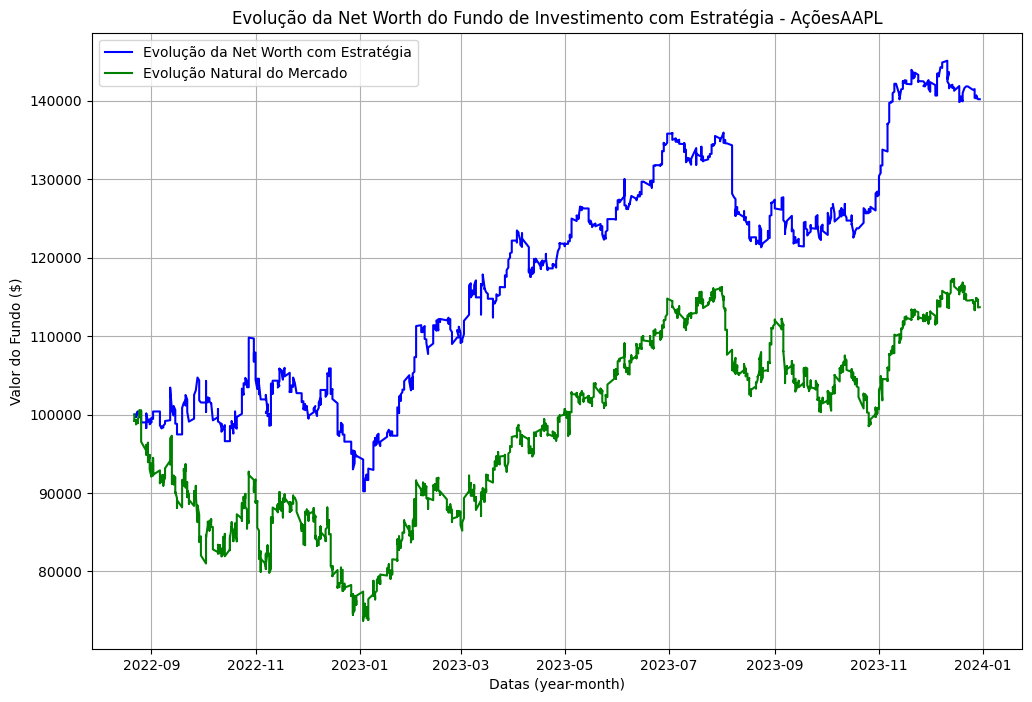

In [65]:
# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    dates_list[-(len(networth_strategy)) :],
    networth_strategy,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)
plt.plot(
    last_subsets_dates,
    natural_fund_values,
    label="Evolução Natural do Mercado",
    color="green",
)

plt.title(
    "Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações" + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Quanto dinheiro a mais se ganhou ao se ter usado este modelo com esta estratégia no final do periodo do dataset de teste?

Dinheiro ganho com esta estratégia - Dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

Melhoria percentual ao se ter usado esta estratégia:

aumento percentual do dinheiro ganho com esta estratégia - aumento percentual do dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

In [66]:
print(
    f"Dinheiro extra ganho ao se ter usado AI: {fund - percentage_increase - final_value:.3f}$"
)

print(
    f"\nMelhoria percentual ao se ter usado AI: {percentage_increase_strategy - percentage_increase:.3f}%"
)

Dinheiro extra ganho ao se ter usado AI: 26487.316$

Melhoria percentual ao se ter usado AI: 26.501%


Diferença percentual = Melhoria Percentual

Plot do gráfico que nos dá a melhoria percentual ao longo de todo o dataset. A combinação valor da sensibilidade decisiva, coeficiente deve de ser dada pela média mais elevada de valores de melhoria percentual ao longo de todo este gráfico em função da sensibilidade decisiva.

Melhoria decisiva = ganho percentual da estratégia com o modelo - ganho percentual de um simple holder

simple holder = natural fund values

Coordenadas do valor máximo absoluto:
Data: 2023-03-13
Diferença Percentual Máxima: 33.95%
Média da Diferença Percentual ao Longo de Todo o Gráfico: 20.42%


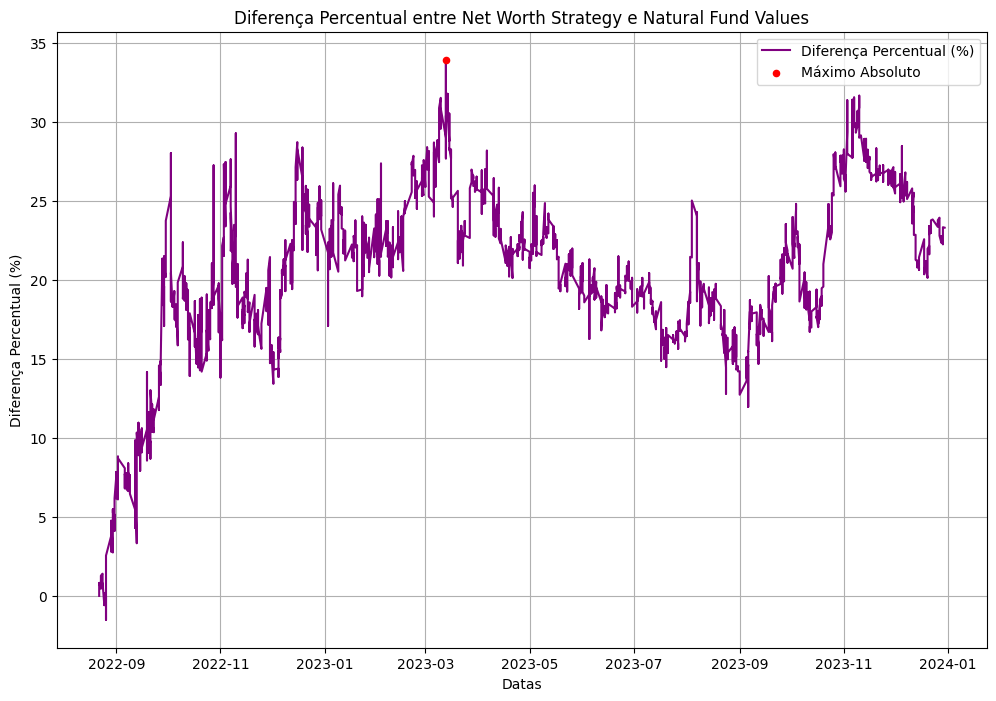

In [67]:
# Calcular a diferença percentual
diff_percentual = (
    (np.array(networth_strategy) - np.array(natural_fund_values))
    / np.array(natural_fund_values)
) * 100

# Encontrar o índice do valor máximo absoluto da diferença percentual
max_index = np.argmax(diff_percentual)

# Coordenadas do valor máximo
max_diff_percentual = diff_percentual[max_index]
max_date = last_subsets_dates[max_index]

print(f"Coordenadas do valor máximo absoluto:")
print(f"Data: {max_date}")
print(f"Diferença Percentual Máxima: {max_diff_percentual:.2f}%")

# Traçar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    diff_percentual,
    label="Diferença Percentual (%)",
    color="purple",
)

# Adicionar o ponto máximo ao gráfico
plt.scatter(
    max_date, max_diff_percentual, color="red", s=20, zorder=5, label="Máximo Absoluto"
)

# Rótulos e título
plt.title("Diferença Percentual entre Net Worth Strategy e Natural Fund Values")
plt.xlabel("Datas")
plt.ylabel("Diferença Percentual (%)")

# Calcular a média da diferença percentual
media_diff_percentual = np.mean(diff_percentual)

# Printar o valor médio
print(
    f"Média da Diferença Percentual ao Longo de Todo o Gráfico: {media_diff_percentual:.2f}%"
)

# Adicionar a legenda e grid
plt.legend()
plt.grid(True)

# Mostrar o gráfico
plt.show()

**Estudo do Retorno em Função do Valor Inicial do Fundo:**

Este plot foi feito apenas por descargo de consciência e investigação se poderiam exitir algum tipo de anomalias no código. Ele investiga o retorno percentual no final do dataset de teste em função do investimento inicial que por default é feito com 100 000$. Como era de esperar o retorno percentual não varia consoante o investimento inicial, pois foi permitido o trade na bolsa de ações percentuais.

Atenção este gráfico apresenta o ganho percentual bruto da AI e não a melhoria percentual.

Coordenadas do ponto máximo absoluto: Dinheiro Inicial = $2626338.89, Percentual de Crescimento = 40.172%


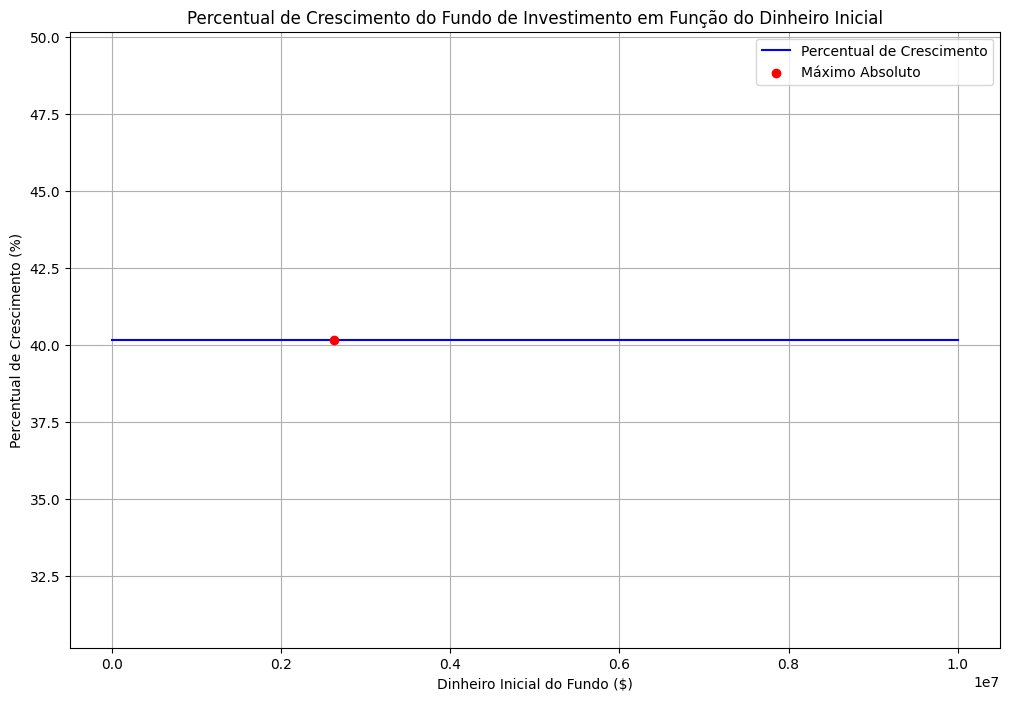

In [68]:
# Defina também os coeficientes para compra e venda (já devem estar definidos no seu contexto)
# Exemplo:
# coeficiente_c = 0.5  # Para determinar o percentual do fundo a investir na compra
# coeficiente_v = 0.5  # Para determinar o percentual das ações a vender

# Definir a faixa de valores para o fundo inicial
initial_fund_values = np.linspace(50, 10000150, 100)  # Valores de $50 a $10,000,000

# Lista para armazenar os resultados (percentual de crescimento para cada fundo inicial)
networth_results = []

# Loop sobre todos os valores de fundo inicial
for initial_fund in initial_fund_values:
    fund = initial_fund
    num_shares = 0.0  # Número de ações atualmente detidas (permitindo frações)
    networth_strategy = []  # Armazenar a evolução do valor líquido (net worth) ao longo do tempo

    # Iterar pelo tensor (exceto o último que não possui previsão)
    for i in range(len(tensor_np) - 1):
        current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
        prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

        # Converter a previsão para float, se possível, ou definir como 0 se for 'none'
        if prediction_str != "none":
            prediction = float(prediction_str)
        else:
            prediction = 0

        # Se a previsão for maior que sensibilidade_decisiva2 e houver fundos, efetua COMPRA
        if prediction > sensibilidade_decisiva2 and fund > 0:
            grau_certeza = abs(prediction)
            percentage_to_spend = (
                coeficiente_c * grau_certeza
            )  # Percentual do fundo a investir
            if percentage_to_spend > 1:
                percentage_to_spend = 1
            amount_to_spend = percentage_to_spend * fund
            num_shares_to_buy = amount_to_spend / current_price
            fund -= num_shares_to_buy * current_price
            num_shares += num_shares_to_buy

        # Se a previsão for menor que sensibilidade_decisiva1 e houver ações, efetua VENDA
        elif prediction < sensibilidade_decisiva1 and num_shares > 0:
            grau_certeza = abs(1 - prediction)
            percentage_to_sell = (
                coeficiente_v * grau_certeza
            )  # Percentual de ações a vender
            if percentage_to_sell > 1:
                percentage_to_sell = 1
            amount_to_sell = percentage_to_sell * num_shares
            fund += amount_to_sell * current_price
            num_shares -= amount_to_sell

        # Se a previsão estiver entre os thresholds, nenhuma operação é executada (posição mantida)

        # Calcular a net worth (fundo + valor das ações) e armazenar
        networth = fund + num_shares * current_price
        networth_strategy.append(networth)

    # No final do tensor, vender quaisquer ações remanescentes (se houver)
    if num_shares > 0:
        final_price = float(tensor_np[-1][0])
        fund += num_shares * final_price
        num_shares = 0
    networth_strategy.append(fund)

    # Calcular o percentual de crescimento da estratégia para este fundo inicial
    percentage_increase_strategy = (
        (networth_strategy[-1] - initial_fund) / initial_fund
    ) * 100
    networth_results.append(percentage_increase_strategy)

# Encontrar o fundo inicial que gerou o maior percentual de crescimento
max_index = np.argmax(networth_results)
max_initial_fund = initial_fund_values[max_index]
max_percentage_increase = networth_results[max_index]

print(
    f"Coordenadas do ponto máximo absoluto: Dinheiro Inicial = ${max_initial_fund:.2f}, Percentual de Crescimento = {max_percentage_increase:.3f}%"
)

# Plotar o gráfico
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.plot(
    initial_fund_values,
    networth_results,
    label="Percentual de Crescimento",
    color="blue",
)
plt.scatter(
    max_initial_fund,
    max_percentage_increase,
    color="red",
    zorder=5,
    label="Máximo Absoluto",
)  # Destacar o ponto máximo

# Ajustar os limites do eixo Y
plt.ylim(min(networth_results) - 10, max(networth_results) + 10)

plt.title(
    "Percentual de Crescimento do Fundo de Investimento em Função do Dinheiro Inicial"
)
plt.xlabel("Dinheiro Inicial do Fundo ($)")
plt.ylabel("Percentual de Crescimento (%)")
plt.grid(True)
plt.legend()
plt.show()

# **Results Sem Short-Selling**

Aqui podes comprar todas as estratégias testadas anteriormente sem short selling lado a lado para teres uma melhor visão comprativa de qual funciona melhor.

In [69]:
def print_header(title):
    """Prints a header with an underline."""
    print(title)
    print("-" * len(title))


def print_section(title):
    """Prints a section header followed by a blank line."""
    print_header(title)
    print()


def print_formatted_result(prefix, values, formats):
    """
    Given a prefix and a list of (label, value) pairs with associated formats,
    prints the values in a formatted string.
    """
    formatted_parts = [
        f"{label}={fmt.format(value)}" for (label, value), fmt in zip(values, formats)
    ]
    print(f"  {prefix}: " + "; ".join(formatted_parts))

In [70]:
# Main Market Growth Information
print(
    f"Crescimento Natural do Mercado Entre {last_subsets_dates[0]} e {last_subsets_dates[-1]} para ações {symbol}:"
)
print(f"{percentage_increase:.5f}%\n")

print_section("Sem Short-Selling:")

# Optimization based on Mean Percentage Difference
print_section("Resultados ao Otimizar em Função da Média da Diferença Percentual")

print("Absolute Buy and Sell:")
print(
    f"  Sensibilidade Decisiva 1 = {Results_Mean_array[0][0]:.2f}; "
    f"Sensibilidade Decisiva 2 = {Results_Mean_array[0][1]:.2f}; "
    f"Média da Diferença Percentual = {Results_Mean_array[0][2]:.5f}\n"
)

print("Independent Parcial Buy and Sell in Function of Predictions Probabilaty:")
print(
    f"  Sensibilidade Decisiva 1 = {Results_Mean_array[1][0]:.2f}; "
    f"Sensibilidade Decisiva 2 = {Results_Mean_array[1][1]:.2f}; "
    f"Coeficiente de Compra = {Results_Mean_array[1][2]:.2f}; "
    f"Coeficiente de Venda = {Results_Mean_array[1][3]:.2f}; "
    f"Média da Diferença Percentual = {Results_Mean_array[1][4]:.5f}\n"
)

# Optimization based on Last Date Percentage Difference
print_section("Resultados ao Otimizar em Função da Diferença Percentual da Última Data")

print("Absolute Buy and Sell:")
print(
    f"  Sensibilidade Decisiva 1 = {Results_Last_array[0][0]:.2f}; "
    f"Sensibilidade Decisiva 2 = {Results_Last_array[0][1]:.2f}; "
    f"Ganho Percentual da Estratégia = {(Results_Mean_array[1][4] + percentage_increase):.5f}; "
    f"Diferença Percentual = {Results_Last_array[0][2]:.5f}\n"
)

print("Independent Parcial Buy and Sell in Function of Predictions Probabilaty:")
print(
    f"  Sensibilidade Decisiva 1 = {Results_Last_array[1][0]:.2f}; "
    f"Sensibilidade Decisiva 2 = {Results_Last_array[1][1]:.2f}; "
    f"Coeficiente de Compra = {Results_Last_array[1][2]:.2f}; "
    f"Coeficiente de Venda = {Results_Last_array[1][3]:.2f}; "
    f"Ganho Percentual da Estratégia = {(Results_Mean_array[1][4] + percentage_increase):.5f}; "
    f"Diferença Percentual = {Results_Last_array[1][4]:.5f}"
)

Crescimento Natural do Mercado Entre 2022-08-22 e 2023-12-30 para ações AAPL:
13.67132%

Sem Short-Selling:
------------------

Resultados ao Otimizar em Função da Média da Diferença Percentual
-----------------------------------------------------------------

Absolute Buy and Sell:
  Sensibilidade Decisiva 1 = 0.30; Sensibilidade Decisiva 2 = 0.80; Média da Diferença Percentual = 20.42086

Independent Parcial Buy and Sell in Function of Predictions Probabilaty:
  Sensibilidade Decisiva 1 = 0.30; Sensibilidade Decisiva 2 = 0.80; Coeficiente de Compra = 5.00; Coeficiente de Venda = 5.00; Média da Diferença Percentual = 20.42086

Resultados ao Otimizar em Função da Diferença Percentual da Última Data
-----------------------------------------------------------------------

Absolute Buy and Sell:
  Sensibilidade Decisiva 1 = 0.30; Sensibilidade Decisiva 2 = 0.80; Ganho Percentual da Estratégia = 34.09218; Diferença Percentual = 26.50099

Independent Parcial Buy and Sell in Function of Pred

# **Estratégias de Gestão do Portefólio de Investimentos Com Short-Selling**

Aqui seram estudadas todas as possíveis estratégias de gestão de portefólio com o modelo usando short-selling. Para estudar as seguintes estratégias será criado um portefólio virtual com 100 000$ que será gerido usando o modelo para prever o mercado e a respetiva estratégia de gestão de portefólio que estará a ser estudada. Isto permite simular o mais aproximado ppossível a gestão real de um portefólio com o modelo desenvolvido no alpaca e a estratégia escolhida e desenvolvida pelo SunTzu.

É imporante destacar que a networth de um portefólio é dado pela seguinte função:

Networth(localização temporal; modelo; estratégia; ativo; valor inicial = 100 000$$) = Valor_do_ativo_comprado(localização temporal atual; ativo; quantidade do ativo) + Valor_Liquido_Guardado(localização temporal atual; modelo; estratégia; valor inicial = 100 000$) + Posição_short_selling(localização temporal da realização do short-selling; ativo; quantidade do ativo) - Ativo_short_selled(localização temporal atual; ativo; quantidade do ativo)

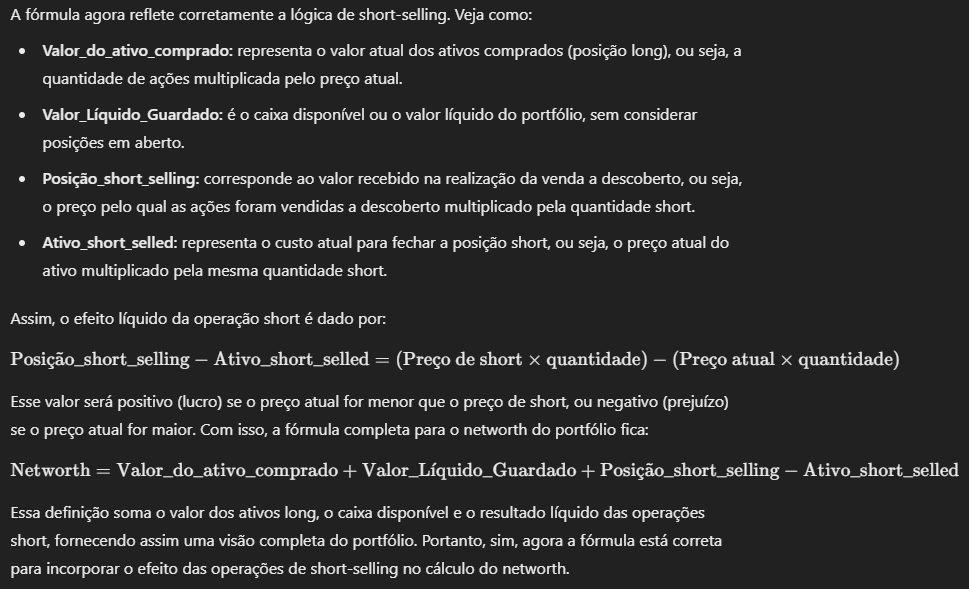

Temos de fazer alguns ajustes á estratégia de trading:

1. O número máximo de ações ás quais dás short-selling em valor numerário tem de corresponder ao valor de dinheiro liquido do portifólio.

2. Para calcular a networth do portfólio o valor de uma operação short-selling apenas deve contar para a networth após o short-selling ser coberto, até lá o dinheiro adquirido com a posição short-selled não deve entrar para o calculo da networth do portefólio.

Pela teoria dos grandes números basta o modelo ter uma precisão superior a 50% para que em média quanto mais tempo deixaremos a correr o modelo, ou seja, quantas mais iterasões (previsões) o modelo fizer sobre a bolsa com a estratégia correta mais os retornos da AI se vão distanciar de um simple holder, mais o modelo vai dar outeperform ao mercado. Portanto em teoria quanto mais tempo o modelo correr melhores seram os resultados.

Sensibilidade Decisiva trata-se do valor decimal que estipula a fronteira numerica entre o modelo dizer que uma probabilidade prevista corresponde à label 1 ou 0. A sensibilidade decisiva por default assume-se como 0.5. No entanto, a ideia é investigar exatamente qual é a mais correta consoante o modelo e consoate a estratégia de gestão de portefólio.

Iniciar os arrays de resultados para guardar os resultados das estretégias estudadas.

In [71]:
Results_Last_cS_array = []
Results_Mean_cS_array = []

### **Absolute Buy and Sell com Short-Selling**

Comprar em absoluto, ou seja, gastar todo o dinheiro da carteira ao primeiro sinal positivo "1". Buy and Hold, ou seja, manter todo o dinheiro nas ações uma vez executada a compra, até o sinal positivo "1" se alterar. Vender em absoluto, ou seja, vender todo o dinheiro das ações ao primeiro sinal negativo "0" e aplicar um posição short-selling, manter a posição short-selling até o sinal negativo "0" se alterar. Repetir infinitamente o processo.



**Estudo da Melhor Sensibilidade Decisiva:**

Sensibilidade Decisiva trata-se do valor decimal que estibula a fronteira numerica entre o modelo dizer que uma probabilidade prevista corresponde à label 1 ou 0. A sensibilidade decisiva por default assume-se como 0.5. No entanto, a ideia é investigar exatamente qual é a mais correta consoante o modelo e consoate a estratégia de gestão de portefólio.

A seguir, apresento o código atualizado com a nova lógica para calcular a média da diferença percentual ao longo do tempo, incorporando o short-selling conforme as seguintes regras:

Ao abrir uma posição short, a quantidade vendida é determinada com base no dinheiro líquido disponível (isto é,
  num_shares_to_short = fund_strategy / current_price), mas os proceeds da venda não são creditados ao fundo (ficam bloqueados como garantia).

Enquanto a posição short estiver aberta, o short não afeta a networth (que é calculada como o valor do fundo mais os ativos long, isto é,
  networth = fund_strategy + num_shares_strategy * current_price).

Quando a posição short é coberta (por uma previsão forte positiva), o lucro ou prejuízo da operação short é realizado (calculado como
  num_shares_short_strategy * (short_sale_price_strategy - current_price)) e somado ao fundo.

O código abaixo utiliza essas regras para calcular, em cada iteração do tensor, a evolução da networth da estratégia e, ao final, a média da diferença percentual em relação à estratégia natural (representada por natural_fund_values):

Explicação dos pontos principais:
Operação Long:
Se a previsão for alta (acima do threshold) e houver caixa disponível, antes de comprar ações o código verifica se há um short aberto. Se houver, a posição short é coberta – realizando o lucro ou prejuízo (que é então adicionado ao fundo) – e somente depois a compra long é executada.

Operação Short:
Se a previsão for fortemente negativa (abaixo de
−
−threshold), se houver uma posição long, ela é vendida para liberar caixa. Em seguida, se não houver short aberto, o short é iniciado. A quantidade vendida é definida por num_shares_to_short = fund_strategy / current_price e os proceeds não são creditados ao fundo (o dinheiro permanece bloqueado como garantia).

Cálculo da Networth:
Enquanto uma posição short estiver aberta, o valor da operação short não entra na networth (ela é calculada apenas como fund_strategy + num_shares_strategy * current_price). Só ao fechar o short o efeito (lucro ou prejuízo) é realizado e incorporado ao fundo.

Cálculo da Diferença Percentual:
Para cada valor de sensibilidade, é calculada a média da diferença percentual entre a evolução da networth da estratégia AI e a estratégia natural (valores em natural_fund_values).

In [72]:
percentages_diference_array = []
media_diff_percentual_array = []  # Armazenar as médias das diferenças

sd1_list = []
sd2_list = []

# Loop sobre todas as combinações válidas: garantimos que sd1 < sd2
for sd1 in sensibilidade_decisiva1_array:
    for sd2 in sensibilidade_decisiva2_array:
        # Inicializar variáveis para esta combinação de thresholds
        initial_fund = 100000  # Fundo inicial de $100,000
        fund = initial_fund
        num_shares = 0.0  # Posição long (ações compradas)
        num_shares_short = 0.0  # Posição short (ações vendidas a descoberto)
        short_sale_price = 0.0  # Preço de abertura da operação short
        networth_strategy = []  # Evolução da networth ao longo do tempo

        # Iterar pelo tensor (exceto o último que não tem previsão)
        for i in range(len(tensor_np) - 1):
            current_price = float(tensor_np[i + 1][0])
            prediction_str = tensor_np[i][1]

            if prediction_str != "none":
                prediction = float(prediction_str)
            else:
                # Se não houver previsão, pular o período (ou alternativamente repetir o último valor)
                continue

            # Operação de COMPRA (posição long) se a previsão for alta: > sensibilidade_decisiva2
            if prediction > sd2 and fund > 0:
                # Se houver posição short aberta, cobrir primeiro
                if num_shares_short > 0:
                    profit = num_shares_short * (short_sale_price - current_price)
                    fund += profit
                    num_shares_short = 0.0
                    short_sale_price = 0.0
                # Comprar ações com o fundo disponível
                if fund > 0:
                    grau_certeza = abs(prediction)
                    percentage_to_spend = coeficiente_c * grau_certeza
                    if percentage_to_spend > 1:
                        percentage_to_spend = 1
                    amount_to_invest = percentage_to_spend * fund
                    num_shares_to_buy = amount_to_invest / current_price
                    fund -= num_shares_to_buy * current_price
                    num_shares += num_shares_to_buy

            # Operação de VENDA/SHORT se a previsão for baixa: < sensibilidade_decisiva1
            elif prediction < sd1:
                # Se houver posição long, vende para liberar caixa
                if num_shares > 0:
                    proceeds = num_shares * current_price
                    fund += proceeds
                    num_shares = 0.0
                # Iniciar operação short se houver caixa e nenhuma posição short ainda aberta
                if fund > 0 and num_shares_short == 0:
                    num_shares_to_short = fund / current_price
                    # Não creditamos o valor, pois o fundo permanece bloqueado como garantia
                    num_shares_short = num_shares_to_short
                    short_sale_price = current_price
            else:
                # Zona neutra: nenhuma operação
                pass

            # Calcular a networth do período (considerando somente o fundo e as ações long)
            current_networth = fund + num_shares * current_price
            networth_strategy.append(current_networth)

        # Ao final do tensor, fechar quaisquer posições abertas
        final_price = float(tensor_np[-1][0])
        # Fechar posição long, se houver
        if num_shares > 0:
            proceeds = num_shares * final_price
            fund += proceeds
            num_shares = 0.0
        # Fechar posição short, se houver (calculando lucro/prejuízo)
        if num_shares_short > 0:
            profit = num_shares_short * (short_sale_price - final_price)
            fund += profit
            num_shares_short = 0.0
            short_sale_price = 0.0

        # Cálculo final da networth (todas as posições fechadas)
        networth = fund
        percentage_increase_strategy = ((networth - initial_fund) / initial_fund) * 100

        # Registrar a diferença percentual em relação à estratégia natural
        percentages_diference_array.append(
            percentage_increase_strategy - percentage_increase
        )
        networth_strategy.append(fund)

        # Calcular a diferença percentual entre a estratégia AI e a estratégia natural
        diff_percentual = (
            (np.array(networth_strategy) - np.array(natural_fund_values))
            / np.array(natural_fund_values)
        ) * 100
        media_diff_percentual = np.mean(diff_percentual)
        media_diff_percentual_array.append(media_diff_percentual)

        sd1_list.append(sd1)
        sd2_list.append(sd2)

Assim este código permite plotar e analisar os retornos financeiros da estratégia implementada em função do valor da sensibilidade decisiva. O portefólio que ao começar com 100 000$ tiver os maiores retornos financeiros com a sensibilidade decisiva utilizada sinalarizará a melhor sensibilidade decisiva para a estratégia de gestão de portefólio e para o modelo.

É imporante destacar que o gráfico apresentado e os valores tidos em conta para escolher a sensibilidade decisiva pelo facto de estaremos à procura de uma estratégia que "derrote" o mercado o valor de retorno ao se estudar a estratégia é originado pela seguinte formula:

retorno percetual do investimento inicial da estratégia em estudo com a sensibilidade decisiva em vigor - retorno percentual do investimento inicial para um simples buy em holder = melhoria percentual

a melhoria percentual mais elevada corresponde á melhor sensibilidade decisiva.

Top 1 ponto: Sensibilidade Decisiva 1 (Venda) = 0.30, Sensibilidade Decisiva 2 (Compra) = 0.80, Melhoria Percentual = 49.73%
Top 2 ponto: Sensibilidade Decisiva 1 (Venda) = 0.80, Sensibilidade Decisiva 2 (Compra) = 0.80, Melhoria Percentual = 44.59%
Top 3 ponto: Sensibilidade Decisiva 1 (Venda) = 0.30, Sensibilidade Decisiva 2 (Compra) = 0.90, Melhoria Percentual = 40.73%


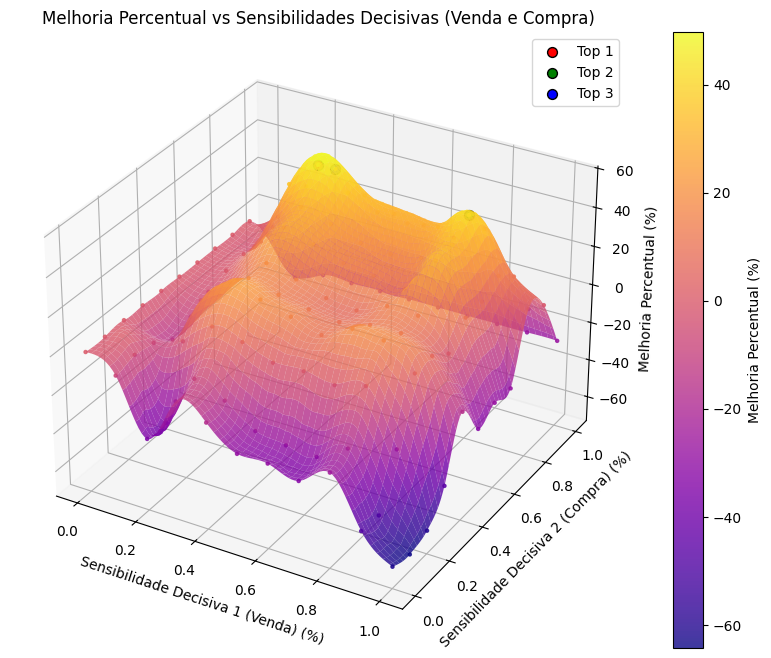

In [73]:
# Converter as listas para arrays NumPy
sd1_vals = np.array(sd1_list)  # Sensibilidade Decisiva 1 (Venda)
sd2_vals = np.array(sd2_list)  # Sensibilidade Decisiva 2 (Compra)
perc_diff = np.array(
    percentages_diference_array
)  # Melhoria Percentual para cada combinação

# Identificar os 3 melhores pontos com base na Melhoria Percentual
top3_indices = np.argsort(perc_diff)[-3:][
    ::-1
]  # índices dos 3 maiores valores (ordem decrescente)

# Cores para destacar os 3 melhores pontos
colors = ["red", "green", "blue"]

# Imprimir as coordenadas dos 3 melhores pontos e adicioná-las ao array de resultados
for rank, idx in enumerate(top3_indices, start=1):
    sd1_top = sd1_vals[idx]
    sd2_top = sd2_vals[idx]
    perc_top = perc_diff[idx]
    print(
        f"Top {rank} ponto: Sensibilidade Decisiva 1 (Venda) = {sd1_top:.2f}, Sensibilidade Decisiva 2 (Compra) = {sd2_top:.2f}, Melhoria Percentual = {perc_top:.2f}%"
    )

# Criar uma grade regular para a interpolação
xi = np.linspace(sd1_vals.min(), sd1_vals.max(), 100)
yi = np.linspace(sd2_vals.min(), sd2_vals.max(), 100)
xi, yi = np.meshgrid(xi, yi)

# Interpolar os valores de perc_diff para a grade criada (usando método 'cubic' para suavidade)
zi = griddata((sd1_vals, sd2_vals), perc_diff, (xi, yi), method="cubic")

# Criar o gráfico 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Plotar a superfície interpolada
surf = ax.plot_surface(xi, yi, zi, cmap="plasma", alpha=0.8, edgecolor="none")

# Plotar os pontos originais
sc = ax.scatter(
    sd1_vals, sd2_vals, perc_diff, c=perc_diff, cmap="plasma", s=5, alpha=0.8
)

# Destacar os 3 melhores pontos
for rank, idx in enumerate(top3_indices, start=1):
    ax.scatter(
        sd1_vals[idx],
        sd2_vals[idx],
        perc_diff[idx],
        color=colors[rank - 1],
        s=50,
        edgecolors="black",
        label=f"Top {rank}",
    )
    if rank == 1:
        Results_Last_cS_array.append([sd1_vals[idx], sd2_vals[idx], perc_diff[idx]])

# Configurar títulos e rótulos dos eixos
ax.set_title("Melhoria Percentual vs Sensibilidades Decisivas (Venda e Compra)")
ax.set_xlabel("Sensibilidade Decisiva 1 (Venda) (%)")
ax.set_ylabel("Sensibilidade Decisiva 2 (Compra) (%)")
ax.set_zlabel("Melhoria Percentual (%)")

# Barra de cores
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Melhoria Percentual (%)")

ax.legend()

plt.show()

Mais tarde precebeu-se que pode ser enganador apenas analisar o retorno no final do periodo temporal do dataset de teste. Para contornar esta questão foi desenvolvida outra metodologia.

Será capturado o retorno financeiro percentual em termos de networth do portefólio comparativamente com o valor inicial dado de 100 000$. Esse retorno financeiro a cada trade executada, ou melhor a cada matriz temporal analisada e prevista pelo o modelo será subtraindo o valor da networth de um portefólio que segue naturalmente o mercado (simple holder), para obter a "melhoria percentual". Mas desta ves estará se a obter a melhoria percentual a cada previsão do modelo. Ao se fazer a média da melhoria percentual ao longo de todas as previsões do modelo, ou seja, ao longo de todo o dataset de teste é possível preceber qual é a sensibilidade decisiva que maximiza o valor da "média da melhoria percentual". Desta forma é possível concluir qual é a melhor sensibilidade decisiva parqa este modelo e para esta estratégia anulando o impacto de estaremos a olhar para os retornos apenas de um evento temporal como o final do dataset de teste, mas sim tendo em conta a performance do modelo e da estrátegia ao longo de todo o dataset de teste.

Top 1 ponto: Sensibilidade Decisiva 1 (Venda) = 0.30, Sensibilidade Decisiva 2 (Compra) = 0.80, Média Diferença Percentual = 39.88%
Top 2 ponto: Sensibilidade Decisiva 1 (Venda) = 0.80, Sensibilidade Decisiva 2 (Compra) = 0.80, Média Diferença Percentual = 35.80%
Top 3 ponto: Sensibilidade Decisiva 1 (Venda) = 0.30, Sensibilidade Decisiva 2 (Compra) = 0.90, Média Diferença Percentual = 33.63%


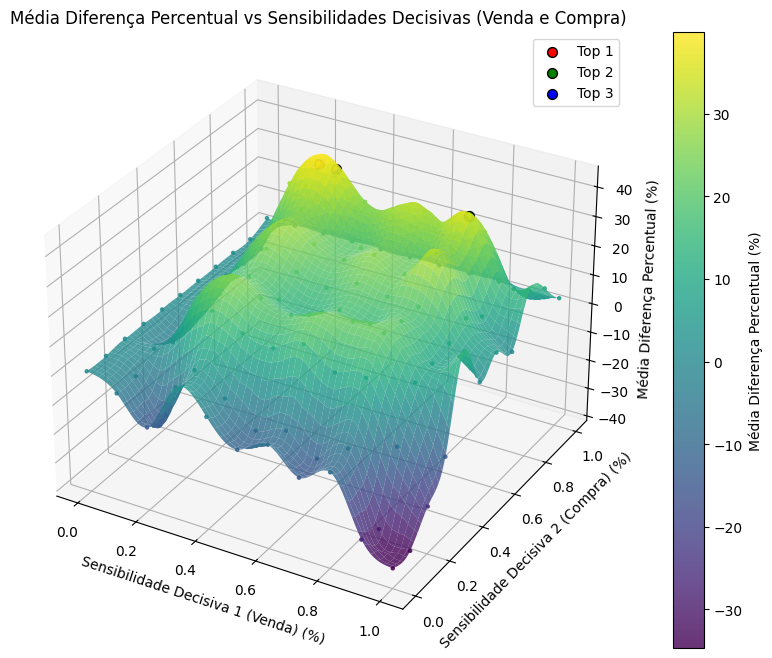

In [74]:
# Converter as listas para arrays NumPy
sd1_vals = np.array(sd1_list)  # Sensibilidade Decisiva 1 (Venda)
sd2_vals = np.array(sd2_list)  # Sensibilidade Decisiva 2 (Compra)
media_diff_vals = np.array(
    media_diff_percentual_array
)  # Média Diferença Percentual para cada combinação

# Identificar os 3 melhores pontos com base na variável do eixo Z
top3_indices = np.argsort(media_diff_vals)[-3:][
    ::-1
]  # Índices dos 3 maiores valores (ordem decrescente)

# Cores para destacar os 3 melhores pontos
colors = ["red", "green", "blue"]

# Imprimir os 3 melhores pontos e adicioná-los ao array de resultados
for rank, idx in enumerate(top3_indices, start=1):
    sd1_best = sd1_vals[idx]
    sd2_best = sd2_vals[idx]
    media_diff_best = media_diff_vals[idx]
    print(
        f"Top {rank} ponto: Sensibilidade Decisiva 1 (Venda) = {sd1_best:.2f}, Sensibilidade Decisiva 2 (Compra) = {sd2_best:.2f}, Média Diferença Percentual = {media_diff_best:.2f}%"
    )

# Criar uma grade regular para a interpolação
xi = np.linspace(sd1_vals.min(), sd1_vals.max(), 100)
yi = np.linspace(sd2_vals.min(), sd2_vals.max(), 100)
xi, yi = np.meshgrid(xi, yi)

# Interpolar os valores de media_diff_vals para a grade criada (usando método 'cubic' para suavidade)
zi = griddata((sd1_vals, sd2_vals), media_diff_vals, (xi, yi), method="cubic")

# Criar o gráfico 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Plotar a superfície interpolada
surf = ax.plot_surface(xi, yi, zi, cmap="viridis", alpha=0.8, edgecolor="none")

# Plotar os pontos originais para referência
sc = ax.scatter(
    sd1_vals,
    sd2_vals,
    media_diff_vals,
    c=media_diff_vals,
    cmap="viridis",
    s=5,
    alpha=0.8,
)

# Destacar os 3 melhores pontos
for rank, idx in enumerate(top3_indices, start=1):
    ax.scatter(
        sd1_vals[idx],
        sd2_vals[idx],
        media_diff_vals[idx],
        color=colors[rank - 1],
        s=50,
        edgecolors="black",
        label=f"Top {rank}",
    )
    if rank == 1:
        Results_Mean_cS_array.append(
            [sd1_vals[idx], sd2_vals[idx], media_diff_vals[idx]]
        )

# Configurar os rótulos e título
ax.set_title("Média Diferença Percentual vs Sensibilidades Decisivas (Venda e Compra)")
ax.set_xlabel("Sensibilidade Decisiva 1 (Venda) (%)")
ax.set_ylabel("Sensibilidade Decisiva 2 (Compra) (%)")
ax.set_zlabel("Média Diferença Percentual (%)")

# Barra de cor
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Média Diferença Percentual (%)")

ax.legend()

plt.show()

**Analisando o melhor caso dado pela melhor média de diferança entre o mercado e a estratégia:**

Nesta parte do algoritmo dedicamo-nos a analisar detalhadamente o que é que acontece para um valor em especifico de sensibilidade decisiva.

Geralmente a ideia é analisar detalhadamente o que é que acontec com o valor considerado ideal encotrado anteriormente.

Escolhe-se o valor da sensibilidade decisiva que se quer estudar.

In [75]:
sensibilidade_decisiva = round(Results_Mean_cS_array[0][0], int(-math.log10(Step_SD)))
print(f"Sensibilidade Decisiva 1: {sensibilidade_decisiva}")
sensibilidade_decisiva2 = round(Results_Mean_cS_array[0][1], int(-math.log10(Step_SD)))
print(f"Sensibilidade Decisiva 2: {sensibilidade_decisiva2}")

Sensibilidade Decisiva 1: 0.3
Sensibilidade Decisiva 2: 0.8


Todas as trasações executadas para a estratégia com esta sensibilidade decisiva. Assim como um acaompanhamento do balanço ações/dinheiro do portefólio.

In [76]:
# Inicializar variáveis
initial_fund = 100000  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0  # Posição long (ações compradas)
num_shares_short = 0.0  # Posição short (ações vendidas a descoberto)
short_sale_price = 0.0  # Preço de abertura da operação short
total_ops = 0.0  # Valor total das operações realizadas
networth_strategy_array = []

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_np) - 1):
    current_price = float(tensor_np[i + 1][0])  # Preço da ação para a operação
    prediction_raw = tensor_np[i][1]  # Previsão atual

    if prediction_raw != "none":
        prediction = float(prediction_raw)
    else:
        prediction = 0.0

    # Determinar sinal para debug:
    if prediction > sensibilidade_decisiva2:
        signal = 1
    elif prediction < sensibilidade_decisiva1:
        signal = -1
    else:
        signal = 0

    # Operação LONG: se previsão > sensibilidade_decisiva2 e houver fundos disponíveis
    if prediction > sensibilidade_decisiva2 and fund > 0:
        # Se houver posição short aberta, cobrir primeiro
        if num_shares_short > 0:
            profit = num_shares_short * (short_sale_price - current_price)
            fund += profit
            total_ops += (
                num_shares_short * current_price
            )  # valor da operação de cobertura
            print(
                f"[Período {i}] COBERTURA SHORT: Fechado {num_shares_short:.6f} ações short a {current_price:.2f} por ${num_shares_short * current_price:.2f}. Lucro/Prejuízo: ${profit:.2f}. Novo fundo: ${fund:.2f}."
            )
            num_shares_short = 0.0
            short_sale_price = 0.0

        # Comprar ações (posição long)
        if fund > 0:
            grau_certeza = abs(prediction)
            percentage_to_spend = coeficiente_c * grau_certeza
            if percentage_to_spend > 1:
                percentage_to_spend = 1
            amount_to_invest = percentage_to_spend * fund
            num_shares_to_buy = amount_to_invest / current_price
            cost = num_shares_to_buy * current_price
            fund -= cost
            total_ops += cost
            num_shares += num_shares_to_buy
            print(
                f"[Período {i}] COMPRA LONG: Comprado {num_shares_to_buy:.6f} ações a {current_price:.2f} por ${cost:.2f}. Liquidez: ${fund:.2f}."
            )

    # Operação VENDA/SHORT: se previsão < sensibilidade_decisiva1
    elif prediction < sensibilidade_decisiva1:
        # Se houver posição long, vender para liberar caixa
        if num_shares > 0:
            proceeds = num_shares * current_price
            fund += proceeds
            total_ops += proceeds
            print(
                f"[Período {i}] VENDA LONG: Vendido {num_shares:.6f} ações a {current_price:.2f} por ${proceeds:.2f}. Liquidez: ${fund:.2f}."
            )
            num_shares = 0.0
        # Se não houver posição long e nem short aberta, iniciar operação short
        if num_shares == 0 and num_shares_short == 0 and fund > 0:
            num_shares_to_short = fund / current_price
            total_ops += num_shares_to_short * current_price
            num_shares_short = num_shares_to_short
            short_sale_price = current_price
            print(
                f"[Período {i}] ABERTURA SHORT: Vendido a descoberto {num_shares_to_short:.6f} ações a {current_price:.2f} por ${num_shares_to_short * current_price:.2f}. (Fundo permanece: ${fund:.2f})."
            )
    else:
        # Zona neutra: nenhuma operação
        print(
            f"[Período {i}] SEM OPERAÇÃO: Previsão {prediction:.5f} está na zona neutra. Liquidez: ${fund:.2f}."
        )

    # Cálculo da networth do portfólio (contando somente o fundo e posições long)
    current_networth = fund + num_shares * current_price
    print(
        f"[Período {i}] Networth: ${current_networth:.2f} | Preço: {current_price:.2f} | Prediction: {prediction:.5f} | Sinal: {signal}"
    )
    networth_strategy_array.append(current_networth)

# Ao final do tensor, fechar quaisquer posições abertas:
final_price = float(tensor_np[-1][0])

# Fechar posição long, se houver
if num_shares > 0:
    proceeds = num_shares * final_price
    fund += proceeds
    total_ops += proceeds
    print(
        f"[Final] FECHAMENTO LONG: Vendido {num_shares:.6f} ações a {final_price:.2f} por ${proceeds:.2f}."
    )
    num_shares = 0.0

# Fechar posição short, se houver (realizando lucro ou prejuízo do short)
if num_shares_short > 0:
    profit = num_shares_short * (short_sale_price - final_price)
    fund += profit
    total_ops += num_shares_short * final_price  # valor da operação de cobertura
    print(
        f"[Final] FECHAMENTO SHORT: Fechado {num_shares_short:.6f} ações short a {final_price:.2f} por ${num_shares_short * final_price:.2f}. Lucro/Prejuízo: ${profit:.2f}."
    )
    num_shares_short = 0.0
    short_sale_price = 0.0

print(f"\nBalanço final do fundo de investimento: ${fund:.2f}")
networth_strategy_array.append(fund)
percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
print(
    f"Percentual de crescimento do fundo com a estratégia: {percentage_increase_strategy:.3f}%"
)
print(f"Valor Total das Operações Realizadas: ${total_ops:.2f}")

[Período 0] ABERTURA SHORT: Vendido a descoberto 591.575958 ações a 169.04 por $100000.00. (Fundo permanece: $100000.00).
[Período 0] Networth: $100000.00 | Preço: 169.04 | Prediction: 0.10404 | Sinal: -1
[Período 1] Networth: $100000.00 | Preço: 169.01 | Prediction: 0.14351 | Sinal: -1
[Período 2] Networth: $100000.00 | Preço: 167.66 | Prediction: 0.13901 | Sinal: -1
[Período 3] SEM OPERAÇÃO: Previsão 0.33015 está na zona neutra. Liquidez: $100000.00.
[Período 3] Networth: $100000.00 | Preço: 167.70 | Prediction: 0.33015 | Sinal: 0
[Período 4] COBERTURA SHORT: Fechado 591.575958 ações short a 167.87 por $99307.86. Lucro/Prejuízo: $692.14. Novo fundo: $100692.14.
[Período 4] COMPRA LONG: Comprado 599.822147 ações a 167.87 por $100692.14. Liquidez: $0.00.
[Período 4] Networth: $100692.14 | Preço: 167.87 | Prediction: 0.99795 | Sinal: 1
[Período 5] SEM OPERAÇÃO: Previsão 0.99421 está na zona neutra. Liquidez: $0.00.
[Período 5] Networth: $100452.22 | Preço: 167.47 | Prediction: 0.99421 |

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva para este modelo.

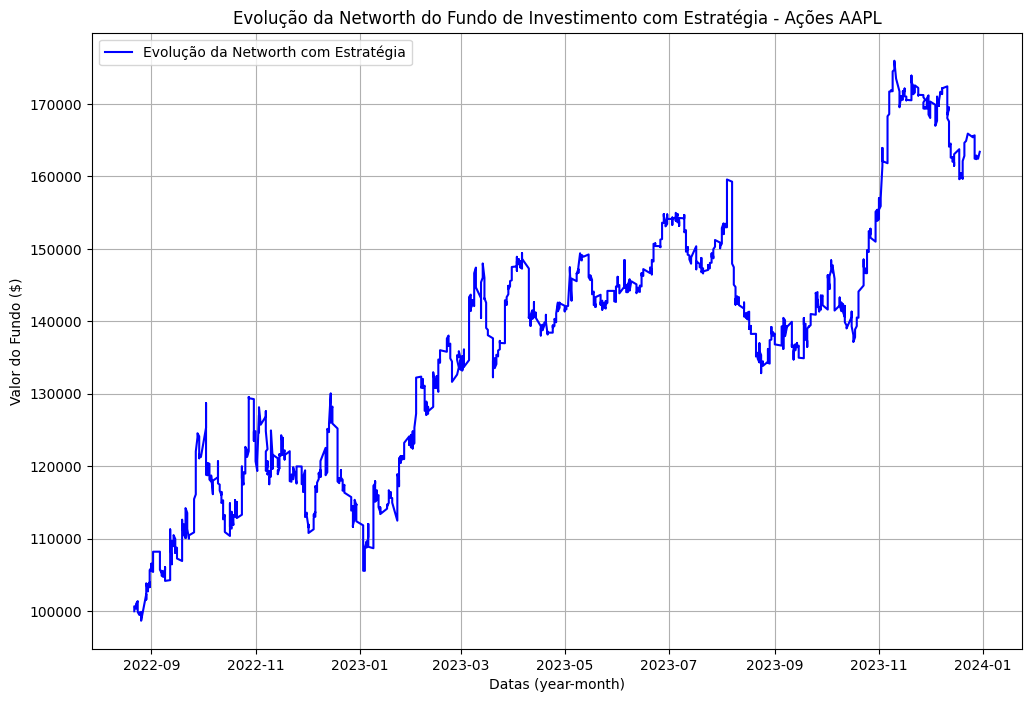

In [77]:
# Gerar o gráfico da evolução da networth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    networth_strategy_array,
    label="Evolução da Networth com Estratégia",
    color="blue",
)
plt.title(
    "Evolução da Networth do Fundo de Investimento com Estratégia - Ações " + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva para este modelo. Combinado com o plot da estratégia mais basica que acompanha e é igual a olhar para o mercado diretamente - simpler long-holder.

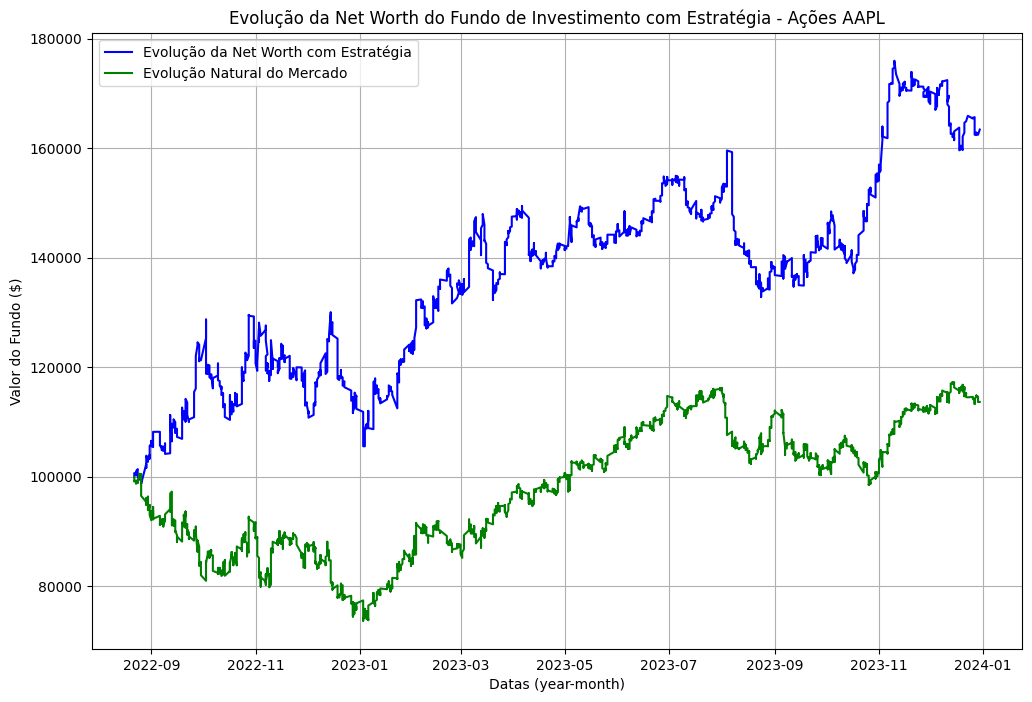

In [78]:
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    networth_strategy_array,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)
plt.plot(
    last_subsets_dates,
    natural_fund_values,
    label="Evolução Natural do Mercado",
    color="green",
)

plt.title(
    "Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações " + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Quanto dinheiro a mais se ganhou ao se ter usado este modelo com esta estratégia no final do periodo do dataset de teste?

Dinheiro ganho com esta estratégia - Dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

Melhoria percentual ao se ter usado esta estratégia:

aumento percentual do dinheiro ganho com esta estratégia - aumento percentual do dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

In [79]:
print(
    f"Dinheiro extra ganho ao se ter usado AI: {fund - percentage_increase - final_value:.3f}$"
)

print(
    f"\nMelhoria percentual ao se ter usado AI: {percentage_increase_strategy - percentage_increase:.3f}%"
)

Dinheiro extra ganho ao se ter usado AI: 49714.997$

Melhoria percentual ao se ter usado AI: 49.729%


Diferença percentual = Melhoria Percentual

Plot do gráfico que nos dá a melhoria percentual ao longo de todo o dataset. O valor da sensibilidade decisiva deve de ser dada pela média mais elevada de valores de melhoria percentual ao longo de todo este gráfico em função da sensibilidade decisiva.

Melhoria decisiva = ganho percentual da estratégia com o modelo - ganho percentual de um simple holder

simple holder = natural fund values

Coordenadas do valor máximo absoluto:
Data: 2023-03-13
Diferença Percentual Máxima: 66.88%
Média da Diferença Percentual ao Longo de Todo o Gráfico: 39.88%


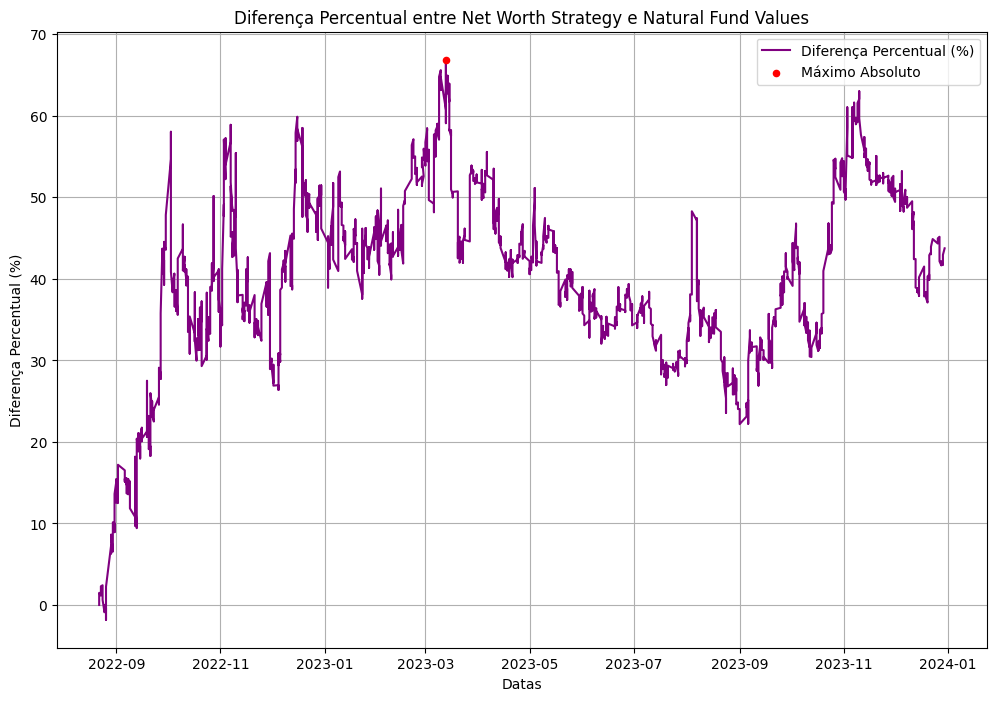

In [80]:
# Calcular a diferença percentual
diff_percentual = (
    (np.array(networth_strategy_array) - np.array(natural_fund_values))
    / np.array(natural_fund_values)
) * 100

# Encontrar o índice do valor máximo absoluto da diferença percentual
max_index = np.argmax(diff_percentual)

# Coordenadas do valor máximo
max_diff_percentual = diff_percentual[max_index]
max_date = last_subsets_dates[max_index]

print(f"Coordenadas do valor máximo absoluto:")
print(f"Data: {max_date}")
print(f"Diferença Percentual Máxima: {max_diff_percentual:.2f}%")

# Traçar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    diff_percentual,
    label="Diferença Percentual (%)",
    color="purple",
)

# Adicionar o ponto máximo ao gráfico
plt.scatter(
    max_date, max_diff_percentual, color="red", s=20, zorder=5, label="Máximo Absoluto"
)

# Rótulos e título
plt.title("Diferença Percentual entre Net Worth Strategy e Natural Fund Values")
plt.xlabel("Datas")
plt.ylabel("Diferença Percentual (%)")

# Calcular a média da diferença percentual
media_diff_percentual = np.mean(diff_percentual)

# Printar o valor médio
print(
    f"Média da Diferença Percentual ao Longo de Todo o Gráfico: {media_diff_percentual:.2f}%"
)

# Adicionar a legenda e grid
plt.legend()
plt.grid(True)

# Mostrar o gráfico
plt.show()

Pela teoria dos grandes números basta o modelo ter uma precisão superior a 50% para que em média quanto mais tempo deixaremos a correr o modelo, ou seja, quantas mais iterasões (previsões) o modelo fizer sobre a bolsa com a estratégia correta mais os retornos da AI se vão distanciar de um simple holder, mais o modelo vai dar outeperform ao mercado. Portanto em teoria quanto mais tempo o modelo correr melhores seram os resultados.

**Estudo do Retorno em Função do Valor Inicial do Fundo:**

Este plot foi feito apenas por descargo de consciência e investigação se poderiam exitir algum tipo de anomalias no código. Ele investiga o retorno percentual no final do dataset de teste em função do investimento inicial que por default é feito com 100 000$. Como era de esperar o retorno percentual não varia consoante o investimento inicial, pois foi permitido o trade na bolsa de ações percentuais.

Atenção este gráfico apresenta o ganho percentual bruto da AI e não a melhoria percentual.

Coordenadas do ponto máximo absoluto: Dinheiro Inicial = $2424316.67, Percentual de Crescimento = 63.400%


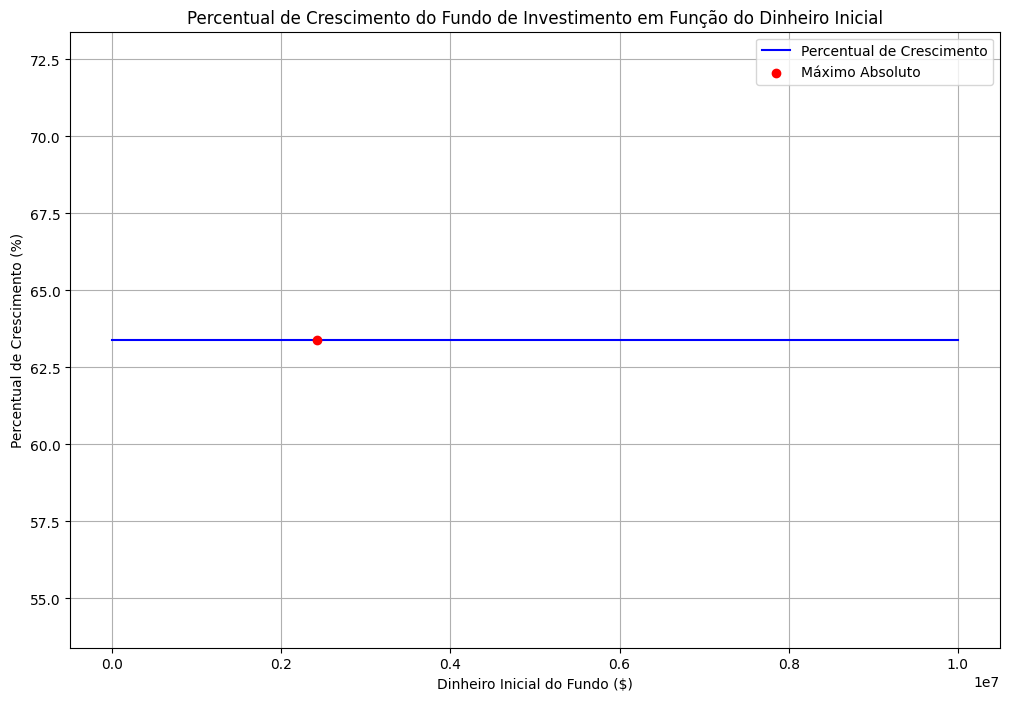

In [81]:
# Definir a faixa de valores para o fundo inicial
initial_fund_values = np.linspace(50, 10000150, 100)  # Valores de $50 a $10,000,000

# Lista para armazenar os resultados (percentual de crescimento para cada fundo inicial)
percentual_ganhos = []

# Loop sobre todos os valores de fundo inicial
for initial_fund in initial_fund_values:
    fund = initial_fund
    num_shares = 0.0  # Posição long (ações compradas)
    num_shares_short = 0.0  # Posição short (ações vendidas a descoberto)
    short_sale_price = 0.0  # Preço de abertura da operação short

    # Iterar pelo tensor (exceto o último que não tem previsão)
    for i in range(len(tensor_np) - 1):
        current_price = float(tensor_np[i + 1][0])  # Preço da ação para a operação
        prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

        # Converter a previsão para float ou definir 0 se for 'none'
        if prediction_str != "none":
            prediction = float(prediction_str)
        else:
            prediction = 0

        # Operação LONG: se a previsão for fortemente positiva (acima de sensibilidade_decisiva2) e houver fundos
        if prediction > sensibilidade_decisiva2 and fund > 0:
            # Se houver posição short aberta, cobrir essa posição primeiro
            if num_shares_short > 0:
                profit = num_shares_short * (short_sale_price - current_price)
                fund += profit
                num_shares_short = 0.0
                short_sale_price = 0.0
            # Comprar ações com o fundo disponível
            num_shares_to_buy = fund / current_price
            cost = num_shares_to_buy * current_price
            fund -= cost
            num_shares += num_shares_to_buy

        # Operação SHORT: se a previsão for fortemente negativa (abaixo de sensibilidade_decisiva1)
        elif prediction < sensibilidade_decisiva1:
            # Se houver posição long, vender todas para liberar caixa
            if num_shares > 0:
                proceeds = num_shares * current_price
                fund += proceeds
                num_shares = 0.0
            # Iniciar operação short se não houver short aberto (o valor recebido não é creditado; fica bloqueado)
            if num_shares_short == 0 and fund > 0:
                num_shares_to_short = fund / current_price
                num_shares_short = num_shares_to_short
                short_sale_price = current_price
        else:
            # Zona neutra: nenhuma operação
            pass

    # Ao final do tensor, fechar quaisquer posições abertas:
    final_price = float(tensor_np[-1][0])
    # Fechar posição long, se houver
    if num_shares > 0:
        proceeds = num_shares * final_price
        fund += proceeds
        num_shares = 0.0
    # Fechar posição short, se houver (lucro ou prejuízo do short)
    if num_shares_short > 0:
        profit = num_shares_short * (short_sale_price - final_price)
        fund += profit
        num_shares_short = 0.0
        short_sale_price = 0.0

    # Calcular o percentual de crescimento da estratégia
    percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
    percentual_ganhos.append(percentage_increase_strategy)

# Encontrar o índice do valor máximo em percentual_ganhos
max_index = np.argmax(percentual_ganhos)
max_initial_fund = initial_fund_values[max_index]
max_percentage_increase = percentual_ganhos[max_index]

print(
    f"Coordenadas do ponto máximo absoluto: Dinheiro Inicial = ${max_initial_fund:.2f}, Percentual de Crescimento = {max_percentage_increase:.3f}%"
)

# Plotar o gráfico
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.plot(
    initial_fund_values,
    percentual_ganhos,
    label="Percentual de Crescimento",
    color="blue",
)
plt.scatter(
    max_initial_fund,
    max_percentage_increase,
    color="red",
    zorder=5,
    label="Máximo Absoluto",
)
plt.ylim(min(percentual_ganhos) - 10, max(percentual_ganhos) + 10)
plt.title(
    "Percentual de Crescimento do Fundo de Investimento em Função do Dinheiro Inicial"
)
plt.xlabel("Dinheiro Inicial do Fundo ($)")
plt.ylabel("Percentual de Crescimento (%)")
plt.grid(True)
plt.legend()
plt.show()

### **Independent Parcial Buy and Sell in Function of Predictions Probabilaty**

Agora eu quero testar uma nova estratégia. As compras e as vendas vão ser de forma percentual. Ou seja, sempre que existe um sinal positivo para compra - "1", deve ser gasto "coeficiente * grau_certeza"% (o grau_certeza é dado por "predictions", relembrando que sempre que "predictions" é superior a "sensibilidade_decisiva" é um "1" e sempre que "predictions" é inferior a "sensibilidade_decisiva" é um "0", o grau_certeza é pela certeza que o modelo tem se se trata de um "0" ou de um "1", isto pode ser inferido através de "predictions") do dinheiro do fundo de investimento na compra de ações, se existir algum dinheiro ainda no fundo para o fazer de acordo com o percentual calculado. Sempre que existe um sinal positivo de venda - "0", devem ser vendidas "coeficiente * grau_certeza"% das ações do fundo de investimento, se o fundo tiver ainda ações suficientes para o fazer de acordo com a percentagem calculada. A questão que aqui diferencia da passada estratégia é que agora vão existir 2 coeficientes em jogo um coeficente para ações de venda, coeficiente_v, outro para ações de compra, coeficiente_c.

Esta estratégia é extremamente semelhante á anterior apenas é acrecenta um novo coeficiente e para tal terá de ser distinguido o coeficiente de buy do coeficiente de sell.

if prediction > sensibilidade_decisiva and fund > 0:
    grau_certeza = abs(prediction)  # Grau de certeza do modelo
    # Comprar ações com base no percentual calculado
    amount_to_invest = coeficiente_c * grau_certeza * fund
    num_shares_to_buy = amount_to_invest / current_price  # Quantidade de ações que podemos comprar (fracionária)
    fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
    num_shares += num_shares_to_buy  # Atualiza o número de ações

elif prediction <= sensibilidade_decisiva and num_shares > 0:
    grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
    # Vender ações com base no percentual calculado
    amount_to_sell = coeficiente_v * grau_certeza * num_shares  # Quantidade de ações a vender
    num_shares_to_sell = amount_to_sell  # Quantidade fracionária de ações a vender
    fund += num_shares_to_sell * current_price  # Vende as ações e atualiza o fundo
    num_shares -= num_shares_to_sell  # Atualiza o número de ações após a venda

Por este código passam 3 loops diferentes todos uns dentro uns dos outros assim consigo garantir que para cada coeficiente de compra é testado para todos os valores de coeficiente de venda e para todos os valores de sensibilidade decisiva.

**Estudo do Melhor Coeficiente e Melhor Sensibilidade Decisiva para Formatar o Percentual Investido:**


Assim este código permite plotar e analisar os retornos financeiros da estratégia implementada em função do valor da sensibilidade decisiva e do coeficientes. O portefólio que ao começar com 100 000$ tiver os maiores retornos financeiros com a sensibilidade decisiva e com o coeficientes utilizados sinalarizará a melhor combinação sensibilidade decisiva, coeficiente para a estratégia de gestão de portefólio e para o modelo.

É imporante destacar que o gráfico apresentado e os valores tidos em conta para escolher a sensibilidade decisiva pelo facto de estaremos à procura de uma estratégia que "derrote" o mercado o valor de retorno ao se estudar a estratégia é originado pela seguinte formula:

retorno percetual do investimento inicial da estratégia em estudo com a sensibilidade decisiva e coefieciente em vigor - retorno percentual do investimento inicial para um simples buy em holder = melhoria percentual

a melhoria percentual mais elevada corresponde á melhor combinação sensibilidade decisiva, coeficientes.

In [82]:
# Fundo inicial e baseline para comparação
initial_fund = 100000  # Fundo inicial de $100,000
# percentage_increase é o benchmark, já definido no contexto

# Listas para armazenar as coordenadas e os resultados
x_vals = []  # Sensibilidade Decisiva 1 (Venda/Short)
y_vals = []  # Sensibilidade Decisiva 2 (Compra/Long)
z_vals = []  # Coeficiente C (Compra)
w_vals = []  # Coeficiente V (Venda)  -- pode ser usado para representar dimensão adicional
u_vals = []  # Coeficiente S (Short-selling)
color_vals_med = []  # Média da Diferença Percentual
color_vals = []  # Ganho Percentual Ajustado (ganho da estratégia menos o benchmark)

# Loop sobre todas as combinações dos parâmetros, iterando primeiro sobre os thresholds:
for sd1 in sensibilidade_decisiva1_array:
    for sd2 in sensibilidade_decisiva2_array:
        for coef_c in coeficiente_c_array:
            for coeficiente_v in coeficiente_v_array:
                for coeficiente_s in coeficiente_s_array:
                    # Inicialização das variáveis para esta simulação
                    fund = initial_fund
                    num_shares = 0.0  # Posição long (ações compradas)
                    num_shares_short = (
                        0.0  # Posição short (ações vendidas a descoberto)
                    )
                    short_sale_price = 0.0  # Preço de abertura do short
                    networth_strategy = []  # Evolução do patrimônio líquido ao longo do tempo

                    # Iterar sobre o tensor (exceto o último, sem previsão)
                    for m in range(len(tensor_np) - 1):
                        current_price = float(tensor_np[m + 1][0])
                        prediction_str = tensor_np[m][1]

                        if prediction_str != "none":
                            prediction = float(prediction_str)
                        else:
                            prediction = 0

                        # Se a previsão for alta: operar COMPRA LONG somente se > sd2 e se houver fundos
                        if prediction > sd2 and fund > 0:
                            # Se houver posição short aberta, cobrir primeiro
                            if num_shares_short > 0:
                                profit = num_shares_short * (
                                    short_sale_price - current_price
                                )
                                fund += profit
                                num_shares_short = 0.0
                                short_sale_price = 0.0
                            grau_certeza = abs(prediction)
                            percentage_to_spend = coef_c * grau_certeza
                            if percentage_to_spend > 1:
                                percentage_to_spend = 1
                            amount_to_invest = percentage_to_spend * fund
                            num_shares_to_buy = amount_to_invest / current_price
                            fund -= num_shares_to_buy * current_price
                            num_shares += num_shares_to_buy

                        # Se a previsão for baixa: operar VENDA e SHORT-selling se < sd1
                        elif prediction < sd1:
                            # Se houver posição long, vender parte dela conforme coeficiente_v
                            if num_shares > 0:
                                grau_certeza = abs(1 - prediction)
                                percentage_to_sell = coeficiente_v * grau_certeza
                                if percentage_to_sell > 1:
                                    percentage_to_sell = 1
                                amount_to_sell = percentage_to_sell * num_shares
                                fund += amount_to_sell * current_price
                                num_shares -= amount_to_sell
                            # Se não houver posição long e ainda não estiver em short, iniciar short-selling
                            if num_shares == 0 and num_shares_short == 0 and fund > 0:
                                grau_certeza_short = abs(1 - prediction)
                                percentage_to_short = coeficiente_s * grau_certeza_short
                                if percentage_to_short > 1:
                                    percentage_to_short = 1
                                amount_to_short = percentage_to_short * fund
                                num_shares_to_short = amount_to_short / current_price
                                num_shares_short = num_shares_to_short
                                short_sale_price = current_price
                        else:
                            # Se a previsão estiver entre os dois thresholds, nenhuma operação é executada.
                            pass

                        # Registrar a evolução do patrimônio (só caixa e posição long são contabilizados)
                        current_networth = fund + num_shares * current_price
                        networth_strategy.append(current_networth)

                    # Ao final do tensor, fechar quaisquer posições abertas:
                    final_price = float(tensor_np[-1][0])
                    # Fechar posição long, se houver
                    if num_shares > 0:
                        proceeds = num_shares * final_price
                        fund += proceeds
                        num_shares = 0.0
                    # Fechar posição short, se houver
                    if num_shares_short > 0:
                        profit = num_shares_short * (short_sale_price - final_price)
                        fund += profit
                        num_shares_short = 0.0
                        short_sale_price = 0.0
                    networth_strategy.append(fund)

                    # Calcular a diferença percentual entre a estratégia simulada e o fundo natural
                    diff_percentual = (
                        (np.array(networth_strategy) - np.array(natural_fund_values))
                        / np.array(natural_fund_values)
                    ) * 100
                    media_diff_percentual = np.mean(diff_percentual)

                    # Calcular o ganho percentual da estratégia e ajustar em relação à baseline
                    percentual_ganho = ((fund - initial_fund) / initial_fund) * 100
                    gain_adjusted = percentual_ganho - percentage_increase

                    # Armazenar os parâmetros e resultados para análise/plotagem
                    x_vals.append(sd1)  # Sensibilidade Decisiva 1 (venda/short)
                    y_vals.append(sd2)  # Sensibilidade Decisiva 2 (compra/long)
                    z_vals.append(coef_c)  # Coeficiente C (compra)
                    w_vals.append(coeficiente_v)  # Coeficiente V (venda)
                    u_vals.append(coeficiente_s)  # Coeficiente S (short-selling)
                    color_vals_med.append(media_diff_percentual)
                    color_vals.append(gain_adjusted)

Top 1 ponto:
  Sensibilidade Decisiva 1 = 1.00
  Sensibilidade Decisiva 2 = 0.30
  Coeficiente C          = 3.00
  Coeficiente V          = 5.00
  Coeficiente S          = 5.00
  Ganho Percentual Ajustado (%) = 53.6009

Top 2 ponto:
  Sensibilidade Decisiva 1 = 0.30
  Sensibilidade Decisiva 2 = 0.80
  Coeficiente C          = 3.00
  Coeficiente V          = 5.00
  Coeficiente S          = 5.00
  Ganho Percentual Ajustado (%) = 49.7287

Top 3 ponto:
  Sensibilidade Decisiva 1 = 0.30
  Sensibilidade Decisiva 2 = 0.80
  Coeficiente C          = 4.00
  Coeficiente V          = 2.00
  Coeficiente S          = 4.00
  Ganho Percentual Ajustado (%) = 49.7287



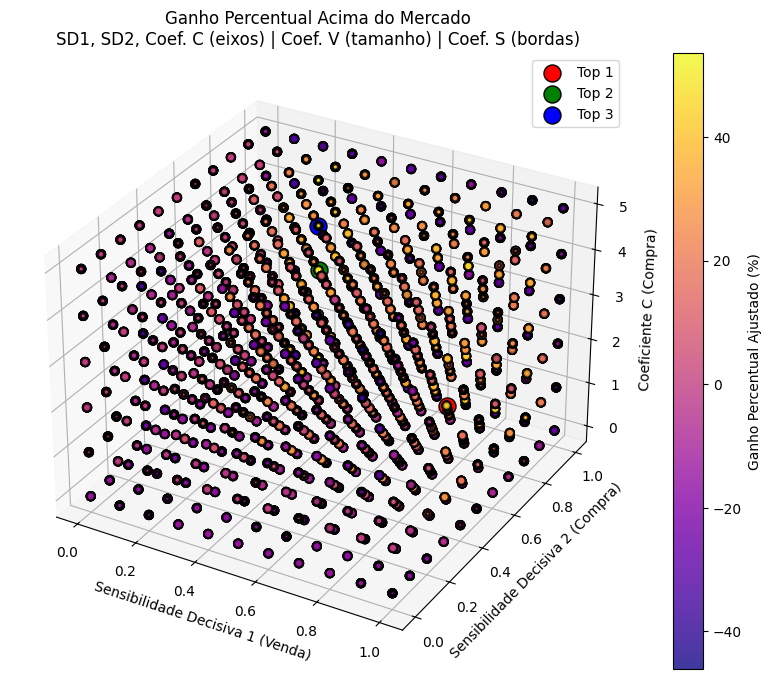

In [83]:
# Converter para arrays NumPy (assegure-se de que as listas foram preenchidas corretamente)
sd1_vals = np.array(x_vals)  # Sensibilidade Decisiva 1 (Venda)
sd2_vals = np.array(y_vals)  # Sensibilidade Decisiva 2 (Compra)
coef_c_vals = np.array(z_vals)  # Coeficiente C (Compra) – usamos z_vals para Coef. C
coef_v_vals = np.array(
    w_vals
)  # Coeficiente V (Venda/Short) – usamos w_vals para Coef. V
coef_s_vals = np.array(u_vals)  # Coeficiente S (Short-selling) – armazenado em u_vals
color_vals = np.array(color_vals)  # Ganho Percentual Ajustado

# Mapear o tamanho dos marcadores a partir do Coeficiente V
sizes = coef_v_vals * 7

# Mapear a espessura das bordas a partir do Coeficiente S
edge_widths = coef_s_vals - 1

# Criar o gráfico 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Como o parâmetro linewidths não aceita vetor, usamos a média para todos
mean_edge_width = np.mean(edge_widths)

sc = ax.scatter(
    sd1_vals,
    sd2_vals,
    coef_c_vals,
    c=color_vals,
    cmap="plasma",
    s=sizes,
    alpha=0.8,
    linewidths=mean_edge_width,
    edgecolor="black",
)

# Barra de cor
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Ganho Percentual Ajustado (%)")

# Configurar os rótulos e título
ax.set_title(
    "Ganho Percentual Acima do Mercado\nSD1, SD2, Coef. C (eixos) | Coef. V (tamanho) | Coef. S (bordas)"
)
ax.set_xlabel("Sensibilidade Decisiva 1 (Venda)")
ax.set_ylabel("Sensibilidade Decisiva 2 (Compra)")
ax.set_zlabel("Coeficiente C (Compra)")

# Identificar os 3 melhores pontos com base nos maiores valores de color_vals
top3_indices = np.argsort(color_vals)[-3:][::-1]

# Cores para destacar os 3 melhores pontos
top_colors = ["red", "green", "blue"]

# Imprimir e destacar os 3 melhores pontos
for rank, idx in enumerate(top3_indices, start=1):
    sd1_top = sd1_vals[idx]
    sd2_top = sd2_vals[idx]
    coef_c_top = coef_c_vals[idx]
    coef_v_top = coef_v_vals[idx]
    coef_s_top = coef_s_vals[idx]
    gain_top = color_vals[idx]

    print(f"Top {rank} ponto:")
    print(f"  Sensibilidade Decisiva 1 = {sd1_top:.2f}")
    print(f"  Sensibilidade Decisiva 2 = {sd2_top:.2f}")
    print(f"  Coeficiente C          = {coef_c_top:.2f}")
    print(f"  Coeficiente V          = {coef_v_top:.2f}")
    print(f"  Coeficiente S          = {coef_s_top:.2f}")
    print(f"  Ganho Percentual Ajustado (%) = {gain_top:.4f}\n")

    if rank == 1:
        Results_Last_cS_array.append(
            [sd1_top, sd2_top, coef_c_top, coef_v_top, coef_s_top, gain_top]
        )

    # Destacar o ponto no gráfico
    ax.scatter(
        sd1_top,
        sd2_top,
        coef_c_top,
        color=top_colors[rank - 1],
        s=150,
        edgecolor="black",
        label=f"Top {rank}",
    )

ax.legend()
plt.show()

Mais tarde precebeu-se que pode ser enganador apenas analisar o retorno no final do periodo temporal do dataset de teste. Para contornar esta questão foi desenvolvida outra metodologia.

Será capturado o retorno financeiro percentual em termos de networth do portefólio comparativamente com o valor inicial dado de 100 000$. Esse retorno financeiro a cada trade executada, ou melhor a cada matriz temporal analisada e prevista pelo o modelo será subtraindo o valor da networth de um portefólio que segue naturalmente o mercado (simple holder), para obter a "melhoria percentual". Mas desta ves estará se a obter a melhoria percentual a cada previsão do modelo. Ao se fazer a média da melhoria percentual ao longo de todas as previsões do modelo, ou seja, ao longo de todo o dataset de teste é possível preceber qual é a combinação sensibilidade decisiva, coeficientes que maximiza o valor da "média da melhoria percentual". Desta forma é possível concluir qual é a melhor combinação sensibilidade decisiva, coeficientes para este modelo e para esta estratégia anulando o impacto de estaremos a olhar para os retornos apenas de um evento temporal como o final do dataset de teste, mas sim tendo em conta a performance do modelo e da estrátegia ao longo de todo o dataset de teste.

Top 1 ponto:
  Sensibilidade Decisiva 1 = 0.30
  Sensibilidade Decisiva 2 = 0.80
  Coeficiente C          = 4.00
  Coeficiente V          = 2.00
  Coeficiente S          = 2.00
  Média Diferença Percentual (%) = 39.8807

Top 2 ponto:
  Sensibilidade Decisiva 1 = 0.30
  Sensibilidade Decisiva 2 = 0.80
  Coeficiente C          = 5.00
  Coeficiente V          = 3.00
  Coeficiente S          = 3.00
  Média Diferença Percentual (%) = 39.8807

Top 3 ponto:
  Sensibilidade Decisiva 1 = 0.30
  Sensibilidade Decisiva 2 = 0.80
  Coeficiente C          = 3.00
  Coeficiente V          = 5.00
  Coeficiente S          = 2.00
  Média Diferença Percentual (%) = 39.8807



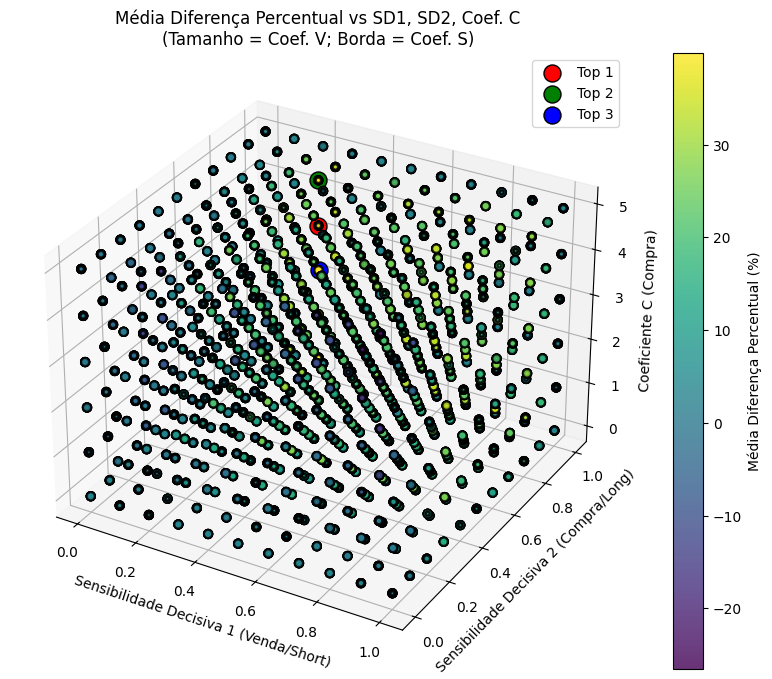

In [84]:
# Converter as listas para arrays NumPy
# x_vals: Sensibilidade Decisiva 1 (Venda/Short)
# y_vals: Sensibilidade Decisiva 2 (Compra/Long)
# z_vals: Coeficiente C (Compra)
# w_vals: Coeficiente V (Venda)
# u_vals: Coeficiente S (Short-selling)
# color_vals_med: Média da Diferença Percentual
x_vals = np.array(x_vals)
y_vals = np.array(y_vals)
z_vals = np.array(z_vals)
w_vals = np.array(w_vals)
v_vals = np.array(u_vals)  # Coeficiente S
color_vals_med = np.array(color_vals_med)

# Mapear o tamanho dos marcadores a partir do Coeficiente V
sizes = w_vals * 7  # Ajuste o fator de escala conforme necessário

# Mapear a espessura das bordas a partir do Coeficiente S
edge_widths = v_vals - 1  # Ajuste o fator de escala conforme necessário
# Como scatter() não aceita vetor para linewidths, usamos a média como valor constante:
mean_edge_width = np.mean(edge_widths)

# Criar o gráfico 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Scatter plot 3D:
# - Eixo X: Sensibilidade Decisiva 1 (Venda/Short)
# - Eixo Y: Sensibilidade Decisiva 2 (Compra/Long)
# - Eixo Z: Coeficiente C (Compra)
# - Tamanho: representa o Coeficiente V
# - Cor: representa a Média da Diferença Percentual
sc = ax.scatter(
    x_vals,
    y_vals,
    z_vals,
    c=color_vals_med,
    cmap="viridis",
    s=sizes,
    alpha=0.8,
    linewidths=mean_edge_width,
    edgecolor="black",
)

# Barra de cor
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Média Diferença Percentual (%)")

# Configurar os rótulos e título
ax.set_title(
    "Média Diferença Percentual vs SD1, SD2, Coef. C\n(Tamanho = Coef. V; Borda = Coef. S)"
)
ax.set_xlabel("Sensibilidade Decisiva 1 (Venda/Short)")
ax.set_ylabel("Sensibilidade Decisiva 2 (Compra/Long)")
ax.set_zlabel("Coeficiente C (Compra)")

# Identificar os 3 melhores pontos com base nos maiores valores de color_vals_med
top3_indices = np.argsort(color_vals_med)[-3:][::-1]

# Cores para destacar os 3 melhores pontos
top_colors = ["red", "green", "blue"]

# Imprimir e destacar os 3 melhores pontos
for rank, idx in enumerate(top3_indices, start=1):
    x_top = x_vals[idx]
    y_top = y_vals[idx]
    z_top = z_vals[idx]
    w_top = w_vals[idx]
    v_top = v_vals[idx]
    gain_top = color_vals_med[idx]

    print(f"Top {rank} ponto:")
    print(f"  Sensibilidade Decisiva 1 = {x_top:.2f}")
    print(f"  Sensibilidade Decisiva 2 = {y_top:.2f}")
    print(f"  Coeficiente C          = {z_top:.2f}")
    print(f"  Coeficiente V          = {w_top:.2f}")
    print(f"  Coeficiente S          = {v_top:.2f}")
    print(f"  Média Diferença Percentual (%) = {gain_top:.4f}\n")

    if rank == 1:
        Results_Mean_cS_array.append([x_top, y_top, z_top, w_top, v_top, gain_top])

    # Destacar o ponto no gráfico
    ax.scatter(
        x_top,
        y_top,
        z_top,
        color=top_colors[rank - 1],
        s=150,
        edgecolor="black",
        label=f"Top {rank}",
    )

ax.legend()
plt.show()

In [85]:
# Cria o DataFrame utilizando os arrays resultantes da simulação:
df = pd.DataFrame(
    {
        "Sensibilidade_Decisiva": x_vals,
        "Coeficiente_C": y_vals,
        "Coeficiente_V": z_vals,
        "Coeficiente_S": w_vals,  # Representado pelo tamanho dos marcadores
        "Media_Diferenca_Percentual": color_vals_med,  # Representado pela cor dos marcadores
    }
)

# Cria o gráfico 3D onde:
# - os eixos X, Y e Z representam Sensibilidade Decisiva, Coeficiente C e Coeficiente V, respectivamente;
# - o tamanho dos marcadores indica o Coeficiente S;
# - a cor dos marcadores indica a Média da Diferença Percentual.
fig = px.scatter_3d(
    df,
    x="Sensibilidade_Decisiva",
    y="Coeficiente_C",
    z="Coeficiente_V",
    color="Media_Diferenca_Percentual",
    size="Coeficiente_S",
    title="Visualização 5D dos Parâmetros da Estratégia de Portfólio",
)

fig.show()

**Analisando o melhor caso dado pela melhor média de diferança entre o mercado e a estratégia:**

Nesta parte do algoritmo dedicamo-nos a analisar detalhadamente o que é que acontece para uma combinação especifica de sensibilidade decisiva e coeficientes.

Geralmente a ideia é analisar detalhadamente o que é que acontece com a combinação considerado ideal encotrado anteriormente.

In [86]:
sensibilidade_decisiva1 = round(Results_Mean_cS_array[1][0], int(-math.log10(Step_SD)))
print(f"Sensibilidade Decisiva 1: {sensibilidade_decisiva1}")
sensibilidade_decisiva2 = round(Results_Mean_cS_array[1][1], int(-math.log10(Step_SD)))
print(f"Sensibilidade Decisiva 2: {sensibilidade_decisiva2}")
coeficiente_c = round(Results_Mean_cS_array[1][2], int(-math.log10(Step_Coefficient)))
print(f"Coeficiente de Compra: {coeficiente_c}")
coeficiente_v = round(Results_Mean_cS_array[1][3], int(-math.log10(Step_Coefficient)))
print(f"Coeficiente de Venda: {coeficiente_v}")
coeficiente_s_array = round(
    Results_Mean_cS_array[1][4], int(-math.log10(Step_Coefficient))
)
print(f"Coeficiente de Short-Selling: {coeficiente_s_array}")

Sensibilidade Decisiva 1: 0.3
Sensibilidade Decisiva 2: 0.8
Coeficiente de Compra: 4
Coeficiente de Venda: 2
Coeficiente de Short-Selling: 2


Todas as trasações executadas para a estratégia com esta sensibilidade decisiva. Assim como um acaompanhamento do balanço ações/dinheiro do portefólio.

In [87]:
# Inicializar variáveis
initial_fund = 100000  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0  # Posição long (ações compradas)
num_shares_short = 0.0  # Posição short (ações vendidas a descoberto)
short_sale_price = 0.0  # Preço de abertura da operação short
total_ops = 0.0  # Valor total das operações realizadas
networth_strategy_array = []

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_np) - 1):
    current_price = float(tensor_np[i + 1][0])  # Preço da ação para a operação
    prediction_raw = tensor_np[i][1]  # Previsão atual

    if prediction_raw != "none":
        prediction = float(prediction_raw)
    else:
        prediction = 0.0

    # Determinar sinal (para debug):
    # 1 se previsão > sensibilidade_decisiva2 (compra),
    # -1 se previsão < sensibilidade_decisiva1 (venda/short),
    # 0 se estiver na zona neutra.
    if prediction > sensibilidade_decisiva2:
        signal = 1
    elif prediction < sensibilidade_decisiva1:
        signal = -1
    else:
        signal = 0

    # OPERAÇÃO LONG (compra) se previsão for alta: > sensibilidade_decisiva2
    if prediction > sensibilidade_decisiva2 and fund > 0:
        # Se houver posição short aberta, cobrir primeiro
        if num_shares_short > 0:
            profit = num_shares_short * (short_sale_price - current_price)
            fund += profit
            total_ops += (
                num_shares_short * current_price
            )  # valor da operação de cobertura
            print(
                f"[Período {i}] COBERTURA SHORT: Fechado {num_shares_short:.6f} ações short a {current_price:.2f} por ${num_shares_short * current_price:.2f}. Lucro/Prejuízo: ${profit:.2f}. Novo fundo: ${fund:.2f}."
            )
            num_shares_short = 0.0
            short_sale_price = 0.0

        # Comprar ações com base no coeficiente_c e no grau de certeza
        grau_certeza = abs(prediction)
        percentage_to_spend = coeficiente_c * grau_certeza
        if percentage_to_spend > 1:
            percentage_to_spend = 1
        amount_to_invest = percentage_to_spend * fund
        num_shares_to_buy = amount_to_invest / current_price
        cost = num_shares_to_buy * current_price
        fund -= cost
        total_ops += cost
        num_shares += num_shares_to_buy
        print(
            f"[Período {i}] COMPRA LONG: Comprado {num_shares_to_buy:.6f} ações a {current_price:.2f} por ${cost:.2f}. Liquidez: ${fund:.2f}."
        )

    # OPERAÇÃO VENDA/SHORT se previsão for baixa: < sensibilidade_decisiva1
    elif prediction < sensibilidade_decisiva1:
        # Se houver posição long, vender parte dela conforme coeficiente_v
        if num_shares > 0:
            grau_certeza = abs(1 - prediction)
            percentage_to_sell = coeficiente_v * grau_certeza
            if percentage_to_sell > 1:
                percentage_to_sell = 1
            amount_to_sell = percentage_to_sell * num_shares
            proceeds = amount_to_sell * current_price
            fund += proceeds
            total_ops += proceeds
            num_shares -= amount_to_sell
            print(
                f"[Período {i}] VENDA LONG: Vendido {amount_to_sell:.6f} ações a {current_price:.2f} por ${proceeds:.2f}. Liquidez: ${fund:.2f}."
            )

        # Se não houver posição long e nem short aberta, iniciar operação short
        if num_shares == 0 and num_shares_short == 0 and fund > 0:
            grau_certeza_short = abs(1 - prediction)
            percentage_to_short = coeficiente_s * grau_certeza_short
            if percentage_to_short > 1:
                percentage_to_short = 1
            # Utiliza o fundo disponível como capacidade máxima para short-selling
            amount_to_short = percentage_to_short * fund
            num_shares_to_short = amount_to_short / current_price
            num_shares_short = num_shares_to_short
            short_sale_price = current_price
            total_ops += num_shares_to_short * current_price
            print(
                f"[Período {i}] ABERTURA SHORT: Vendido a descoberto {num_shares_to_short:.6f} ações a {current_price:.2f} por ${num_shares_to_short * current_price:.2f}. (Fundo permanece: ${fund:.2f})."
            )

    else:
        print(
            f"[Período {i}] SEM OPERAÇÃO: Previsão {prediction:.5f} está na zona neutra. Liquidez: ${fund:.2f}."
        )

    # Cálculo da networth do portfólio (contando somente o fundo e posições long)
    current_networth = fund + num_shares * current_price
    print(
        f"[Período {i}] Networth: ${current_networth:.2f} | Preço: {current_price:.2f} | Prediction: {prediction:.5f} | Sinal: {signal}"
    )
    networth_strategy_array.append(current_networth)

# Ao final do tensor, fechar quaisquer posições abertas:
final_price = float(tensor_np[-1][0])

# Fechar posição long, se houver
if num_shares > 0:
    proceeds = num_shares * final_price
    fund += proceeds
    total_ops += proceeds
    print(
        f"[Final] FECHAMENTO LONG: Vendido {num_shares:.6f} ações a {final_price:.2f} por ${proceeds:.2f}."
    )
    num_shares = 0.0

# Fechar posição short, se houver (realizando lucro ou prejuízo do short)
if num_shares_short > 0:
    profit = num_shares_short * (short_sale_price - final_price)
    fund += profit
    total_ops += num_shares_short * final_price  # valor da operação de cobertura
    print(
        f"[Final] FECHAMENTO SHORT: Fechado {num_shares_short:.6f} ações short a {final_price:.2f} por ${num_shares_short * final_price:.2f}. Lucro/Prejuízo: ${profit:.2f}."
    )
    num_shares_short = 0.0
    short_sale_price = 0.0

print(f"\nBalanço final do fundo de investimento: ${fund:.2f}")
networth_strategy_array.append(fund)
percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
print(
    f"Percentual de crescimento do fundo com a estratégia: {percentage_increase_strategy:.3f}%"
)
print(f"Valor Total das Operações Realizadas: ${total_ops:.2f}")

[Período 0] ABERTURA SHORT: Vendido a descoberto 591.575958 ações a 169.04 por $100000.00. (Fundo permanece: $100000.00).
[Período 0] Networth: $100000.00 | Preço: 169.04 | Prediction: 0.10404 | Sinal: -1
[Período 1] Networth: $100000.00 | Preço: 169.01 | Prediction: 0.14351 | Sinal: -1
[Período 2] Networth: $100000.00 | Preço: 167.66 | Prediction: 0.13901 | Sinal: -1
[Período 3] SEM OPERAÇÃO: Previsão 0.33015 está na zona neutra. Liquidez: $100000.00.
[Período 3] Networth: $100000.00 | Preço: 167.70 | Prediction: 0.33015 | Sinal: 0
[Período 4] COBERTURA SHORT: Fechado 591.575958 ações short a 167.87 por $99307.86. Lucro/Prejuízo: $692.14. Novo fundo: $100692.14.
[Período 4] COMPRA LONG: Comprado 599.822147 ações a 167.87 por $100692.14. Liquidez: $0.00.
[Período 4] Networth: $100692.14 | Preço: 167.87 | Prediction: 0.99795 | Sinal: 1
[Período 5] SEM OPERAÇÃO: Previsão 0.99421 está na zona neutra. Liquidez: $0.00.
[Período 5] Networth: $100452.22 | Preço: 167.47 | Prediction: 0.99421 |

Plot da networth do portefóflio usando esta estratégia com esta combinação sensibilidade decisiva, coeficientes para este modelo.

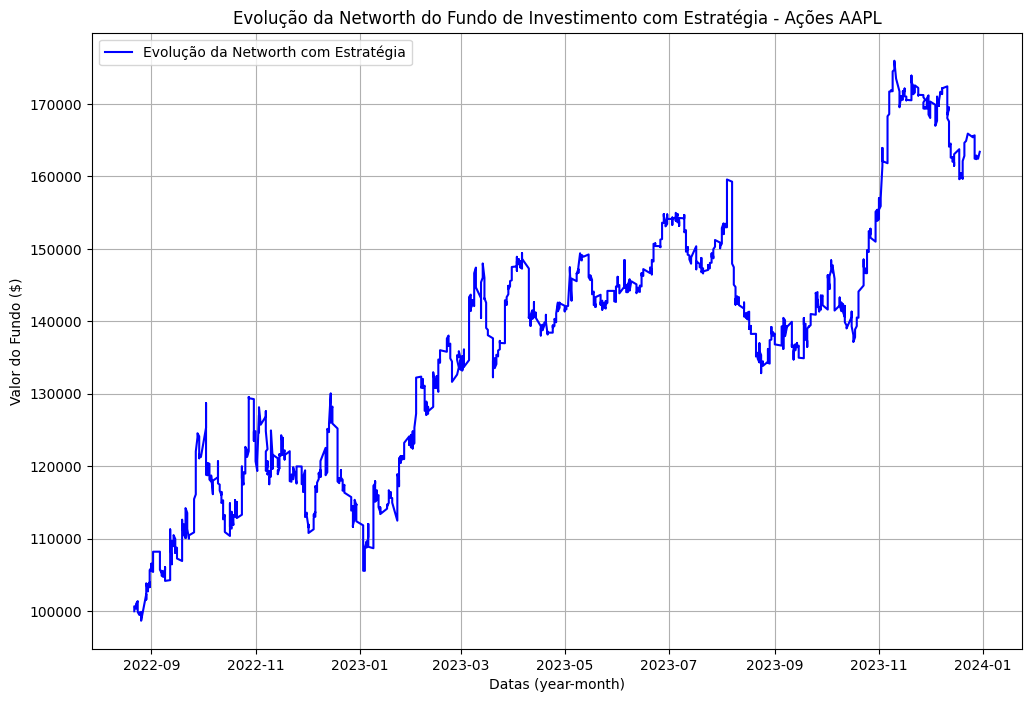

In [88]:
# Gerar o gráfico da evolução da networth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    networth_strategy_array,
    label="Evolução da Networth com Estratégia",
    color="blue",
)
plt.title(
    "Evolução da Networth do Fundo de Investimento com Estratégia - Ações " + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva e coeficiente para este modelo. Combinado com o plot da estratégia mais basica que acompanha e é igual a olhar para o mercado diretamente - simpler long-holder.

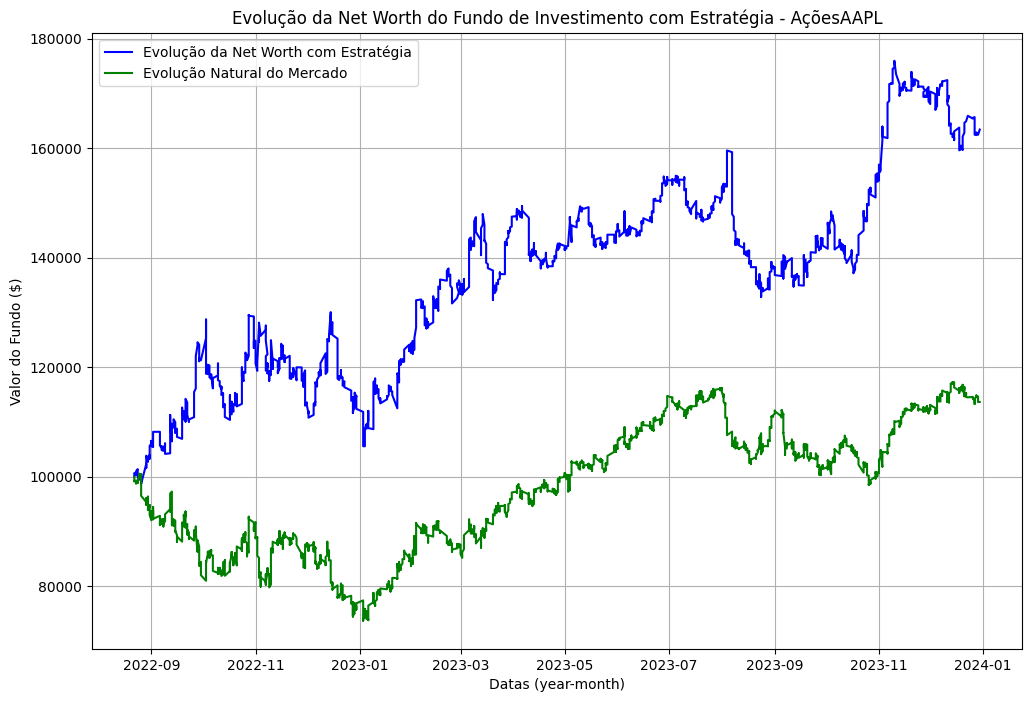

In [89]:
# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    dates_list[-(len(networth_strategy_array)) :],
    networth_strategy_array,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)
plt.plot(
    last_subsets_dates,
    natural_fund_values,
    label="Evolução Natural do Mercado",
    color="green",
)

plt.title(
    "Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações" + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Quanto dinheiro a mais se ganhou ao se ter usado este modelo com esta estratégia no final do periodo do dataset de teste?

Dinheiro ganho com esta estratégia - Dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

Melhoria percentual ao se ter usado esta estratégia:

aumento percentual do dinheiro ganho com esta estratégia - aumento percentual do dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

In [90]:
print(
    f"Dinheiro extra ganho ao se ter usado AI: {fund - percentage_increase - final_value:.3f}$"
)

print(
    f"\nMelhoria percentual ao se ter usado AI: {percentage_increase_strategy - percentage_increase:.3f}%"
)

Dinheiro extra ganho ao se ter usado AI: 49714.997$

Melhoria percentual ao se ter usado AI: 49.729%


Diferença percentual = Melhoria Percentual

Plot do gráfico que nos dá a melhoria percentual ao longo de todo o dataset. A combinação valor da sensibilidade decisiva, coeficiente deve de ser dada pela média mais elevada de valores de melhoria percentual ao longo de todo este gráfico em função da sensibilidade decisiva.

Melhoria decisiva = ganho percentual da estratégia com o modelo - ganho percentual de um simple holder

simple holder = natural fund values

Coordenadas do valor máximo absoluto:
Data: 2023-03-13
Diferença Percentual Máxima: 66.88%
Média da Diferença Percentual ao Longo de Todo o Gráfico: 39.88%


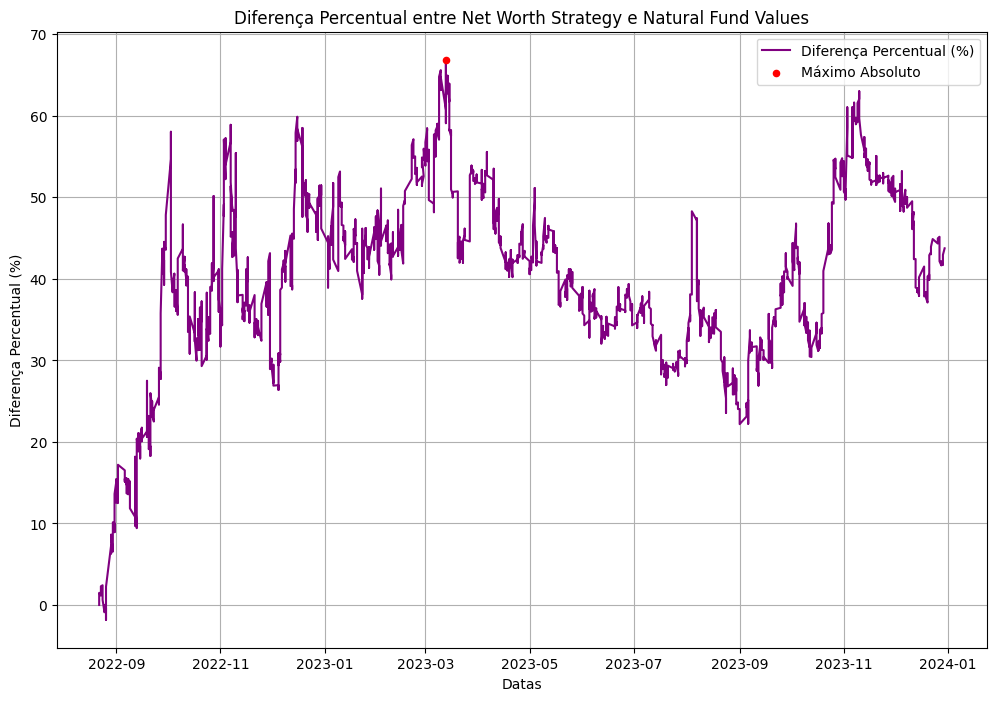

In [91]:
# Calcular a diferença percentual
diff_percentual = (
    (np.array(networth_strategy_array) - np.array(natural_fund_values))
    / np.array(natural_fund_values)
) * 100

# Encontrar o índice do valor máximo absoluto da diferença percentual
max_index = np.argmax(diff_percentual)

# Coordenadas do valor máximo
max_diff_percentual = diff_percentual[max_index]
max_date = last_subsets_dates[max_index]

print(f"Coordenadas do valor máximo absoluto:")
print(f"Data: {max_date}")
print(f"Diferença Percentual Máxima: {max_diff_percentual:.2f}%")

# Traçar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    diff_percentual,
    label="Diferença Percentual (%)",
    color="purple",
)

# Adicionar o ponto máximo ao gráfico
plt.scatter(
    max_date, max_diff_percentual, color="red", s=20, zorder=5, label="Máximo Absoluto"
)

# Rótulos e título
plt.title("Diferença Percentual entre Net Worth Strategy e Natural Fund Values")
plt.xlabel("Datas")
plt.ylabel("Diferença Percentual (%)")

# Calcular a média da diferença percentual
media_diff_percentual = np.mean(diff_percentual)

# Printar o valor médio
print(
    f"Média da Diferença Percentual ao Longo de Todo o Gráfico: {media_diff_percentual:.2f}%"
)

# Adicionar a legenda e grid
plt.legend()
plt.grid(True)

# Mostrar o gráfico
plt.show()

**Estudo do Retorno em Função do Valor Inicial do Fundo:**

Este plot foi feito apenas por descargo de consciência e investigação se poderiam exitir algum tipo de anomalias no código. Ele investiga o retorno percentual no final do dataset de teste em função do investimento inicial que por default é feito com 100 000$. Como era de esperar o retorno percentual não varia consoante o investimento inicial, pois foi permitido o trade na bolsa de ações percentuais.

Atenção este gráfico apresenta o ganho percentual bruto da AI e não a melhoria percentual.

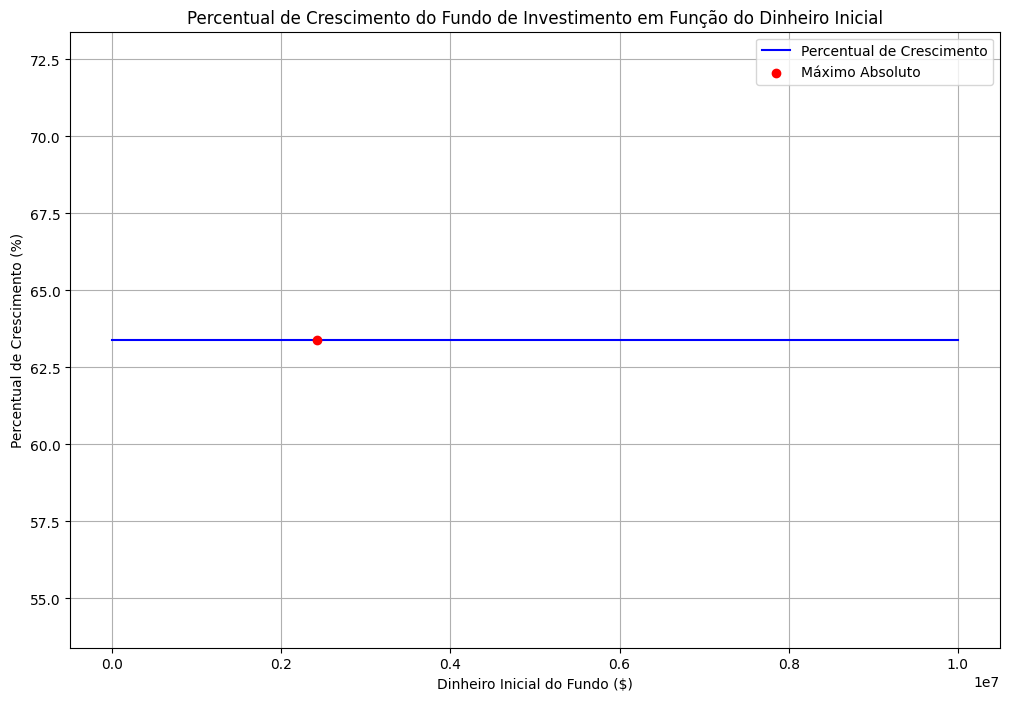

In [92]:
# Definir a faixa de valores para o fundo inicial
initial_fund_values = np.linspace(50, 10000150, 100)  # Valores de $50 a $10,000,150

# Lista para armazenar os resultados de percentual de ganhos para cada fundo inicial
percentual_ganhos = []

# Loop sobre todos os valores de fundo inicial
for initial_fund in initial_fund_values:
    fund = initial_fund
    num_shares = 0.0  # Posição long (ações compradas)
    num_shares_short = 0.0  # Posição short (ações vendidas a descoberto)
    short_sale_price = 0.0  # Preço de abertura da operação short

    # Iterar pelo tensor (exceto o último que não tem previsão)
    for i in range(len(tensor_np) - 1):
        current_price = float(tensor_np[i + 1][0])  # Preço da ação para a operação
        prediction_raw = tensor_np[i][1]  # Previsão atual (grau de certeza)

        # Converter a previsão para float ou definir 0 se for 'none'
        if prediction_raw != "none":
            prediction = float(prediction_raw)
        else:
            prediction = 0.0

        # OPERAÇÃO LONG (compra) se previsão for fortemente alta: > sensibilidade_decisiva2
        if prediction > sensibilidade_decisiva2 and fund > 0:
            # Se houver posição short aberta, cobrir (fechar) o short primeiro
            if num_shares_short > 0:
                profit = num_shares_short * (short_sale_price - current_price)
                fund += profit
                num_shares_short = 0.0
                short_sale_price = 0.0

            # Comprar ações: investir uma fração do fundo determinada pelo coeficiente_C e pelo grau de certeza
            grau_certeza = abs(prediction)
            percentage_to_spend = coeficiente_c * grau_certeza
            if percentage_to_spend > 1:
                percentage_to_spend = 1
            amount_to_invest = percentage_to_spend * fund
            num_shares_to_buy = amount_to_invest / current_price
            cost = num_shares_to_buy * current_price
            fund -= cost
            num_shares += num_shares_to_buy

        # OPERAÇÃO VENDA/SHORT se previsão for fortemente baixa: < sensibilidade_decisiva1
        elif prediction < sensibilidade_decisiva1:
            # Se houver posição long, vende uma fração determinada pelo coeficiente_V e pelo grau de certeza
            if num_shares > 0:
                grau_certeza = abs(1 - prediction)
                percentage_to_sell = coeficiente_v * grau_certeza
                if percentage_to_sell > 1:
                    percentage_to_sell = 1
                amount_to_sell = percentage_to_sell * num_shares
                proceeds = amount_to_sell * current_price
                fund += proceeds
                num_shares -= amount_to_sell

            # Se não houver posição long e nem short aberta, iniciar operação short
            if num_shares == 0 and num_shares_short == 0 and fund > 0:
                grau_certeza_short = abs(1 - prediction)
                percentage_to_short = coeficiente_s * grau_certeza_short
                if percentage_to_short > 1:
                    percentage_to_short = 1
                # Utiliza o fundo disponível como capacidade máxima para short-selling
                amount_to_short = percentage_to_short * fund
                num_shares_to_short = amount_to_short / current_price
                num_shares_short = num_shares_to_short
                short_sale_price = current_price
        else:
            # Zona neutra: nenhuma operação
            pass

    # Ao final do tensor, fechar quaisquer posições abertas:
    final_price = float(tensor_np[-1][0])

    # Fechar posição long, se houver
    if num_shares > 0:
        proceeds = num_shares * final_price
        fund += proceeds
        num_shares = 0.0

    # Fechar posição short, se houver (realizando lucro ou prejuízo do short)
    if num_shares_short > 0:
        profit = num_shares_short * (short_sale_price - final_price)
        fund += profit
        num_shares_short = 0.0
        short_sale_price = 0.0

    # Calcular o percentual de crescimento da estratégia
    percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
    percentual_ganhos.append(percentage_increase_strategy)

# Encontrar o índice do valor máximo de percentual_ganhos
max_index = np.argmax(percentual_ganhos)
max_initial_fund = initial_fund_values[max_index]
max_percentage_increase = percentual_ganhos[max_index]

# Plotar o gráfico
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.plot(
    initial_fund_values,
    percentual_ganhos,
    label="Percentual de Crescimento",
    color="blue",
)
plt.scatter(
    max_initial_fund,
    max_percentage_increase,
    color="red",
    zorder=5,
    label="Máximo Absoluto",
)
plt.ylim(min(percentual_ganhos) - 10, max(percentual_ganhos) + 10)
plt.title(
    "Percentual de Crescimento do Fundo de Investimento em Função do Dinheiro Inicial"
)
plt.xlabel("Dinheiro Inicial do Fundo ($)")
plt.ylabel("Percentual de Crescimento (%)")
plt.grid(True)
plt.legend()
plt.show()

# **Results Com Short-Selling**

Aqui podes comprar todas as estratégias testadas anteriormente sem short selling lado a lado para teres uma melhor visão comprativa de qual funciona melhor.

In [93]:
def print_header(title):
    """Prints a header with an underline for emphasis."""
    print(title)
    print("-" * len(title))


def print_section(title):
    """Prints a section header followed by a blank line."""
    print_header(title)
    print()


def print_result_line(prefix, data, labels, formats):
    """
    Prints a result line using the provided prefix, labels, and format strings.

    :param prefix: A string to print before the results (can be empty).
    :param data: A tuple or list of values to be printed.
    :param labels: A list of label names for each value.
    :param formats: A list of format strings for each corresponding value.
    """
    parts = [
        f"{label}={fmt.format(val)}" for label, val, fmt in zip(labels, data, formats)
    ]
    print(f"{prefix}{'; '.join(parts)}")

In [94]:
# Main Market Growth Information
print(
    f"Crescimento Natural do Mercado Entre {last_subsets_dates[0]} e {last_subsets_dates[-1]} para ações {symbol}:"
)
print(f"{percentage_increase:.5f}%\n")

print_section("Com Short-Selling:")

# Section: Results based on Mean Percentage Difference with Short-Selling
print_section("Resultados ao Otimizar em Função da Média da Diferença Percentual:")

print("Absolute Buy and Sell com Short-Selling:")
print_result_line(
    prefix="  ",
    data=Results_Mean_cS_array[0],
    labels=[
        "Sensibilidade Decisiva 1",
        "Sensibilidade Decisiva 2",
        "Média da Diferença Percentual",
    ],
    formats=["{:.2f}", "{:.2f}", "{:.5f}"],
)
print()

print(
    "Independent Parcial Buy, Sell and Short-Selling in Function of Predictions Probabilaty:"
)
print_result_line(
    prefix="  ",
    data=Results_Mean_cS_array[1],
    labels=[
        "Sensibilidade Decisiva 1",
        "Sensibilidade Decisiva 2",
        "Coeficiente de Compra",
        "Coeficiente de Venda",
        "Coeficiente de Short-Selling",
        "Média da Diferença Percentual",
    ],
    formats=["{:.2f}", "{:.2f}", "{:.2f}", "{:.2f}", "{:.2f}", "{:.5f}"],
)
print("\n")

# Section: Results based on Last Date Percentage Difference with Short-Selling
print_section(
    "Resultados ao Otimizar em Função da Diferença Percentual da Última Data:"
)

print("Absolute Buy and Sell com Short-Selling:")
print_result_line(
    prefix="  ",
    data=Results_Last_cS_array[0],
    labels=[
        "Sensibilidade Decisiva 1",
        "Sensibilidade Decisiva 2",
        "Diferença Percentual",
    ],
    formats=["{:.2f}", "{:.2f}", "{:.5f}"],
)
print()

print(
    "Independent Parcial Buy, Sell and Short-Selling in Function of Predictions Probabilaty:"
)
combined_data = (
    Results_Last_cS_array[1][0],  # Sensibilidade Decisiva 1
    Results_Last_cS_array[1][1],  # Sensibilidade Decisiva 2
    Results_Last_cS_array[1][2],  # Coeficiente de Compra
    Results_Last_cS_array[1][3],  # Coeficiente de Venda
    Results_Last_cS_array[1][4],  # Coeficiente de Short-Selling
    Results_Last_cS_array[1][5],  # Diferença Percentual
)
print_result_line(
    prefix="  ",
    data=combined_data,
    labels=[
        "Sensibilidade Decisiva 1",
        "Sensibilidade Decisiva 2",
        "Coeficiente de Compra",
        "Coeficiente de Venda",
        "Coeficiente de Short-Selling",
        "Diferença Percentual",
    ],
    formats=["{:.2f}", "{:.2f}", "{:.2f}", "{:.2f}", "{:.2f}", "{:.5f}"],
)

Crescimento Natural do Mercado Entre 2022-08-22 e 2023-12-30 para ações AAPL:
13.67132%

Com Short-Selling:
------------------

Resultados ao Otimizar em Função da Média da Diferença Percentual:
------------------------------------------------------------------

Absolute Buy and Sell com Short-Selling:
  Sensibilidade Decisiva 1=0.30; Sensibilidade Decisiva 2=0.80; Média da Diferença Percentual=39.88074

Independent Parcial Buy, Sell and Short-Selling in Function of Predictions Probabilaty:
  Sensibilidade Decisiva 1=0.30; Sensibilidade Decisiva 2=0.80; Coeficiente de Compra=4.00; Coeficiente de Venda=2.00; Coeficiente de Short-Selling=2.00; Média da Diferença Percentual=39.88074


Resultados ao Otimizar em Função da Diferença Percentual da Última Data:
------------------------------------------------------------------------

Absolute Buy and Sell com Short-Selling:
  Sensibilidade Decisiva 1=0.30; Sensibilidade Decisiva 2=0.80; Diferença Percentual=49.72867

Independent Parcial Buy, S

# **Results Com e Sem Short-Selling (Comparação)**

In [95]:
def print_header(title):
    print(title)
    print("-" * len(title))


def print_result(label, *values, formats=None):
    """
    Prints a label and its corresponding values formatted according to the 'formats' list.
    If formats is not provided, values are printed as is.
    """
    formatted_values = []
    if formats:
        for v, fmt in zip(values, formats):
            formatted_values.append(fmt.format(v))
    else:
        formatted_values = values
    print(f"  {label}: {'; '.join(formatted_values)}")


def print_section(title, lines=None):
    print_header(title)
    if lines:
        for line in lines:
            print(line)
    print()  # extra newline for spacing

In [96]:
# Main Market Growth Information
print(
    f"Crescimento Natural do Mercado Entre {last_subsets_dates[0]} e {last_subsets_dates[-1]} para ações {symbol}:"
)
print(f"{percentage_increase:.5f}%\n\n")

# Without Short-Selling
print_section("Sem Short-Selling")

# Optimization based on Mean Percentage Difference
print_section("Resultados ao Otimizar em Função da Média da Diferença Percentual")
print("Absolute Buy and Sell:")
print_result("Sensibilidade Decisiva 1", Results_Mean_array[0][0], formats=["{:.2f}"])
print_result("Sensibilidade Decisiva 2", Results_Mean_array[0][1], formats=["{:.2f}"])
print_result(
    "Média da Diferença Percentual", Results_Mean_array[0][2], formats=["{:.5f}"]
)
print()
print("Independent Parcial Buy and Sell in Function of Predictions Probabilaty:")
print_result("Sensibilidade Decisiva 1", Results_Mean_array[1][0], formats=["{:.2f}"])
print_result("Sensibilidade Decisiva 2", Results_Mean_array[1][1], formats=["{:.2f}"])
print_result("Coeficiente de Compra", Results_Mean_array[1][2], formats=["{:.2f}"])
print_result("Coeficiente de Venda", Results_Mean_array[1][3], formats=["{:.2f}"])
print_result(
    "Média da Diferença Percentual", Results_Mean_array[1][4], formats=["{:.5f}"]
)
print("\n")

# Optimization based on Last Date Percentage Difference
print_section("Resultados ao Otimizar em Função da Diferença Percentual da Última Data")
print("Absolute Buy and Sell:")
print_result("Sensibilidade Decisiva 1", Results_Last_array[0][0], formats=["{:.2f}"])
print_result("Sensibilidade Decisiva 2", Results_Last_array[0][1], formats=["{:.2f}"])
print_result("Diferença Percentual", Results_Last_array[0][2], formats=["{:.5f}"])
print()
print("Independent Parcial Buy and Sell in Function of Predictions Probabilaty:")
print_result("Sensibilidade Decisiva 1", Results_Last_array[1][0], formats=["{:.2f}"])
print_result("Sensibilidade Decisiva 2", Results_Last_array[1][1], formats=["{:.2f}"])
print_result("Coeficiente de Compra", Results_Last_array[1][2], formats=["{:.2f}"])
print_result("Coeficiente de Venda", Results_Last_array[1][3], formats=["{:.2f}"])
print_result("Diferença Percentual", Results_Last_array[1][4], formats=["{:.5f}"])
print("\n")

# With Short-Selling
print_section("Com Short-Selling")

# Optimization based on Mean Percentage Difference with Short-Selling
print_section("Resultados ao Otimizar em Função da Média da Diferença Percentual")
print("Absolute Buy and Sell com Short-Selling:")
print_result(
    "Sensibilidade Decisiva 1", Results_Mean_cS_array[0][0], formats=["{:.2f}"]
)
print_result(
    "Sensibilidade Decisiva 2", Results_Mean_cS_array[0][1], formats=["{:.2f}"]
)
print_result(
    "Média da Diferença Percentual", Results_Mean_cS_array[0][2], formats=["{:.5f}"]
)
print()
print(
    "Independent Parcial Buy, Sell and Short-Selling in Function of Predictions Probabilaty:"
)
print_result(
    "Sensibilidade Decisiva 1", Results_Mean_cS_array[1][0], formats=["{:.2f}"]
)
print_result(
    "Sensibilidade Decisiva 2", Results_Mean_cS_array[1][1], formats=["{:.2f}"]
)
print_result("Coeficiente de Compra", Results_Mean_cS_array[1][2], formats=["{:.2f}"])
print_result("Coeficiente de Venda", Results_Mean_cS_array[1][3], formats=["{:.2f}"])
print_result(
    "Coeficiente de Short-Selling", Results_Mean_cS_array[1][4], formats=["{:.2f}"]
)
print_result(
    "Média da Diferença Percentual", Results_Mean_cS_array[1][5], formats=["{:.5f}"]
)
print("\n")

# Optimization based on Last Date Percentage Difference with Short-Selling
print_section("Resultados ao Otimizar em Função da Diferença Percentual da Última Data")
print("Absolute Buy and Sell com Short-Selling:")
print_result(
    "Sensibilidade Decisiva 1", Results_Last_cS_array[0][0], formats=["{:.2f}"]
)
print_result(
    "Sensibilidade Decisiva 2", Results_Last_cS_array[0][1], formats=["{:.2f}"]
)
print_result("Diferença Percentual", Results_Last_cS_array[0][2], formats=["{:.5f}"])
print()
print(
    "Independent Parcial Buy, Sell and Short-Selling in Function of Predictions Probabilaty:"
)
print_result(
    "Sensibilidade Decisiva 1", Results_Last_cS_array[1][0], formats=["{:.2f}"]
)
print_result(
    "Sensibilidade Decisiva 2", Results_Last_cS_array[1][1], formats=["{:.2f}"]
)
print_result("Coeficiente de Compra", Results_Last_cS_array[1][2], formats=["{:.2f}"])
print_result("Coeficiente de Venda", Results_Last_cS_array[1][3], formats=["{:.2f}"])
print_result(
    "Coeficiente de Short-Selling", Results_Last_cS_array[1][4], formats=["{:.2f}"]
)
print_result("Diferença Percentual", Results_Last_cS_array[1][5], formats=["{:.5f}"])

Crescimento Natural do Mercado Entre 2022-08-22 e 2023-12-30 para ações AAPL:
13.67132%


Sem Short-Selling
-----------------

Resultados ao Otimizar em Função da Média da Diferença Percentual
-----------------------------------------------------------------

Absolute Buy and Sell:
  Sensibilidade Decisiva 1: 0.30
  Sensibilidade Decisiva 2: 0.80
  Média da Diferença Percentual: 20.42086

Independent Parcial Buy and Sell in Function of Predictions Probabilaty:
  Sensibilidade Decisiva 1: 0.30
  Sensibilidade Decisiva 2: 0.80
  Coeficiente de Compra: 5.00
  Coeficiente de Venda: 5.00
  Média da Diferença Percentual: 20.42086


Resultados ao Otimizar em Função da Diferença Percentual da Última Data
-----------------------------------------------------------------------

Absolute Buy and Sell:
  Sensibilidade Decisiva 1: 0.30
  Sensibilidade Decisiva 2: 0.80
  Diferença Percentual: 26.50099

Independent Parcial Buy and Sell in Function of Predictions Probabilaty:
  Sensibilidade Decisiva 